# Tune Both Sides — Adam by hand, schedules that lie at step 200, and a learning rate for a width you cannot afford

**Assignment 11 — optimizers and learning-rate schedules.** *"Tune both sides before
accepting a comparison. Almost every optimizer claim that failed to replicate was a well
tuned method measured against a badly tuned one."*

Six required tasks, each measured on a real (small) byte-level transformer and a real
loop, on this machine's CPU (every by-hand check, in float64) and GPU (every sweep):

| # | task | section |
|---|---|---|
| 1 | **Adam by hand**: one weight, five gradients, $m, v, \hat m, \hat v$ and the step, each checked against PyTorch | §1 |
| 2 | **bias correction off**: the first twenty steps both ways, and the step after which the difference stops mattering | §2 |
| 3 | the **update-to-weight ratio of every layer**, and the step at which warmup stops changing it | §3 |
| 4 | **cosine vs WSD** for 300 steps, both stopped at 200: both losses, and which model to keep | §4 |
| 5 | the **learning-rate sweep at widths 256, 512, 1024**, the three minima, and the value to use at 4,096 — with how confident | §5 |
| 6 | **tune both sides** before accepting a comparison | §6 |

Every claimed number is written to `submission_artifacts/`, where `audit.py` re-derives it
from disk without executing this notebook. Deterministic numbers reproduce bit-for-bit
on the CPU (and, because the token embedding is a matmul rather than a gather, on MPS
too); training outcomes are audited as orderings with margins above the measured
replicate and seed spreads, never as GPU floats verbatim. Seven adversarial design
reviews ran before a line of it was written; the sections carry their fingerprints.

## §0 — Setup

One config, one artifact dir, one formatter. The training device is whatever accelerator
is present (`cuda` in Colab, `mps` on this Mac); the *check* device is always the CPU in
float64, because exactness claims should not depend on a kernel. `A11_FAST=1` shrinks
every budget for a smoke run; the committed artifacts always come from a full run.

In [1]:
import copy
import gc
import hashlib
import json
import math
import os
import random
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt   # inline backend under Jupyter -> figures display
import torch
import torch.nn as nn
import torch.nn.functional as F

FAST = os.environ.get("A11_FAST", "") == "1"
SEED = 1337


def pick_device():
    if os.environ.get("A11_DEVICE"):
        return os.environ["A11_DEVICE"]
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = pick_device()          # the training device for every sweep
CHECK_DEVICE = "cpu"            # every by-hand / exactness check runs here, in float64
N_THREADS = min(8, os.cpu_count() or 1)
torch.set_num_threads(N_THREADS)
try:
    torch.set_float32_matmul_precision("highest")
except AttributeError:
    pass


def sync():
    """Wait for the accelerator so wall-clock timings mean something."""
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elif DEVICE == "mps":
        torch.mps.synchronize()


CFG = {
    "vocab": 259, "n_layer": 2, "head_dim": 64, "max_pos": 128, "T": 128, "B": 16,
    "betas": [0.9, 0.95], "eps": 1e-8, "weight_decay": 0.1, "clip": 1.0,
    "d_work": 128 if FAST else 256,                         # the workhorse width (§2-§4, §6)
    "steps": 60 if FAST else 300,                            # the horizon of every scheduled run
    "warmup": 6 if FAST else 30,
    "widths": [64, 128, 256] if FAST else [256, 512, 1024],  # §5
    "lr_grid_log2": [-11, -9, -7, -5] if FAST else [-12, -11, -10, -9, -8, -7, -6, -5],
    "sweep_seeds": [1337] if FAST else [1337, 1338],
    "decision_seeds": [1337] if FAST else [1337, 1338, 1339],
    "eval_bytes": 16_384 if FAST else 49_152,               # the fixed held-out slice
    "holdout_frac": 0.08,
}

ART = Path(os.environ.get("A11_ART_DIR", "submission_artifacts"))
(ART / "plots").mkdir(parents=True, exist_ok=True)
RESULTS = {"config": {**CFG, "seed": SEED, "device": DEVICE, "check_device": CHECK_DEVICE,
                      "fast": FAST, "torch": torch.__version__, "threads": N_THREADS,
                      "cpu_count": os.cpu_count()}}
HEADLINE = {}   # name -> formatted string; README quotes these verbatim
CURVES = {}     # per-step traces, saved for the independent audit
T0 = time.time()


def fmt(x, nd=4):
    """One formatter for every float that reaches the README (verbatim-audited)."""
    return f"{x:.{nd}f}"


def seed_all(seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)


def strict_assert(cond, msg=""):
    """Training-outcome assertions: hard in a full run, a loud warning under the
    reduced A11_FAST budgets (where curves have not had time to separate)."""
    if FAST and not cond:
        print(f"[FAST] skipped assert: {msg}")
        return
    assert cond, msg


def soft_check(cond, msg=""):
    """Outcome checks that must not abort a long run: recorded in results.json, printed
    loudly, and enforced by audit.py from disk with the margins actually measured."""
    RESULTS.setdefault("soft_checks", []).append({"ok": bool(cond), "msg": msg})
    if not cond:
        print(f"[CHECK FAILED] {msg}")
    return bool(cond)


def sha(obj):
    """Checksum for 'the arms saw identical data' assertions."""
    return hashlib.sha256(repr(obj).encode()).hexdigest()[:16]


def elapsed():
    return f"{time.time() - T0:6.0f}s"

In [2]:
device_name = "unknown"
if DEVICE == "cuda":
    device_name = torch.cuda.get_device_name(0)
elif DEVICE == "mps":
    try:
        import subprocess
        device_name = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"],
                                     capture_output=True, text=True).stdout.strip() + " (MPS)"
    except Exception:
        device_name = "Apple silicon (MPS)"
else:
    try:
        for line in open("/proc/cpuinfo"):
            if line.startswith("model name"):
                device_name = line.split(":", 1)[1].strip(); break
    except OSError:
        pass
RESULTS["config"]["device_name"] = device_name
print(f"train device = {DEVICE} ({device_name})   check device = {CHECK_DEVICE} (float64)")
print(f"torch {torch.__version__}   threads {N_THREADS}   fast={FAST}")

train device = mps (Apple M5 Pro (MPS))   check device = cpu (float64)
torch 2.12.1   threads 8   fast=False


## §0a — The data: the repo's own corpus, split so that held-out means held-out

Byte-level, V = 259 (`<pad>/<bos>/<eos>` + all 256 byte values), on assignment 2's
wiki-faithful India pages in English, Hindi, Telugu and Maithili — 1.29 MB of UTF-8 —
found locally inside the repo and fetched once (sha256-verified) from the repo in Colab.

The split matters more than it looks. The natural "hold out the last 8% of each file" holds
out the navbox and category footer — link-list markup, easier than the article body, and
almost entirely English once the four tails are concatenated and truncated. So instead
every 12th block of 4,065 bytes is held out (8.3%), which gives the held-out set the same
composition as the training set by construction, and 4,065 = 32 × 127 + 1 so that each
block is scored as exactly 32 windows of T = 128 with stride 127 — every held-out byte
scored once, no window spanning a seam. Verbatim overlap between held-out and training
windows is measured and committed (it is wiki-URL boilerplate, present on both sides of
the split, and it falls to ~1% at 128 bytes). A 300-step run consumes about half an epoch.

In [3]:
PAD_ID, BOS_ID, EOS_ID = 0, 1, 2
BYTE0 = 3
VOCAB = 259
LANGS = ["en", "hi", "te", "mai"]
CORPUS_URL = "https://raw.githubusercontent.com/shankarpandala/era-v5/main/public/tokenizer/corpus/"
# the committed corpus: sha256 of every file, verified before use (local or fetched)
CORPUS_SHA = {"en": "1d3163d4a5ac", "hi": "2cfd27987d3b", "te": "2bedd0cf1767", "mai": "946d3c4286bf"}
BLOCK = 32 * (CFG["T"] - 1) + 1     # 4065 bytes: exactly 32 eval windows of T with stride T-1
HOLD_EVERY, HOLD_PHASE = 12, 6      # every 12th block (8.3%) is held out, starting at block 6


def corpus_path(lang):
    """The repo's own corpus (assignment 2's wiki-faithful India pages), found locally when
    the notebook runs inside the repo; fetched once from the repo in Colab (sha256-verified)."""
    for cand in [Path("data") / f"{lang}.faithful.txt",
                 Path("..") / "public" / "tokenizer" / "corpus" / f"{lang}.faithful.txt"]:
        if cand.exists():
            return cand
    Path("data").mkdir(exist_ok=True)
    dst = Path("data") / f"{lang}.faithful.txt"
    print(f"fetching {lang}.faithful.txt from the repo (Colab): {CORPUS_URL}{lang}.faithful.txt")
    urllib.request.urlretrieve(CORPUS_URL + f"{lang}.faithful.txt", dst)
    return dst


def load_corpus():
    """Per language: blocks of BLOCK bytes; block i is held out iff i % HOLD_EVERY == HOLD_PHASE.
    Train = the remaining bytes (in order); held-out = the held blocks, each kept whole so no
    eval window ever spans a seam. Same composition on both sides of the split by construction."""
    train, held_blocks, meta = [], [], {}
    for lang in LANGS:
        raw = corpus_path(lang).read_bytes()
        sha = hashlib.sha256(raw).hexdigest()
        assert sha.startswith(CORPUS_SHA[lang]), f"{lang}: corpus file differs from the committed one"
        ids = [BYTE0 + b for b in raw]
        tr = [BOS_ID]
        held_here = 0
        for i in range(0, len(ids), BLOCK):
            blk = ids[i:i + BLOCK]
            if (i // BLOCK) % HOLD_EVERY == HOLD_PHASE and len(blk) == BLOCK:
                held_blocks.append((lang, blk))
                held_here += 1
            else:
                tr += blk
        tr.append(EOS_ID)
        train += tr
        meta[lang] = {"bytes": len(raw), "sha256": sha, "train_ids": len(tr),
                      "held_blocks": held_here, "held_ids": held_here * BLOCK,
                      "distinct_bytes": len(set(raw))}
    return torch.tensor(train, dtype=torch.long), held_blocks, meta


TRAIN_IDS, HELD_BLOCKS, CORPUS_META = load_corpus()
EVAL_IDS = torch.tensor([i for _, blk in HELD_BLOCKS for i in blk], dtype=torch.long)
EVAL_LANG = [lang for lang, _ in HELD_BLOCKS]          # language of every held-out block
EVAL_WINDOWS_PER_BLOCK = 32


def decode(ids):
    out = bytearray(i - BYTE0 for i in ids if i >= BYTE0)
    return out.decode("utf-8", errors="replace")


def overlap_fraction(n, stride_query=None):
    """Fraction of held-out n-byte windows that occur verbatim somewhere in train
    (the boilerplate-leakage number the audit re-derives from disk)."""
    tr = bytes(TRAIN_IDS.tolist())
    seen = set(tr[i:i + n] for i in range(0, len(tr) - n))
    ev = bytes(EVAL_IDS.tolist())
    q = range(0, len(ev) - n, stride_query or n)
    return sum(1 for i in q if ev[i:i + n] in seen) / len(q)


class CropStream:
    """Seeded stream of (B, T) random crops of the training ids, drawn on the CPU so the
    batch sequence is device-independent. Two arms built with the same seed see byte-identical
    batches (checksum asserted where it matters)."""

    def __init__(self, seed, B=CFG["B"], T=CFG["T"]):
        self.g = torch.Generator().manual_seed(seed)
        self.B, self.T = B, T
        self.n_drawn = 0

    def next(self, device=None):
        starts = torch.randint(0, len(TRAIN_IDS) - self.T, (self.B,), generator=self.g)
        batch = torch.stack([TRAIN_IDS[s:s + self.T] for s in starts.tolist()])
        self.n_drawn += 1
        return batch.to(device or DEVICE)

    def checksum(self, n=8):
        """Checksum of the next n batches without consuming them."""
        state = self.g.get_state()
        h = hashlib.sha256()
        for _ in range(n):
            starts = torch.randint(0, len(TRAIN_IDS) - self.T, (self.B,), generator=self.g)
            h.update(starts.numpy().tobytes())
        self.g.set_state(state)
        return h.hexdigest()[:16]

In [4]:
n_eval_targets = len(HELD_BLOCKS) * EVAL_WINDOWS_PER_BLOCK * (CFG["T"] - 1)
print(f"train ids {len(TRAIN_IDS):,}   held-out {len(HELD_BLOCKS)} blocks x {BLOCK} bytes = {len(EVAL_IDS):,} ids "
      f"({len(EVAL_IDS) / (len(EVAL_IDS) + len(TRAIN_IDS)) * 100:.1f}%), scored as {n_eval_targets:,} targets, each exactly once")
for lang in LANGS:
    m = CORPUS_META[lang]
    print(f"  {lang:3s} {m['bytes']:9,d} bytes  train {m['train_ids']:9,d}  held {m['held_blocks']:3d} blocks = {m['held_ids']:7,d}  "
          f"distinct byte values {m['distinct_bytes']}  sha256 {m['sha256'][:12]}")
distinct_all = len(set(int(x) for x in TRAIN_IDS.tolist() if x >= BYTE0))
tokens_per_run = CFG["steps"] * CFG["B"] * CFG["T"]
OVERLAP = {str(n): overlap_fraction(n) for n in (32, 64, 128)}
print(f"distinct byte values in train: {distinct_all}; verbatim overlap of held-out windows with train: "
      + ", ".join(f"{n}-byte {v * 100:.1f}%" for n, v in OVERLAP.items()) + " (wiki URL boilerplate, same on both sides of the split)")
print(f"one {CFG['steps']}-step run consumes {tokens_per_run:,} tokens = {tokens_per_run / len(TRAIN_IDS):.2f} epochs of the training ids")
print("a training crop, decoded:", repr(decode(CropStream(1).next("cpu")[0].tolist())[:110]))
print("a held-out block, decoded:", repr(decode(HELD_BLOCKS[3][1][:110])))
RESULTS["data"] = {"train_ids": len(TRAIN_IDS), "held_blocks": len(HELD_BLOCKS), "held_ids": len(EVAL_IDS),
                   "eval_targets": n_eval_targets, "block": BLOCK, "hold_every": HOLD_EVERY, "hold_phase": HOLD_PHASE,
                   "epochs_per_run": tokens_per_run / len(TRAIN_IDS), "distinct_bytes_train": distinct_all,
                   "overlap": OVERLAP, "per_lang": CORPUS_META,
                   "eval_sha": hashlib.sha256(EVAL_IDS.numpy().tobytes()).hexdigest()[:16],
                   "train_sha": hashlib.sha256(TRAIN_IDS.numpy().tobytes()).hexdigest()[:16]}

train ids 1,189,207   held-out 26 blocks x 4065 bytes = 105,690 ids (8.2%), scored as 105,664 targets, each exactly once
  en    600,317 bytes  train   551,539  held  12 blocks =  48,780  distinct byte values 150  sha256 1d3163d4a5ac
  hi    462,264 bytes  train   425,681  held   9 blocks =  36,585  distinct byte values 156  sha256 2cfd27987d3b
  te    199,097 bytes  train   182,839  held   4 blocks =  16,260  distinct byte values 154  sha256 2bedd0cf1767
  mai    33,211 bytes  train    29,148  held   1 blocks =   4,065  distinct byte values 135  sha256 946d3c4286bf


distinct byte values in train: 171; verbatim overlap of held-out windows with train: 32-byte 27.2%, 64-byte 8.7%, 128-byte 1.5% (wiki URL boilerplate, same on both sides of the split)
one 300-step run consumes 614,400 tokens = 0.52 epochs of the training ids
a training crop, decoded: ' Press. pp. 63–64. [ISBN](https://en.wikipedia.org/wiki/ISBN_(identifier) "ISBN (identifier)") [978-0-19-87048'
a held-out block, decoded: '/India#cite_note-FOOTNOTEProvisional_Population_Totals_Paper_1_of_2011_India163-353) The rural-urban literacy '


## §0b′ — The model and the loss

A pre-LN transformer in **standard parametrization**: every matrix is drawn N(0, 0.02)
whatever the width, untied output head, learned positions, heads of 64, two layers. Width
is the only architectural knob §5 turns (256 → 1,740,800 parameters, 1,024 → 25.8M). The
loss is token-weighted next-byte cross-entropy (position t predicts byte t+1; the shift is
pinned by a test), and evaluation is a full sweep of every held-out block, aggregated as a
global sum/sum — one deterministic scalar per checkpoint, with a per-language breakdown.

In [5]:
class Block(nn.Module):
    def __init__(self, d, n_head):
        super().__init__()
        self.h = n_head
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.proj = nn.Linear(d, d, bias=False)
        self.fc1 = nn.Linear(d, 4 * d, bias=False)
        self.fc2 = nn.Linear(4 * d, d, bias=False)

    def forward(self, x):
        B, T, d = x.shape
        q, k, v = self.qkv(self.ln1(x)).split(d, dim=2)
        q = q.view(B, T, self.h, d // self.h).transpose(1, 2)     # (B, h, T, dh)
        k = k.view(B, T, self.h, d // self.h).transpose(1, 2)
        v = v.view(B, T, self.h, d // self.h).transpose(1, 2)
        ctx = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.proj(ctx.transpose(1, 2).reshape(B, T, d))
        x = x + self.fc2(F.gelu(self.fc1(self.ln2(x))))
        return x


class LM(nn.Module):
    """Pre-LN byte-level transformer in STANDARD parametrization: every matrix
    ~ N(0, 0.02) regardless of width, untied head, learned positions. The token
    embedding is looked up as a one-hot matmul (V = 259, negligible cost) instead of a
    gather, because the gather's backward is a scatter-add whose order is not
    deterministic on MPS -- with the matmul, training is bitwise reproducible there."""

    def __init__(self, d, n_layer=CFG["n_layer"], head_dim=CFG["head_dim"],
                 vocab=VOCAB, max_pos=CFG["max_pos"]):
        super().__init__()
        assert d % head_dim == 0
        self.d = d
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(max_pos, d)
        self.blocks = nn.ModuleList(Block(d, d // head_dim) for _ in range(n_layer))
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        for p in self.parameters():
            if p.dim() >= 2:
                nn.init.normal_(p, std=0.02)

    def forward(self, tokens):
        B, T = tokens.shape
        one_hot = F.one_hot(tokens, self.tok_emb.weight.shape[0]).to(self.tok_emb.weight.dtype)
        x = one_hot @ self.tok_emb.weight + self.pos_emb(torch.arange(T, device=tokens.device))
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.ln_f(x))                                # (B, T, V)


def per_token_ce(logits, tokens):
    """The shift and the mask in one place: position t predicts token t+1."""
    shifted = logits[:, :-1]
    targets = tokens[:, 1:]
    per_tok = F.cross_entropy(shifted.reshape(-1, shifted.size(-1)), targets.reshape(-1),
                              reduction="none").view(targets.shape)
    mask = (targets != PAD_ID).to(per_tok.dtype)
    return per_tok, mask


def token_weighted_loss(logits, tokens):
    per_tok, mask = per_token_ce(logits, tokens)
    return (per_tok * mask).sum() / mask.sum()


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def make_model(d, seed=SEED, device=None):
    """Same seed -> bit-identical initial weights on every device (init is drawn on CPU)."""
    seed_all(seed)
    return LM(d).to(device or DEVICE)


@torch.no_grad()
def eval_loss(model, T=CFG["T"], batch=128, per_lang=False):
    """Full sweep of ALL held-out blocks: inside every block, consecutive windows with
    stride T-1, so every target byte is scored exactly once and no window spans a block
    seam; aggregated as a global sum/sum (never a mean of window means). One
    deterministic scalar per checkpoint; per_lang=True also returns the breakdown."""
    device = next(model.parameters()).device
    was_training = model.training
    model.eval()
    starts = [b * BLOCK + j * (T - 1) for b in range(len(HELD_BLOCKS)) for j in range(EVAL_WINDOWS_PER_BLOCK)]
    langs = [EVAL_LANG[b] for b in range(len(HELD_BLOCKS)) for _ in range(EVAL_WINDOWS_PER_BLOCK)]
    tot = {lang: 0.0 for lang in LANGS}
    cnt = {lang: 0.0 for lang in LANGS}
    for i in range(0, len(starts), batch):
        rows = torch.stack([EVAL_IDS[s:s + T] for s in starts[i:i + batch]]).to(device)
        per_tok, mask = per_token_ce(model(rows), rows)
        row_loss = (per_tok * mask).sum(dim=1).tolist()
        row_cnt = mask.sum(dim=1).tolist()
        for lang, l_, c_ in zip(langs[i:i + batch], row_loss, row_cnt):
            tot[lang] += l_
            cnt[lang] += c_
    model.train(was_training)
    total = sum(tot.values()) / sum(cnt.values())
    if per_lang:
        return total, {lang: tot[lang] / cnt[lang] for lang in LANGS if cnt[lang] > 0}
    return total


def eval_targets_scored(T=CFG["T"]):
    return len(HELD_BLOCKS) * EVAL_WINDOWS_PER_BLOCK * (T - 1)

In [6]:
for d_ in CFG["widths"]:
    m_ = LM(d_)
    print(f"width {d_:5d}: {count_params(m_):>12,d} parameters, {d_ // CFG['head_dim']:2d} heads/layer")
    del m_
m_ = make_model(CFG["d_work"])
print(f"\nworkhorse width {CFG['d_work']}: {count_params(m_):,} parameters on {DEVICE}")
for name_, p_ in m_.named_parameters():
    print(f"  {name_:24s} {str(tuple(p_.shape)):14s} {p_.numel():9,d}  {'decay' if p_.dim() >= 2 else 'no decay'}")
e0_, e0_lang_ = eval_loss(m_, per_lang=True)
print(f"\nuntrained eval loss {e0_:.4f} vs ln(259) = {math.log(259):.4f}; per language "
      + ", ".join(f"{k}: {v:.4f}" for k, v in e0_lang_.items()) + f"; {eval_targets_scored():,} targets each scored once")
RESULTS["model"] = {str(d_): count_params(LM(d_)) for d_ in CFG["widths"]}
RESULTS["model"]["d_work"] = count_params(m_)
del m_

width   256:    1,740,800 parameters,  4 heads/layer
width   512:    6,627,328 parameters,  8 heads/layer


width  1024:   25,837,568 parameters, 16 heads/layer

workhorse width 256: 1,740,800 parameters on mps
  tok_emb.weight           (259, 256)        66,304  decay
  pos_emb.weight           (128, 256)        32,768  decay
  blocks.0.ln1.weight      (256,)               256  no decay
  blocks.0.ln1.bias        (256,)               256  no decay
  blocks.0.ln2.weight      (256,)               256  no decay
  blocks.0.ln2.bias        (256,)               256  no decay
  blocks.0.qkv.weight      (768, 256)       196,608  decay
  blocks.0.proj.weight     (256, 256)        65,536  decay
  blocks.0.fc1.weight      (1024, 256)      262,144  decay
  blocks.0.fc2.weight      (256, 1024)      262,144  decay
  blocks.1.ln1.weight      (256,)               256  no decay
  blocks.1.ln1.bias        (256,)               256  no decay
  blocks.1.ln2.weight      (256,)               256  no decay
  blocks.1.ln2.bias        (256,)               256  no decay
  blocks.1.qkv.weight      (768, 256)       196


untrained eval loss 5.5786 vs ln(259) = 5.5568; per language en: 5.6177, hi: 5.5508, te: 5.5339, mai: 5.5367; 105,664 targets each scored once


## §0c — The optimizers, by hand, and the instrumented loop

Three optimizers re-implemented in a few lines each — `HandAdamW` in *exactly* PyTorch's
op order (so it can be checked bitwise against `torch.optim.AdamW`, and so it can expose
the two switches torch does not: bias correction and where ε sits), `HandLion` (checked
against a float64 transcription of the paper's algorithm in §6), `HandSGD` (Nesterov,
checked bitwise against `torch.optim.SGD`) — all with the same decoupled weight-decay
semantics. Four schedules (warmup → constant, cosine, WSD, and a fresh linear cooldown
from any checkpoint), and one loop that records per step what the later sections need:
train loss, learning rate, pre-clip gradient norm, and on request the per-tensor update
norms decomposed into Adam's part and weight decay's part. Sweep runs are cached on disk
so a crash resumes instead of restarting.

In [7]:
def decay_mask(model):
    """nanoGPT convention: every matrix (dim >= 2, embeddings included) decays;
    LayerNorm gains/biases do not."""
    return [p.dim() >= 2 for p in model.parameters()]


class HandAdamW:
    """AdamW re-implemented in EXACTLY torch's op order (torch/optim/adam.py,
    single-tensor path, decoupled_weight_decay=True), so that it can be checked
    bitwise against torch.optim.AdamW -- and with the two switches torch does not
    expose: `bias_correction` (§2) and `eps_inside_sqrt` (§1)."""

    def __init__(self, params, lr, betas=(0.9, 0.95), eps=1e-8, weight_decay=0.0,
                 bias_correction=True, eps_inside_sqrt=False, decay=None):
        self.params = list(params)
        self.lr, self.betas, self.eps, self.weight_decay = lr, tuple(betas), eps, weight_decay
        self.bias_correction, self.eps_inside_sqrt = bias_correction, eps_inside_sqrt
        self.decay = [True] * len(self.params) if decay is None else list(decay)
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0
        self.track = False            # §3: record ||m_hat/(sqrt(v_hat)+eps)|| per tensor
        self.last_u = None
        self.track_both = False       # §2: record ||update|| with AND without correction, same state
        self.last_both = None

    @torch.no_grad()
    def step(self, lr=None):
        lr = self.lr if lr is None else lr
        self.t += 1
        b1, b2 = self.betas
        bc1 = 1 - b1 ** self.t if self.bias_correction else 1.0
        bc2 = 1 - b2 ** self.t if self.bias_correction else 1.0
        step_size = lr / bc1
        bc2_sqrt = bc2 ** 0.5
        us, sq_cor, sq_unc = [], 0.0, 0.0
        for p, m, v, dec in zip(self.params, self.m, self.v, self.decay):
            if p.grad is None:
                us.append(None)
                continue
            g = p.grad
            if dec and self.weight_decay != 0:
                p.mul_(1 - lr * self.weight_decay)
            m.lerp_(g, 1 - b1)
            v.mul_(b2).addcmul_(g, g, value=1 - b2)
            if self.eps_inside_sqrt:
                denom = (v / bc2 + self.eps).sqrt_()
            else:
                denom = (v.sqrt() / bc2_sqrt).add_(self.eps)
            if self.track:
                us.append((m / denom).norm() / bc1)     # a 0-d tensor: no sync inside the loop
            if self.track_both:
                b1_, b2_ = self.betas
                cor = (m / (v.sqrt() / math.sqrt(1 - b2_ ** self.t) + self.eps)) / (1 - b1_ ** self.t)
                unc = m / (v.sqrt() + self.eps)
                sq_cor = sq_cor + cor.pow(2).sum()
                sq_unc = sq_unc + unc.pow(2).sum()
            p.addcdiv_(m, denom, value=-step_size)
        if self.track:
            self.last_u = us
        if self.track_both:
            self.last_both = (sq_cor, sq_unc)


class HandLion:
    """Lion (Chen et al. 2023): sign of an interpolated momentum, decoupled decay.
    The update magnitude is +-lr per coordinate no matter what the gradient is."""

    def __init__(self, params, lr, betas=(0.9, 0.99), weight_decay=0.0, decay=None):
        self.params = list(params)
        self.lr, self.betas, self.weight_decay = lr, tuple(betas), weight_decay
        self.decay = [True] * len(self.params) if decay is None else list(decay)
        self.m = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    @torch.no_grad()
    def step(self, lr=None):
        lr = self.lr if lr is None else lr
        self.t += 1
        b1, b2 = self.betas
        for p, m, dec in zip(self.params, self.m, self.decay):
            if p.grad is None:
                continue
            g = p.grad
            c = m.mul(b1).add_(g, alpha=1 - b1)          # interpolation, then sign
            if dec and self.weight_decay != 0:
                p.mul_(1 - lr * self.weight_decay)
            p.add_(c.sign_(), alpha=-lr)
            m.mul_(b2).add_(g, alpha=1 - b2)              # momentum update AFTER the step


class HandSGD:
    """SGD with (Nesterov) momentum in torch's op order, plus decoupled decay so all
    three optimizers share one weight-decay semantics."""

    def __init__(self, params, lr, momentum=0.9, nesterov=True, weight_decay=0.0, decay=None):
        self.params = list(params)
        self.lr, self.momentum, self.nesterov, self.weight_decay = lr, momentum, nesterov, weight_decay
        self.decay = [True] * len(self.params) if decay is None else list(decay)
        self.buf = [None] * len(self.params)
        self.t = 0

    @torch.no_grad()
    def step(self, lr=None):
        lr = self.lr if lr is None else lr
        self.t += 1
        for i, (p, dec) in enumerate(zip(self.params, self.decay)):
            if p.grad is None:
                continue
            g = p.grad
            if self.buf[i] is None:
                self.buf[i] = g.detach().clone()
            else:
                self.buf[i].mul_(self.momentum).add_(g)
            upd = g.add(self.buf[i], alpha=self.momentum) if self.nesterov else self.buf[i]
            if dec and self.weight_decay != 0:
                p.mul_(1 - lr * self.weight_decay)
            p.add_(upd, alpha=-lr)


# ---------------------------------------------------------------- schedules
# Step t counts from 0; the update at step t uses lr(t). Linear warmup reaches the
# peak at t = warmup-1, so from t = warmup on the warmup no longer changes lr.
def lr_warmup(t, peak, warmup):
    return peak * min(1.0, (t + 1) / warmup)


def lr_constant(t, peak, warmup, total=None):
    return lr_warmup(t, peak, warmup)


def lr_cosine(t, peak, warmup, total, floor_frac=0.1):
    if t < warmup:
        return lr_warmup(t, peak, warmup)
    prog = min(1.0, (t - warmup) / max(1, total - warmup))
    return peak * (floor_frac + (1 - floor_frac) * 0.5 * (1 + math.cos(math.pi * prog)))


def lr_wsd(t, peak, warmup, total, decay_frac=0.2):
    """Warmup - Stable - Decay: peak until the last decay_frac of the horizon,
    then linear to zero."""
    if t < warmup:
        return lr_warmup(t, peak, warmup)
    t_decay = int(round(total * (1 - decay_frac)))
    if t < t_decay:
        return peak
    return peak * max(0.0, (total - t) / (total - t_decay))


def lr_linear_to_zero(t, start_lr, t0, n):
    """A fresh cooldown from an arbitrary checkpoint: start_lr at t0, zero at t0+n."""
    return start_lr * max(0.0, (t0 + n - t) / n)


# ------------------------------------------------------------- the loop
def make_opt(kind, model, lr, **kw):
    dm = decay_mask(model)
    if kind == "adamw":
        return HandAdamW(model.parameters(), lr, betas=kw.get("betas", CFG["betas"]),
                         eps=kw.get("eps", CFG["eps"]), weight_decay=kw.get("wd", CFG["weight_decay"]),
                         bias_correction=kw.get("bias_correction", True), decay=dm)
    if kind == "lion":
        return HandLion(model.parameters(), lr, betas=kw.get("betas", (0.9, 0.99)),
                        weight_decay=kw.get("wd", CFG["weight_decay"]), decay=dm)
    if kind == "sgd":
        return HandSGD(model.parameters(), lr, momentum=kw.get("momentum", 0.9),
                       nesterov=kw.get("nesterov", True), weight_decay=kw.get("wd", 0.0), decay=dm)
    raise ValueError(kind)


def opt_step(opt, lr):
    """One optimizer step at learning rate lr, for the hand optimizers and torch's alike."""
    if isinstance(opt, torch.optim.Optimizer):
        for g in opt.param_groups:
            g["lr"] = lr
        opt.step()
    else:
        opt.step(lr)


def train_run(model, opt, stream, lr_fn, steps, start=0, clip=CFG["clip"], eval_at=(),
              track_layers=False, abort_on_nan=True, tag=""):
    """One instrumented loop. Records per step: train loss, lr, pre-clip grad norm; at
    the requested steps: the deterministic eval loss; optionally per-tensor update-to-
    weight ratios. Returns the record; the model/optimizer are left at step start+steps."""
    rec = {"train": [], "lr": [], "gnorm": [], "eval": {}, "diverged": None, "tag": tag,
           "start": start, "steps": steps}
    names = [n for n, _ in model.named_parameters()]
    if track_layers:
        rec["layers"] = {n: {"dn": [], "dn_adam": [], "wn": [], "u": [], "numel": p.numel()}
                         for n, p in model.named_parameters()}
        rec["global"] = {"dn": [], "wn": []}
        if isinstance(opt, HandAdamW):
            opt.track = True
        wd_ = getattr(opt, "weight_decay", 0.0)
        dec_ = list(getattr(opt, "decay", [False] * len(names)))
    params = list(model.parameters())
    dev = params[0].device
    losses, layer_rows = [], []
    t_wall = time.time()
    for t in range(start, start + steps):
        lr = lr_fn(t)
        batch = stream.next(dev)
        loss = token_weighted_loss(model(batch), batch)
        model.zero_grad(set_to_none=True)
        loss.backward()
        gnorm = torch.nn.utils.clip_grad_norm_(params, clip if clip else float("inf"))
        if track_layers:
            before = [p.detach().clone() for p in params]
        opt_step(opt, lr)
        if track_layers:
            wn = torch.stack([b.norm() for b in before])
            dws = [p.detach() - b for p, b in zip(params, before)]
            dn = torch.stack([d.norm() for d in dws])
            # the Adam part alone: dw + lr*wd*w_{t-1} on decayed tensors (== -lr * m_hat/(sqrt v_hat + eps))
            dn_adam = torch.stack([(d + lr * wd_ * b).norm() if dc else d.norm()
                                   for d, b, dc in zip(dws, before, dec_)])
            un = (torch.stack([u if u is not None else wn[0] * 0 for u in opt.last_u])
                  if isinstance(opt, HandAdamW) else None)
            layer_rows.append((wn, dn, dn_adam, un, lr))
        losses.append(loss.detach())
        rec["lr"].append(lr)
        rec["gnorm"].append(gnorm.detach())
        if abort_on_nan and (t - start) % 10 == 9:
            if not torch.isfinite(torch.stack(losses[-10:])).all():
                rec["diverged"] = t
                break
        if (t + 1) in eval_at:
            rec["eval"][t + 1] = eval_loss(model)
    sync()
    rec["wall"] = time.time() - t_wall
    rec["train"] = [float(x) for x in losses]
    rec["gnorm"] = [float(x) for x in rec["gnorm"]]
    if track_layers:
        for wn, dn, dn_adam, un, lr in layer_rows:
            wn_, dn_, da_ = wn.tolist(), dn.tolist(), dn_adam.tolist()
            un_ = un.tolist() if un is not None else [float("nan")] * len(names)
            for i, n in enumerate(names):
                L = rec["layers"][n]
                L["wn"].append(wn_[i]); L["dn"].append(dn_[i]); L["dn_adam"].append(da_[i]); L["u"].append(un_[i])
            rec["global"]["dn"].append(math.sqrt(sum(x * x for x in dn_)))
            rec["global"]["wn"].append(math.sqrt(sum(x * x for x in wn_)))
    if rec["diverged"] is None and any(not math.isfinite(x) for x in rec["train"]):
        rec["diverged"] = next(i for i, x in enumerate(rec["train"]) if not math.isfinite(x)) + start
    return rec


def checkpoint(model, opt):
    """A frozen copy of (model, optimizer) sharing nothing with the live pair."""
    return copy.deepcopy((model, opt))


def ols_slope(ys, xs=None):
    """Least-squares slope of ys against xs (default: 0, 1, 2, ...)."""
    xs = list(range(len(ys))) if xs is None else xs
    n = len(ys)
    mx, my = sum(xs) / n, sum(ys) / n
    return sum((x - mx) * (y - my) for x, y in zip(xs, ys)) / sum((x - mx) ** 2 for x in xs)


# ------------------------------------------------------------- run cache
# Every sweep run writes its result under submission_artifacts/runs/<hash>.json; with
# A11_RESUME=1 a run already on disk is reused, so a crash late in a long run resumes
# instead of restarting. Results.json always carries the full tables, so the cache dir
# itself is not a committed artifact.
RESUME = os.environ.get("A11_RESUME", "") == "1"
RUNS_DIR = ART / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)


_MEMO = {}


# every hyperparameter that could change a run's result is part of the cache key, so a run cached
# under a different configuration can never be reused silently
CACHE_CFG = {k: CFG[k] for k in ("vocab", "n_layer", "head_dim", "max_pos", "betas", "eps", "weight_decay", "holdout_frac")}
CACHE_CFG.update({"hold_every": 12, "hold_phase": 6, "corpus": sorted(CORPUS_SHA.items()), "stream_offset": 500, "sigma_init": 0.02})


def cached_run(cfg, fn):
    cfg = {**cfg, "_cache_cfg": CACHE_CFG}
    key = hashlib.sha256(json.dumps(cfg, sort_keys=True).encode()).hexdigest()[:16]
    if key in _MEMO:                       # the same run asked for twice in one session
        return _MEMO[key]
    path = RUNS_DIR / f"{key}.json"
    if RESUME and path.exists():
        out = json.loads(path.read_text())
        out["cached"] = True
    else:
        out = fn()
        out["cached"] = False
        path.write_text(json.dumps({"cfg": cfg, **out}, default=float))
    _MEMO[key] = out
    return out


def free_accelerator():
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    elif DEVICE == "cuda":
        torch.cuda.empty_cache()

In [8]:
# export
# Pure helpers shared by §3, §5 and §6 (no side effects; exec'd by the tests and mirrored in audit.py).
T975 = {1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131, 16: 2.120, 18: 2.101, 20: 2.086, 25: 2.060, 30: 2.042}


def t975(dof):
    """Two-sided 97.5% Student-t quantile (linear interpolation between tabulated dof)."""
    if dof in T975:
        return T975[dof]
    keys = sorted(T975)
    if dof > keys[-1]:
        return 1.96
    hi = next(k for k in keys if k > dof)
    lo = max(k for k in keys if k < dof)
    return T975[lo] + (T975[hi] - T975[lo]) * (dof - lo) / (hi - lo)


def running_median(series, half=2):
    out = []
    for i in range(len(series)):
        win = sorted(x for x in series[max(0, i - half): i + half + 1] if x == x)
        out.append(win[len(win) // 2] if win else float("nan"))
    return out


def detect_peak(series, t_min=10):
    """Blind detector: the first argmax (1-based step) of the centered 5-step running
    median, ignoring the first t_min steps (Adam's initial transient)."""
    med = running_median(series)
    best = max(range(t_min - 1, len(med)), key=lambda i: (med[i], -i))
    return best + 1


def slope_change(series, W, h=10):
    """Slope of log(series) over the h steps up to W minus the slope over the h steps
    after W (1-based steps: before = W-h+1..W, after = W+1..W+h)."""
    s = [math.log(x) if x == x and x > 0 else float("nan") for x in series]
    before = s[W - h:W]
    after = s[W:W + h]
    if any(x != x for x in before + after):
        return float("nan")
    return ols_slope(before) - ols_slope(after)


def parabola_vertex(xs, ys):
    """Vertex (x, y) of the parabola through three points; (None, None) if it opens downward."""
    (x0, y0), (x1, y1), (x2, y2) = zip(xs, ys)
    denom = (x0 - x1) * (x0 - x2) * (x1 - x2)
    a = (x2 * (y1 - y0) + x1 * (y0 - y2) + x0 * (y2 - y1)) / denom
    b = (x2 * x2 * (y0 - y1) + x1 * x1 * (y2 - y0) + x0 * x0 * (y1 - y2)) / denom
    c = (x1 * x2 * (x1 - x2) * y0 + x2 * x0 * (x2 - x0) * y1 + x0 * x1 * (x0 - x1) * y2) / denom
    if a <= 0:
        return None, None
    xv = -b / (2 * a)
    return xv, a * xv * xv + b * xv + c


def seed_vertex(points):
    """points: {log2 lr: loss}. Vertex of the parabola through the argmin and its two nearest
    neighbours (whatever their spacing). Returns (vertex_log2, fit_min, argmin_log2, on_edge)."""
    ks = sorted(points)
    i = min(range(len(ks)), key=lambda j: points[ks[j]])
    edge = i in (0, len(ks) - 1)
    if edge:
        return ks[i], points[ks[i]], ks[i], True
    xs = [ks[i - 1], ks[i], ks[i + 1]]
    xv, ymin = parabola_vertex(xs, [points[x] for x in xs])
    if xv is None:
        return ks[i], points[ks[i]], ks[i], False
    return xv, ymin, ks[i], False


def regression(xs, ys, x0):
    """Least squares y = a + s x; slope, intercept, SE(slope), the prediction at x0 and the
    95% prediction-interval half-width (Student t on n-2 dof)."""
    n = len(xs)
    mx, my = sum(xs) / n, sum(ys) / n
    sxx = sum((x - mx) ** 2 for x in xs)
    s = sum((x - mx) * (y - my) for x, y in zip(xs, ys)) / sxx
    a = my - s * mx
    resid = [y - (a + s * x) for x, y in zip(xs, ys)]
    dof = n - 2
    sigma = math.sqrt(sum(r * r for r in resid) / dof) if dof > 0 else float("nan")
    se_slope = sigma / math.sqrt(sxx) if dof > 0 else float("nan")
    pred = a + s * x0
    half = t975(dof) * sigma * math.sqrt(1 + 1 / n + (x0 - mx) ** 2 / sxx) if dof > 0 else float("nan")
    return {"slope": s, "intercept": a, "se_slope": se_slope, "sigma": sigma, "n": n, "dof": dof, "pred": pred,
            "pi_half": half, "t": t975(dof) if dof > 0 else float("nan"), "resid_max": max(abs(r) for r in resid)}


def mean_of(xs):
    return sum(xs) / len(xs)


def fair_compare(name_a, a, name_b, b):
    """The tune-both-sides protocol as code. a, b: {'argmin_log2', 'on_edge', 'seeds': [confirmation
    finals], 'config': {...}, 'stream_sha': [per-seed checksums]}. Refuses when a sweep hit its edge,
    when the two sides did not share configuration and data, when the confirmation ranges overlap,
    or when the gap is inside the pooled range."""
    if a["config"] != b["config"] or a["stream_sha"] != b["stream_sha"]:
        return {"verdict": "REFUSED: configurations or data streams differ", "gap": None}
    if a["on_edge"] or b["on_edge"]:
        who = "both" if a["on_edge"] and b["on_edge"] else (name_a if a["on_edge"] else name_b)
        return {"verdict": f"REFUSED: {who} optimum on a grid edge (sweep too narrow)", "gap": None}
    ma, mb = mean_of(a["seeds"]), mean_of(b["seeds"])
    ra, rb = (min(a["seeds"]), max(a["seeds"])), (min(b["seeds"]), max(b["seeds"]))
    pooled = max(ra[1] - ra[0], rb[1] - rb[0])
    gap = mb - ma
    overlap = not (ra[1] < rb[0] or rb[1] < ra[0])
    if overlap or abs(gap) <= pooled:
        return {"verdict": f"REFUSED: inside the noise (gap {gap:+.4f}, ranges {'overlap' if overlap else 'disjoint'}, pooled range {pooled:.4f})",
                "gap": gap, "pooled_range": pooled}
    return {"verdict": f"{name_a if gap > 0 else name_b} wins by {abs(gap):.4f} nats (pooled 3-seed range {pooled:.4f})", "gap": gap, "pooled_range": pooled}

## §0b — CPU and GPU: the same arithmetic, measured

Every sweep below runs on the accelerator (`mps` here, `cuda` in Colab) and every by-hand
check runs on the CPU in float64, so the two must be shown to compute the same thing. Same
seed, same init (drawn on the CPU), same crop stream (also drawn on the CPU): 20 AdamW steps
on each device, per-step loss compared at fp32 rounding; then a same-seed *replicate* on the
accelerator (bitwise, now that the token embedding is a matmul) and a 300-step CPU-vs-GPU
run scored on the held-out set — the honest long-horizon statement, which is "inside the
seed-to-seed spread", not "identical".

In [9]:
def train_dev(device, steps, seed=SEED, lr=2.0 ** -9, eval_at=()):
    m = make_model(CFG["d_work"], seed=seed, device=device)
    opt = make_opt("adamw", m, lr)
    st = CropStream(seed + 50)
    rec = train_run(m, opt, st, lambda t: lr, steps, eval_at=eval_at)
    return rec, m


DEV = {"train_device": DEVICE, "check_device": CHECK_DEVICE}
rec_cpu, m_cpu = train_dev("cpu", 20)
rec_gpu, m_gpu = train_dev(DEVICE, 20)
rel = [abs(a - b) / abs(a) for a, b in zip(rec_cpu["train"], rec_gpu["train"])]
grad_rel = max(float((pa.detach().cpu() - pb.detach().cpu()).norm() / pa.detach().cpu().norm())
               for pa, pb in zip(m_cpu.parameters(), m_gpu.parameters()))
DEV["short"] = {"steps": 20, "loss_rel_max": max(rel), "loss_rel_first": rel[0], "loss_rel_last": rel[-1],
                "params_rel_l2_max": grad_rel}
print(f"20 steps, cpu vs {DEVICE}: per-step loss rel diff max {max(rel):.1e} (step 1: {rel[0]:.1e}, step 20: {rel[-1]:.1e}); "
      f"parameters rel-L2 max {grad_rel:.1e}")
if DEVICE != "cpu":
    assert max(rel) < 1e-5, "CPU and accelerator must agree at fp32 rounding over 20 steps"
    rec_rep, m_rep = train_dev(DEVICE, 20)
    rep_bit = rec_rep["train"] == rec_gpu["train"] and all(torch.equal(a, b) for a, b in zip(m_gpu.parameters(), m_rep.parameters()))
    rep_diff = max(abs(a - b) for a, b in zip(rec_rep["train"], rec_gpu["train"]))
    DEV["replicate"] = {"bitwise": rep_bit, "loss_abs_max": rep_diff}
    print(f"same-seed replicate on {DEVICE}: bitwise identical = {rep_bit} (max |dloss| {rep_diff:.1e})")
    del m_rep
del m_cpu, m_gpu

DEV_LONG_STEPS = 60 if FAST else 300
r1, m1 = train_dev("cpu", DEV_LONG_STEPS, eval_at={DEV_LONG_STEPS})
r2, m2 = train_dev(DEVICE, DEV_LONG_STEPS, eval_at={DEV_LONG_STEPS})
r3, m3 = train_dev(DEVICE, DEV_LONG_STEPS, seed=SEED + 1, eval_at={DEV_LONG_STEPS})
r4, m4 = train_dev(DEVICE, DEV_LONG_STEPS, seed=SEED + 2, eval_at={DEV_LONG_STEPS})
e_cpu, e_gpu = r1["eval"][DEV_LONG_STEPS], r2["eval"][DEV_LONG_STEPS]
seed_vals = [e_gpu, r3["eval"][DEV_LONG_STEPS], r4["eval"][DEV_LONG_STEPS]]
first_diff = next((i for i, (a, b) in enumerate(zip(r1["train"], r2["train"])) if a != b), None)
DEV["long"] = {"steps": DEV_LONG_STEPS, "eval_cpu": e_cpu, "eval_gpu": e_gpu, "cpu_vs_gpu": abs(e_cpu - e_gpu),
               "seed_spread": max(seed_vals) - min(seed_vals), "first_differing_step": first_diff,
               "wall_cpu": r1["wall"], "wall_gpu": r2["wall"]}
print(f"{DEV_LONG_STEPS} steps: held-out loss cpu {e_cpu:.4f} vs {DEVICE} {e_gpu:.4f} (|diff| {abs(e_cpu - e_gpu):.4f}); "
      f"seed-to-seed spread on {DEVICE} {DEV['long']['seed_spread']:.4f}; first step whose train loss differs: {first_diff}; "
      f"wall cpu {r1['wall']:.0f}s vs {DEVICE} {r2['wall']:.0f}s")
strict_assert(abs(e_cpu - e_gpu) < DEV["long"]["seed_spread"] or abs(e_cpu - e_gpu) < 0.01,
              "long-horizon cpu-vs-gpu difference must sit inside the seed spread")
RESULTS["devices"] = DEV
HEADLINE["dev_short_rel"] = f"{max(rel):.1e}"
HEADLINE["dev_replicate"] = "bitwise" if DEV.get("replicate", {}).get("bitwise") else "n/a"
HEADLINE["dev_long_diff"] = fmt(abs(e_cpu - e_gpu))
del m1, m2, m3, m4

20 steps, cpu vs mps: per-step loss rel diff max 1.7e-07 (step 1: 1.7e-07, step 20: 0.0e+00); parameters rel-L2 max 5.7e-06


same-seed replicate on mps: bitwise identical = True (max |dloss| 0.0e+00)


300 steps: held-out loss cpu 1.7632 vs mps 1.7591 (|diff| 0.0041); seed-to-seed spread on mps 0.0419; first step whose train loss differs: 0; wall cpu 8s vs mps 4s


## §1 — Task 1: Adam by hand, five gradients, checked against PyTorch

One scalar weight, five gradients, the textbook update written out in plain Python floats:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\,g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)\,g_t^2$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t} \qquad \hat v_t = \frac{v_t}{1-\beta_2^t} \qquad
u_t = \frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon} \qquad \Delta w_t = -\,\eta\,u_t$$

Then `torch.optim.Adam` drives a one-element tensor whose `.grad` is assigned by hand each
step. PyTorch's state holds only `step`, `exp_avg` ($m$) and `exp_avg_sq` ($v$) — it never
materializes $\hat m$ or $\hat v$ (in the source, $1-\beta_1^t$ is folded into the step size
and $\sqrt{1-\beta_2^t}$ into the denominator) — so comparing "torch's $\hat m$" would be
comparing the hand formula with itself. The non-circular check is the *realized step*:
$(w_{t-1}-w_t)/\eta$ must equal the hand $u_t$; and a second torch run with $\beta_1 = 0$
(so its realized step is $g_t/(\sqrt{\hat v_t}+\epsilon)$) lets $\sqrt{\hat v_t}$ be read
off PyTorch's own behaviour, from which $\hat m_t$ follows. Everything is done in float64
(where only rounding can differ) and float32 (the decimals that survive in a real run),
on torch's default single-tensor path (`foreach=False`), plus the fused kernel on the
accelerator as a taught fact. Four things the same five numbers teach follow, measured:
the first step is $\pm\eta$ whatever the gradient's size, and *uncorrected* it would be
$3.162\,\eta$ (the bridge into §2); a **scale ladder** showing where scale invariance
breaks (on the way down, when $|g|$ approaches $\epsilon$); the three places
frameworks put $\epsilon$ (PyTorch, Keras' $\hat\epsilon$, optax' `eps_root`); and
AdamW's decoupled decay versus L2-in-the-gradient on the same numbers and on the real
model — where the L2 version delivers **more** decay, not less, because $\lambda w$ is
divided by $\sqrt{\hat v}$ and per-coordinate gradients are far below 1.

w0 = 0.5, lr = 0.1, betas = (0.9, 0.999), eps = 1e-08

 t      g             m             v         m_hat         v_hat u=m_hat/(sqrt v_hat+eps)    dw = -lr*u             w
 1   0.30  0.0300000000  0.0000900000  0.3000000000  0.0900000000             0.9999999667 -0.0999999967  0.4000000033
 2  -0.10  0.0170000000  0.0000999100  0.0894736842  0.0499799900             0.4002185541 -0.0400218554  0.3599781479
 3   0.25  0.0403000000  0.0001623101  0.1487084871  0.0541575028             0.6390081853 -0.0639008185  0.2960773294
 4   0.05  0.0412700000  0.0001646478  0.1200058156  0.0412237394             0.5910559312 -0.0591055931  0.2369717363
 5  -0.20  0.0171430000  0.0002044831  0.0418622256  0.0409785015             0.2067970102 -0.0206797010  0.2162920353

read off the table: the gradient says UP at t=2 and t=5 (g<0 with the loss falling in +w) and Adam still steps DOWN (-0.0400, -0.0207) -- momentum outvotes one gradient;
  v_hat_5 = 0.04098 vs the plain mean of g^2 = 0.04100 (beta

/var/folders/nf/rsmk5ph90qg95gy9fnr8lss40000gn/T/ipykernel_23378/3661622868.py:48: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  w_prev = float(w)


  torch keeps only ['exp_avg', 'exp_avg_sq', 'step'] -- no m_hat / v_hat anywhere in the state
  float64  abs: m 3.5e-18 v 0.0e+00 mhat 8.3e-17 vhat 6.9e-17 u 3.3e-16 w 0.0e+00
           rel: m 2.0e-16 v 0.0e+00 mhat 7.8e-16 vhat 8.4e-16 u 5.5e-16 w 0.0e+00   -> every quantity agrees to 15 decimal places (15 significant digits)
  float32  abs: m 1.9e-09 v 3.1e-11 mhat 3.2e-08 vhat 8.4e-09 u 1.1e-07 w 1.8e-08
           rel: m 1.1e-07 v 1.6e-07 mhat 3.5e-07 vhat 2.0e-07 u 2.8e-07 w 6.4e-08   -> every quantity agrees to 6 decimal places (6 significant digits)
  fused kernel on mps (fp32): v rel 1.3e-05, w abs 1.0e-06 -- because 1-beta2 is formed in fp32 there: rel err of fp32(1-0.999) = 1.3e-05

(a) |step 1| = 0.0999999967 = lr x (1 - 3.3e-08); eps/|g1| = 3.3e-08. Without bias correction step 1 = 3.16227 x lr = (1-b1)/sqrt(1-b2) = 3.16228 (see §2).
(b) scale ladder: gradients x k -> max|w_k - w_unscaled| over the 5 steps (a trajectory deviation, not a step size), and step-1 |u| = |g1|/(

    real model (256-wide, 20 steps, lr 1e-3, lambda 0.1), ||W|| of the decayed tensors: none: 26.38 -> 27.55 (eval 2.667), adamw: 26.38 -> 27.50 (eval 2.667), l2: 26.38 -> 12.55 (eval 2.968)
    AdamW moved ||W|| 0.0531 below no-decay (analytic (1-(1-lr*lambda)^20)*||W|| = 0.0550); L2 in Adam shrank it 54% -- the same lambda is a different unit


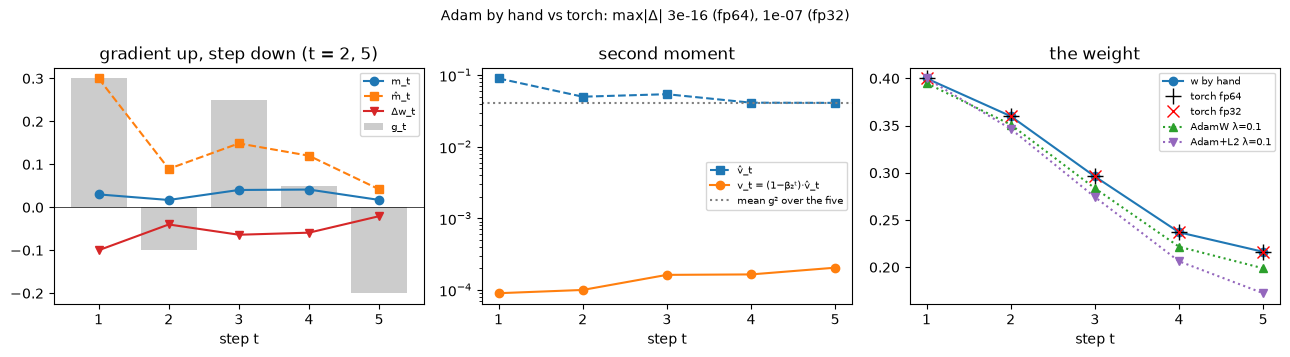

In [10]:
W0 = 0.5
GRADS = [0.30, -0.10, 0.25, 0.05, -0.20]
A_LR, A_B1, A_B2, A_EPS = 0.1, 0.9, 0.999, 1e-8


def adam_by_hand(w0, grads, lr=A_LR, b1=A_B1, b2=A_B2, eps=A_EPS, bias_correction=True,
                 eps_mode="torch", weight_decay=0.0, decay_mode="adamw"):
    """The textbook recursion in plain float64.
    eps_mode: 'torch'  -> m_hat / (sqrt(v_hat) + eps)                     (PyTorch)
              'keras'  -> m_hat / (sqrt(v_hat) + eps / sqrt(1 - b2^t))     (Keras/TF 'epsilon hat')
              'optax'  -> m_hat / sqrt(v_hat + eps)                        (optax eps_root)
    decay_mode: 'adamw' (decoupled: w_{t-1} shrinks BEFORE the Adam step, the moments never
    see it) or 'l2' (lambda*w_{t-1} is added to the gradient before the moments)."""
    rows, m, v, w = [], 0.0, 0.0, w0
    for t, g in enumerate(grads, 1):
        if weight_decay and decay_mode == "l2":
            g = g + weight_decay * w
        if weight_decay and decay_mode == "adamw":
            w = w * (1 - lr * weight_decay)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g * g
        bc1 = 1 - b1 ** t if bias_correction else 1.0
        bc2 = 1 - b2 ** t if bias_correction else 1.0
        mhat, vhat = m / bc1, v / bc2
        if eps_mode == "torch":
            u = mhat / (math.sqrt(vhat) + eps)
        elif eps_mode == "keras":
            u = mhat / (math.sqrt(vhat) + eps / math.sqrt(bc2))
        elif eps_mode == "optax":
            u = mhat / math.sqrt(vhat + eps)
        else:
            raise ValueError(eps_mode)
        step = -lr * u
        w = w + step
        rows.append({"t": t, "g": g, "m": m, "v": v, "mhat": mhat, "vhat": vhat, "u": u, "step": step, "w": w})
    return rows


def adam_by_torch(w0, grads, lr=A_LR, b1=A_B1, b2=A_B2, eps=A_EPS, dtype=torch.float64,
                  cls=torch.optim.Adam, device="cpu", **kw):
    """torch drives a 1-element tensor; the gradient is assigned by hand every step.
    Returns torch's state (m, v) and the REALIZED step (w_{t-1} - w_t)/lr = torch's u_t."""
    w = torch.tensor([w0], dtype=dtype, device=device, requires_grad=True)
    kw.setdefault("foreach", False)
    opt = cls([w], lr=lr, betas=(b1, b2), eps=eps, **kw)
    rows = []
    for t, g in enumerate(grads, 1):
        w_prev = float(w)
        w.grad = torch.tensor([g], dtype=dtype, device=device)
        opt.step()
        st = opt.state[w]
        rows.append({"t": t, "m": float(st["exp_avg"]), "v": float(st["exp_avg_sq"]), "step_count": int(st["step"]),
                     "u": (w_prev - float(w)) / lr, "w": float(w), "state_keys": sorted(st.keys())})
    return rows


hand = adam_by_hand(W0, GRADS)
print(f"w0 = {W0}, lr = {A_LR}, betas = ({A_B1}, {A_B2}), eps = {A_EPS}\n")
print(f"{'t':>2} {'g':>6} {'m':>13} {'v':>13} {'m_hat':>13} {'v_hat':>13} {'u=m_hat/(sqrt v_hat+eps)':>24} {'dw = -lr*u':>13} {'w':>13}")
for r in hand:
    print(f"{r['t']:2d} {r['g']:6.2f} {r['m']:13.10f} {r['v']:13.10f} {r['mhat']:13.10f} {r['vhat']:13.10f} "
          f"{r['u']:24.10f} {r['step']:13.10f} {r['w']:13.10f}")
mean_g2 = sum(g * g for g in GRADS) / len(GRADS)
rms_g = math.sqrt(mean_g2)
print(f"\nread off the table: the gradient says UP at t=2 and t=5 (g<0 with the loss falling in +w) and Adam still steps DOWN "
      f"({hand[1]['step']:+.4f}, {hand[4]['step']:+.4f}) -- momentum outvotes one gradient;")
print(f"  v_hat_5 = {hand[4]['vhat']:.5f} vs the plain mean of g^2 = {mean_g2:.5f} (beta2 = 0.999 makes v_hat the running mean of g^2), "
      f"sqrt(v_hat_5) = {math.sqrt(hand[4]['vhat']):.4f} = RMS(g) = {rms_g:.4f}; m_hat_5 = {hand[4]['mhat']:.4f} is the beta1-weighted RECENT mean of g (the plain mean is {sum(GRADS) / 5:.4f}): "
      f"the late step is lr x (recency-weighted mean of g) / RMS(g), a signal-to-noise step.")

# ---- checks against torch: state (m, v) directly, m_hat/v_hat through the realized step
print("\nchecks against torch.optim.Adam (foreach=False, the single-tensor path), max over the 5 steps:")
print("  torch keeps only", adam_by_torch(W0, GRADS)[0]["state_keys"], "-- no m_hat / v_hat anywhere in the state")


def compare(hand_rows, tor_rows, tor_b1zero_rows, b1=A_B1, b2=A_B2, eps=A_EPS):
    out = {}
    for k in ("m", "v", "u", "w"):
        out[k] = max(abs(h[k] - t_[k]) for h, t_ in zip(hand_rows, tor_rows))
        out[k + "_rel"] = max(abs(h[k] - t_[k]) / abs(h[k]) for h, t_ in zip(hand_rows, tor_rows))
    # v_hat read off torch's OWN behaviour: with beta1 = 0 the realized step is g/(sqrt(v_hat)+eps)
    vhat_t = [(g / r0["u"] - eps) ** 2 for g, r0 in zip(GRADS, tor_b1zero_rows)]
    mhat_t = [r["u"] * (math.sqrt(vh) + eps) for r, vh in zip(tor_rows, vhat_t)]
    out["vhat"] = max(abs(h["vhat"] - x) for h, x in zip(hand_rows, vhat_t))
    out["vhat_rel"] = max(abs(h["vhat"] - x) / h["vhat"] for h, x in zip(hand_rows, vhat_t))
    out["mhat"] = max(abs(h["mhat"] - x) for h, x in zip(hand_rows, mhat_t))
    out["mhat_rel"] = max(abs(h["mhat"] - x) / abs(h["mhat"]) for h, x in zip(hand_rows, mhat_t))
    return out


adam_check = {}
for dtype in (torch.float64, torch.float32):
    tor = adam_by_torch(W0, GRADS, dtype=dtype)
    tor0 = adam_by_torch(W0, GRADS, dtype=dtype, b1=0.0)
    assert all(t_["step_count"] == t_["t"] for t_ in tor)
    c = compare(hand, tor, tor0)
    worst_abs = max(c[k] for k in ("m", "v", "mhat", "vhat", "u", "w"))
    worst_rel = max(c[k + "_rel"] for k in ("m", "v", "mhat", "vhat", "u", "w"))
    name = str(dtype).split(".")[-1]
    adam_check[name] = {**c, "worst_abs": worst_abs, "worst_rel": worst_rel,
                        "decimals_abs": min(16, int(math.floor(-math.log10(worst_abs)))) if worst_abs > 0 else 16,
                        "digits_rel": min(16, int(math.floor(-math.log10(worst_rel)))) if worst_rel > 0 else 16,
                        "torch_rows": [{k: v for k, v in r.items() if k != "state_keys"} for r in tor]}
    print(f"  {name:8s} abs: " + " ".join(f"{k} {c[k]:.1e}" for k in ("m", "v", "mhat", "vhat", "u", "w"))
          + f"\n           rel: " + " ".join(f"{k} {c[k + '_rel']:.1e}" for k in ("m", "v", "mhat", "vhat", "u", "w"))
          + f"   -> every quantity agrees to {adam_check[name]['decimals_abs']} decimal places "
          f"({adam_check[name]['digits_rel']} significant digits)")
assert adam_check["float64"]["worst_abs"] < 1e-14, "float64: hand and torch must agree to rounding"
assert adam_check["float32"]["decimals_abs"] >= 5, "float32: 'several decimal places' means >= 5 here"

# the fused kernel on the accelerator: 1 - beta2 computed in fp32 costs v ~1.3e-5 relative
fused_note = None
if DEVICE != "cpu":
    try:
        torf = adam_by_torch(W0, GRADS, dtype=torch.float32, device=DEVICE, fused=True)
        vrel = max(abs(h["v"] - t_["v"]) / h["v"] for h, t_ in zip(hand, torf))
        wabs = max(abs(h["w"] - t_["w"]) for h, t_ in zip(hand, torf))
        fp32_1mb2 = 1.0 - float(torch.tensor(A_B2, dtype=torch.float32))
        fused_note = {"v_rel": vrel, "w_abs": wabs, "one_minus_b2_fp32_rel_err": abs(fp32_1mb2 - (1 - A_B2)) / (1 - A_B2)}
        print(f"  fused kernel on {DEVICE} (fp32): v rel {vrel:.1e}, w abs {wabs:.1e} -- because 1-beta2 is formed in fp32 there: "
              f"rel err of fp32(1-0.999) = {fused_note['one_minus_b2_fp32_rel_err']:.1e}")
    except Exception as exc:
        print(f"  fused kernel on {DEVICE}: not available ({type(exc).__name__})")

# (a) the first step is +-lr (to eps/|g|); UNCORRECTED it would be (1-b1)/sqrt(1-b2) = 3.162 lr
first = hand[0]
rel_first = abs(abs(first["step"]) - A_LR) / A_LR
unc1 = adam_by_hand(W0, GRADS, bias_correction=False)[0]["step"]
print(f"\n(a) |step 1| = {abs(first['step']):.10f} = lr x (1 - {rel_first:.1e}); eps/|g1| = {A_EPS / abs(GRADS[0]):.1e}. "
      f"Without bias correction step 1 = {abs(unc1) / A_LR:.5f} x lr = (1-b1)/sqrt(1-b2) = {(1 - A_B1) / math.sqrt(1 - A_B2):.5f} (see §2).")
assert abs(rel_first - A_EPS / abs(GRADS[0])) < 1e-12
assert abs(abs(unc1) / A_LR - (1 - A_B1) / math.sqrt(1 - A_B2)) < 1e-5

# (b) the scale ladder: invariance holds until |g| approaches eps, then breaks on the way DOWN
LADDER = [1e3, 1.0, 1e-3, 1e-5, 1e-6, 1e-7, 1e-8]
ladder = []
print("(b) scale ladder: gradients x k -> max|w_k - w_unscaled| over the 5 steps (a trajectory deviation, not a step size), and step-1 |u| = |g1|/(|g1|+eps):")
for k in LADDER:
    rows_k = adam_by_hand(W0, [g * k for g in GRADS])
    dev = max(abs(a["w"] - b["w"]) for a, b in zip(hand, rows_k))
    u1 = abs(rows_k[0]["u"])
    closed = abs(GRADS[0] * k) / (abs(GRADS[0] * k) + A_EPS)
    ladder.append({"k": k, "max_w_dev": dev, "u1": u1, "u1_closed": closed})
    print(f"    x{k:<7.0e} max|w_k - w| {dev:.1e}   |u1| = {u1:.4f} (closed form {closed:.4f})")
assert all(abs(z["u1"] - z["u1_closed"]) < 1e-9 for z in ladder)
assert ladder[-1]["max_w_dev"] > 0.1 and ladder[0]["max_w_dev"] < 1e-7   # broken at 1e-8, intact at x1000

# (c) three places for eps, vs the fp32 noise floor
eps_conv = {}
for mode in ("keras", "optax"):
    rows_m = adam_by_hand(W0, GRADS, eps_mode=mode)
    eps_conv[mode] = {"max_w_dev": max(abs(a["w"] - b["w"]) for a, b in zip(hand, rows_m))}
tiny = [g * 1e-8 for g in GRADS]
for mode in ("torch", "keras", "optax"):
    eps_conv.setdefault(mode, {})["u1_tiny"] = abs(adam_by_hand(W0, tiny, eps_mode=mode)[0]["u"])
print(f"(c) eps conventions on the five numbers, max|w - w_torch|: Keras eps-hat {eps_conv['keras']['max_w_dev']:.1e} "
      f"(visible above the fp32 floor {adam_check['float32']['w']:.1e}), optax eps_root {eps_conv['optax']['max_w_dev']:.1e} (below it); "
      f"at |g| ~ 1e-8 the first |u| is torch {eps_conv['torch']['u1_tiny']:.3f}, Keras {eps_conv['keras']['u1_tiny']:.3f}, optax {eps_conv['optax']['u1_tiny']:.1e}")
assert eps_conv["keras"]["max_w_dev"] > adam_check["float32"]["w"] > eps_conv["optax"]["max_w_dev"]

# (d) AdamW (decoupled, w_{t-1} shrinks before the step) vs Adam + L2 (lambda*w inside the gradient)
LAM = 0.1
hand_w = adam_by_hand(W0, GRADS, weight_decay=LAM, decay_mode="adamw")
hand_l2 = adam_by_hand(W0, GRADS, weight_decay=LAM, decay_mode="l2")
tor_w = adam_by_torch(W0, GRADS, cls=torch.optim.AdamW, weight_decay=LAM)
tor_l2 = adam_by_torch(W0, GRADS, cls=torch.optim.Adam, weight_decay=LAM)
tor_dec = adam_by_torch(W0, GRADS, cls=torch.optim.Adam, weight_decay=LAM, decoupled_weight_decay=True)
d_w = max(abs(h["w"] - t_["w"]) for h, t_ in zip(hand_w, tor_w))
d_l2 = max(abs(h["w"] - t_["w"]) for h, t_ in zip(hand_l2, tor_l2))
d_dec = max(abs(a["w"] - b["w"]) for a, b in zip(tor_w, tor_dec))
delivered_w = hand[-1]["w"] - hand_w[-1]["w"]
delivered_l2 = hand[-1]["w"] - hand_l2[-1]["w"]
print(f"(d) lambda = {LAM}: AdamW by hand vs torch.optim.AdamW max|dw| = {d_w:.1e}; Adam+L2 by hand vs torch.optim.Adam(weight_decay) "
      f"= {d_l2:.1e}; torch.optim.Adam(decoupled_weight_decay=True) vs AdamW = {d_dec:.1e}")
print(f"    decay DELIVERED after 5 steps (w_plain - w_decayed): AdamW {delivered_w:.4f}, Adam+L2 {delivered_l2:.4f} -> L2 delivers "
      f"{delivered_l2 / delivered_w:.2f}x MORE: lambda*w rides through m_hat/(sqrt v_hat + eps) and sqrt(v_hat) ~ {math.sqrt(hand[-1]['vhat']):.2f} < 1 amplifies it")
assert d_w < 1e-14 and d_l2 < 1e-14 and d_dec < 1e-14 and delivered_l2 > delivered_w


# the same contrast on the real model: 20 steps, three arms from one init and one stream
def decay_arm(mode, steps=20, lr=1e-3, lam=LAM):
    m = make_model(CFG["d_work"], seed=11)
    dm = decay_mask(m)
    if mode == "none":
        opt = HandAdamW(m.parameters(), lr, betas=CFG["betas"], weight_decay=0.0, decay=dm)
    elif mode == "adamw":
        opt = HandAdamW(m.parameters(), lr, betas=CFG["betas"], weight_decay=lam, decay=dm)
    else:   # l2 through torch.optim.Adam(weight_decay=lam) on the decayed tensors
        opt = torch.optim.Adam([{"params": [p for p, d in zip(m.parameters(), dm) if d], "weight_decay": lam},
                                {"params": [p for p, d in zip(m.parameters(), dm) if not d], "weight_decay": 0.0}],
                               lr=lr, betas=tuple(CFG["betas"]), eps=CFG["eps"], foreach=False)
    st = CropStream(77)
    w0n = math.sqrt(sum(float(p.detach().pow(2).sum()) for p, d in zip(m.parameters(), dm) if d))
    rec = train_run(m, opt, st, lambda t: lr, steps, clip=0.0)
    w1n = math.sqrt(sum(float(p.detach().pow(2).sum()) for p, d in zip(m.parameters(), dm) if d))
    return {"w_norm_before": w0n, "w_norm_after": w1n, "train_last": rec["train"][-1], "eval": eval_loss(m)}


REAL_DECAY = {mode: decay_arm(mode) for mode in ("none", "adamw", "l2")}
analytic_shrink = REAL_DECAY["none"]["w_norm_after"] * (1 - (1 - 1e-3 * LAM) ** 20)
print(f"    real model ({CFG['d_work']}-wide, 20 steps, lr 1e-3, lambda {LAM}), ||W|| of the decayed tensors: "
      + ", ".join(f"{k}: {v['w_norm_before']:.2f} -> {v['w_norm_after']:.2f} (eval {v['eval']:.3f})" for k, v in REAL_DECAY.items()))
print(f"    AdamW moved ||W|| {REAL_DECAY['none']['w_norm_after'] - REAL_DECAY['adamw']['w_norm_after']:.4f} below no-decay "
      f"(analytic (1-(1-lr*lambda)^20)*||W|| = {analytic_shrink:.4f}); L2 in Adam shrank it "
      f"{(1 - REAL_DECAY['l2']['w_norm_after'] / REAL_DECAY['none']['w_norm_after']) * 100:.0f}% -- the same lambda is a different unit")
strict_assert(REAL_DECAY["l2"]["w_norm_after"] < 0.9 * REAL_DECAY["adamw"]["w_norm_after"], "L2-in-Adam must shrink far more than AdamW at equal lambda")

RESULTS["adam_by_hand"] = {
    "w0": W0, "grads": GRADS, "lr": A_LR, "betas": [A_B1, A_B2], "eps": A_EPS, "rows": hand,
    "mean_g2": mean_g2, "check": adam_check, "fused": fused_note, "first_step_rel_dev": rel_first,
    "uncorrected_step1_over_lr": abs(unc1) / A_LR, "ladder": ladder, "eps_conventions": eps_conv,
    "decay": {"lambda": LAM, "adamw_vs_torch": d_w, "l2_vs_torch": d_l2, "decoupled_flag_vs_adamw": d_dec,
              "delivered_adamw": delivered_w, "delivered_l2": delivered_l2,
              "final_w": {"plain": hand[-1]["w"], "adamw": hand_w[-1]["w"], "l2": hand_l2[-1]["w"]},
              "real_model": REAL_DECAY, "real_model_analytic_adamw_shrink": analytic_shrink},
}
HEADLINE["adam_fp64"] = f"{adam_check['float64']['worst_abs']:.0e}"
HEADLINE["adam_fp32_decimals"] = str(adam_check["float32"]["decimals_abs"])
HEADLINE["l2_over_adamw_delivered"] = f"{delivered_l2 / delivered_w:.2f}x"

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
ts = [r["t"] for r in hand]
ax = axes[0]
ax.bar(ts, GRADS, color="0.8", label="g_t"); ax.plot(ts, [r["m"] for r in hand], "o-", label="m_t")
ax.plot(ts, [r["mhat"] for r in hand], "s--", label="m̂_t"); ax.plot(ts, [r["step"] for r in hand], "v-", color="C3", label="Δw_t")
ax.axhline(0, color="k", lw=0.5); ax.set_title("gradient up, step down (t = 2, 5)"); ax.legend(fontsize=7); ax.set_xlabel("step t")
ax = axes[1]
ax.plot(ts, [r["vhat"] for r in hand], "s--", label="v̂_t"); ax.plot(ts, [r["v"] for r in hand], "o-", label="v_t = (1−β₂ᵗ)·v̂_t")
ax.axhline(mean_g2, color="0.5", ls=":", label="mean g² over the five"); ax.set_yscale("log")
ax.set_title("second moment"); ax.legend(fontsize=7); ax.set_xlabel("step t")
ax = axes[2]
ax.plot(ts, [r["w"] for r in hand], "o-", label="w by hand")
ax.plot(ts, [r["w"] for r in adam_check["float64"]["torch_rows"]], "k+", ms=12, label="torch fp64")
ax.plot(ts, [r["w"] for r in adam_check["float32"]["torch_rows"]], "rx", ms=8, label="torch fp32")
ax.plot(ts, [r["w"] for r in hand_w], "^:", color="C2", label=f"AdamW λ={LAM}")
ax.plot(ts, [r["w"] for r in hand_l2], "v:", color="C4", label=f"Adam+L2 λ={LAM}")
ax.set_title("the weight"); ax.legend(fontsize=7); ax.set_xlabel("step t")
fig.suptitle(f"Adam by hand vs torch: max|Δ| {adam_check['float64']['worst_abs']:.0e} (fp64), {adam_check['float32']['worst_abs']:.0e} (fp32)", fontsize=10)
fig.tight_layout(); fig.savefig(ART / "plots" / "adam_by_hand.png", dpi=130); plt.show()

## §2 — Task 2: bias correction off — the first twenty steps both ways

Without correction, $m$ and $v$ start at zero and are *under-filled*: after $t$ steps they
hold $(1-\beta_1^t)$ and $(1-\beta_2^t)$ of their steady-state weight, so — from the same
state — the uncorrected step is exactly $r(t)$ times the corrected one, per coordinate:

$$r(t) = \frac{m_t/\sqrt{v_t}}{\hat m_t/\sqrt{\hat v_t}} = \frac{1-\beta_1^t}{\sqrt{1-\beta_2^t}},
\qquad r(1) = \frac{1-\beta_1}{\sqrt{1-\beta_2}}$$

Which way it errs depends on $\beta_2$: $r(1) = 1$ exactly at $\beta_2 = 1-(1-\beta_1)^2 = 0.99$.
Above it (the classic 0.999) $v$ fills far more slowly than $m$ and uncorrected Adam runs
**hot** — up to 6.6× at $t \approx 12$, still 2× at $t = 300$, within 10% only after
$t \approx 1{,}750$. Below it (the LLM default 0.95) the uncorrected step starts 2.2×
too **small**, crosses 1 by step 10 and never leaves ±10% after step 6. "Bias correction
matters for the first few steps" is true only for $\beta_2 = 0.95$.

Two measurements, each labelled for what it is. **(a) One trajectory**: the corrected arm
computes, at every step, both the corrected and the uncorrected update from its own $m, v$
— their RMS ratio must equal $r(t)$ to rounding (a check on `HandAdamW`, and the ε effect
made visible). **(b) Two trajectories** from identical init and a checksummed identical
stream, at a **constant** learning rate (no warmup — warmup is the practical mitigation
and is run as its own arm), each arm's *effective step multiplier* (update RMS ÷ η) plotted
separately, because the two arms diverge from step 2 and the ratio of their updates is
not $r(t)$ — the hotter arm's gradients decorrelate, so its normalized update is smaller.
"When does the difference stop mattering" is answered under three stated criteria:
the analytic multiplier, the measured multipliers, and a **paired** held-out-loss gap
(same seed = same init and data, so the pairing cancels init and data variance) over
three seeds with a pre-registered rule. And the honest negative is measured rather than
avoided: at $\beta_2 = 0.999$ and a tuned η the early over-steps inflate the weight norm,
which under pre-LN is a permanently lower effective learning rate that weight decay
cannot undo inside the run — so the gap never closes, and *below* the optimum the same
mechanism helps (the multiplier is a free learning-rate boost).

In [11]:
LR_WORK = 2.0 ** -9    # pre-registered workhorse lr at d_work; §5 checks it against the sweep optimum
B1 = CFG["betas"][0]


def r_uncorrected(t, b1, b2):
    return (1 - b1 ** t) / math.sqrt(1 - b2 ** t)


def stays_within(b1, b2, tol, t_max=20_000):
    """First t such that |r(s)-1| < tol for ALL s >= t (r crosses 1 for beta2 < 0.99, so
    'first touch' would be ambiguous); also the first touch itself."""
    rs = [abs(r_uncorrected(t, b1, b2) - 1) for t in range(1, t_max + 1)]
    last_out = max((i for i, x in enumerate(rs) if x >= tol), default=-1)
    first_touch = next(i for i, x in enumerate(rs) if x < tol) + 1
    return last_out + 2, first_touch


R_TABLE = {}
ts_show = [1, 2, 3, 5, 10, 12, 20, 50, 100, 200, 300, 500, 1000, 2000, 3000, 5000]
print(f"r(t) = (1-b1^t)/sqrt(1-b2^t), b1 = {B1}: the uncorrected/corrected step from the same state\n")
print(f"{'beta2':>6} " + " ".join(f"{t:>6d}" for t in ts_show) + "   peak         stays |r-1|<10%   <1%")
for b2 in (0.999, 0.99, 0.95):
    peak_t = max(range(1, 400), key=lambda t: r_uncorrected(t, B1, b2))
    w10, touch10 = stays_within(B1, b2, 0.10)
    w1, touch1 = stays_within(B1, b2, 0.01)
    R_TABLE[str(b2)] = {"r": {str(t): r_uncorrected(t, B1, b2) for t in ts_show}, "r1": r_uncorrected(1, B1, b2),
                        "peak_t": peak_t, "peak_r": r_uncorrected(peak_t, B1, b2),
                        "within_10pct": w10, "within_1pct": w1, "first_touch_10pct": touch10, "first_touch_1pct": touch1}
    print(f"{b2:>6} " + " ".join(f"{r_uncorrected(t, B1, b2):6.3f}" for t in ts_show)
          + f"   {r_uncorrected(peak_t, B1, b2):.3f}@{peak_t:<4d}   {w10:>8d}   {w1:>6d}")
print(f"\nr(1) = (1-b1)/sqrt(1-b2): {R_TABLE['0.999']['r1']:.3f} (0.999), {R_TABLE['0.99']['r1']:.3f} (0.99), {R_TABLE['0.95']['r1']:.3f} (0.95) "
      f"-- the crossover is beta2 = 1-(1-b1)^2 = {1 - (1 - B1) ** 2:.2f}: above it uncorrected Adam starts too LARGE, below it too SMALL")
assert abs(R_TABLE["0.99"]["r1"] - 1.0) < 1e-12
assert R_TABLE["0.999"]["within_10pct"] == 1751 and R_TABLE["0.999"]["within_1pct"] == 3925
assert R_TABLE["0.95"]["within_10pct"] == 6 and R_TABLE["0.95"]["within_1pct"] == 76 and R_TABLE["0.95"]["peak_t"] == 20
RESULTS["bias_correction"] = {"lr": LR_WORK, "analytic": R_TABLE, "crossover_beta2": 1 - (1 - B1) ** 2}
HEADLINE["r_peak_999"] = f"{R_TABLE['0.999']['peak_r']:.2f}x @ t={R_TABLE['0.999']['peak_t']}"
HEADLINE["r_10pct_999"] = str(R_TABLE["0.999"]["within_10pct"])
HEADLINE["r_10pct_95"] = str(R_TABLE["0.95"]["within_10pct"])
HEADLINE["r1_95"] = f"{R_TABLE['0.95']['r1']:.3f}"


# --- the instrument: HandAdamW(bias_correction=True) vs torch.optim.AdamW on the real model
def hand_vs_torch(device, dtype, steps=20, lr=LR_WORK, d=CFG["d_work"]):
    mA = make_model(d, seed=7, device=device).to(dtype)
    mB = copy.deepcopy(mA)
    dm = decay_mask(mA)
    optA = HandAdamW(mA.parameters(), lr, betas=CFG["betas"], eps=CFG["eps"], weight_decay=CFG["weight_decay"], decay=dm)
    optB = torch.optim.AdamW(
        [{"params": [p for p, dec in zip(mB.parameters(), dm) if dec], "weight_decay": CFG["weight_decay"]},
         {"params": [p for p, dec in zip(mB.parameters(), dm) if not dec], "weight_decay": 0.0}],
        lr=lr, betas=tuple(CFG["betas"]), eps=CFG["eps"], foreach=False)
    sA, sB = CropStream(5), CropStream(5)
    per_step = []
    for _ in range(steps):
        bA, bB = sA.next(device), sB.next(device)
        for m_, opt_, b_ in ((mA, optA, bA), (mB, optB, bB)):
            loss = token_weighted_loss(m_(b_), b_)
            m_.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m_.parameters(), CFG["clip"])
            opt_.step()
        per_step.append(max(float((pa.detach() - pb.detach()).abs().max()) for pa, pb in zip(mA.parameters(), mB.parameters())))
    bitwise = all(torch.equal(pa, pb) for pa, pb in zip(mA.parameters(), mB.parameters()))
    return {"max_abs_diff": max(per_step), "per_step": per_step, "bitwise": bitwise}


HV = {}
for dev_, dt_ in [(CHECK_DEVICE, torch.float64), (CHECK_DEVICE, torch.float32)] + ([(DEVICE, torch.float32)] if DEVICE != "cpu" else []):
    key = f"{dev_}-{str(dt_).split('.')[-1]}"
    HV[key] = hand_vs_torch(dev_, dt_)
    print(f"HandAdamW vs torch.optim.AdamW, 20 steps of the real {CFG['d_work']}-wide model, {key}: "
          f"max|dw| = {HV[key]['max_abs_diff']:.1e}, bitwise identical = {HV[key]['bitwise']}")
assert HV[f"{CHECK_DEVICE}-float64"]["max_abs_diff"] < 1e-12, "in float64 the two implementations must agree to rounding"
assert HV[f"{CHECK_DEVICE}-float32"]["bitwise"], "same op order -> bitwise on the CPU"
RESULTS["bias_correction"]["hand_vs_torch"] = HV
HEADLINE["hand_adamw"] = "bitwise (cpu fp32), " + f"{HV[f'{CHECK_DEVICE}-float64']['max_abs_diff']:.0e} (fp64)"

r(t) = (1-b1^t)/sqrt(1-b2^t), b1 = 0.9: the uncorrected/corrected step from the same state

 beta2      1      2      3      5     10     12     20     50    100    200    300    500   1000   2000   3000   5000   peak         stays |r-1|<10%   <1%
 0.999  3.162  4.250  4.950  5.797  6.528  6.569  6.241  4.504  3.241  2.348  1.964  1.594  1.258  1.075  1.026  1.003   6.569@12         1751     3925
  0.99  1.000  1.347  1.572  1.850  2.106  2.129  2.059  1.583  1.256  1.075  1.025  1.003  1.000  1.000  1.000  1.000   2.131@13          175      391
  0.95  0.447  0.608  0.718  0.861  1.028  1.058  1.097  1.035  1.003  1.000  1.000  1.000  1.000  1.000  1.000  1.000   1.097@20            6       76

r(1) = (1-b1)/sqrt(1-b2): 3.162 (0.999), 1.000 (0.99), 0.447 (0.95) -- the crossover is beta2 = 1-(1-b1)^2 = 0.99: above it uncorrected Adam starts too LARGE, below it too SMALL


HandAdamW vs torch.optim.AdamW, 20 steps of the real 256-wide model, cpu-float64: max|dw| = 0.0e+00, bitwise identical = True


HandAdamW vs torch.optim.AdamW, 20 steps of the real 256-wide model, cpu-float32: max|dw| = 0.0e+00, bitwise identical = True


HandAdamW vs torch.optim.AdamW, 20 steps of the real 256-wide model, mps-float32: max|dw| = 0.0e+00, bitwise identical = True


In [12]:
BC_STEPS = {"0.999": 120 if FAST else 600, "0.95": 60 if FAST else 300}
BC_EVAL_AT = {k: sorted(set(range(1, 21)) | set(range(30, 101, 10)) | set(range(150, n + 1, 50)) | {n})
              for k, n in BC_STEPS.items()}


def run_bc_arm(b2, bias_correction, seed, steps, lr=LR_WORK, warmup=0, eval_at=(), hot_steps=0, hot_mult=1.0):
    """One arm. hot_steps/hot_mult: the counterfactual 'corrected Adam at hot_mult x lr for
    the first hot_steps steps, then back' (the early-magnitude mechanism, isolated)."""
    m = make_model(CFG["d_work"], seed=seed)
    opt = make_opt("adamw", m, lr, betas=(B1, b2), bias_correction=bias_correction)
    opt.track_both = bias_correction
    st = CropStream(seed + 100)
    stream_sha = st.checksum(32)

    def lr_fn(t):
        base = lr_warmup(t, lr, warmup) if warmup else lr
        return base * (hot_mult if t < hot_steps else 1.0)

    params = list(m.parameters())
    n_par = sum(p.numel() for p in params)
    rec = {"train": [], "eval": {}, "upd_rms": [], "lr": [], "wnorm": [], "both": []}
    t_wall = time.time()
    for t in range(steps):
        lr_t = lr_fn(t)
        batch = st.next()
        loss = token_weighted_loss(m(batch), batch)
        m.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, CFG["clip"])
        before = [p.detach().clone() for p in params]
        opt.step(lr_t)
        sq = sum((p.detach() - b).pow(2).sum() for p, b in zip(params, before))
        rec["upd_rms"].append((sq / n_par).sqrt())
        rec["wnorm"].append(torch.stack([p.detach().pow(2).sum() for p in params]).sum().sqrt())
        if opt.track_both:
            rec["both"].append(opt.last_both)
        rec["train"].append(loss.detach())
        rec["lr"].append(lr_t)
        if (t + 1) in eval_at:
            rec["eval"][t + 1] = eval_loss(m)
    sync()
    rec["wall"] = time.time() - t_wall
    rec["train"] = [float(x) for x in rec["train"]]
    rec["upd_rms"] = [float(x) for x in rec["upd_rms"]]
    rec["wnorm"] = [float(x) for x in rec["wnorm"]]
    rec["both"] = [(math.sqrt(float(c)), math.sqrt(float(u))) for c, u in rec["both"]]
    rec["stream_sha"] = stream_sha
    return rec


BC = {}
for b2 in (0.999, 0.95):
    key = str(b2)
    steps, ev = BC_STEPS[key], BC_EVAL_AT[key]
    peak_r = R_TABLE[key]["peak_r"]
    arms = {
        "C": dict(bias_correction=True),
        "U": dict(bias_correction=False),
        "U+warmup": dict(bias_correction=False, warmup=CFG["warmup"]),
        "U@lr/3": dict(bias_correction=False, lr=LR_WORK / 3),
        "C-hot": dict(bias_correction=True, hot_steps=30, hot_mult=peak_r),
    }
    arms["C+warmup"] = dict(bias_correction=True, warmup=CFG["warmup"])
    BC[key] = {"arms": {}, "paired": {}}
    for name, kw in arms.items():
        BC[key]["arms"][name] = run_bc_arm(b2, seed=SEED, steps=steps, eval_at=ev, **kw)
        r_ = BC[key]["arms"][name]
        print(f"[{elapsed()}] beta2={b2} {name:9s} {steps} steps: train[20]={r_['train'][19]:.3f} "
              f"eval@20={r_['eval'][20]:.4f} eval@{steps}={r_['eval'][steps]:.4f} |theta|={r_['wnorm'][-1]:.1f} ({r_['wall']:.0f}s)")
    assert BC[key]["arms"]["C"]["stream_sha"] == BC[key]["arms"]["U"]["stream_sha"]
    # paired seeds for the operational criterion: same seed -> same init and stream, per arm,
    # both WITHOUT warmup (the raw effect) and WITH the 30-step warmup (the practical default)
    PAIR_ARMS = {"C": dict(bias_correction=True), "U": dict(bias_correction=False),
                 "C+warmup": dict(bias_correction=True, warmup=CFG["warmup"]), "U+warmup": dict(bias_correction=False, warmup=CFG["warmup"]),
                 "C-hot": dict(bias_correction=True, hot_steps=30, hot_mult=peak_r)}
    for s_ in CFG["decision_seeds"]:
        if s_ == SEED:
            BC[key]["paired"][str(s_)] = {a: BC[key]["arms"][a]["eval"] for a in PAIR_ARMS}
        else:
            BC[key]["paired"][str(s_)] = {a: run_bc_arm(b2, seed=s_, steps=steps, eval_at=ev, **kw)["eval"] for a, kw in PAIR_ARMS.items()}
    print(f"[{elapsed()}] beta2={b2}: paired seeds done ({len(BC[key]['paired'])} seeds x {len(PAIR_ARMS)} arms)")
CURVES["bias_correction"] = {k: {"arms": {a: {kk: vv for kk, vv in r.items() if kk != "both"} for a, r in v["arms"].items()},
                                 "shared_state": v["arms"]["C"]["both"], "paired": v["paired"]} for k, v in BC.items()}

[    45s] beta2=0.999 C         600 steps: train[20]=2.732 eval@20=2.9773 eval@600=1.6396 |theta|=64.0 (15s)


[    59s] beta2=0.999 U         600 steps: train[20]=3.251 eval@20=3.4041 eval@600=2.2372 |theta|=125.7 (14s)


[    73s] beta2=0.999 U+warmup  600 steps: train[20]=2.836 eval@20=2.9886 eval@600=2.0692 |theta|=103.5 (14s)


[    88s] beta2=0.999 U@lr/3    600 steps: train[20]=2.775 eval@20=3.0369 eval@600=1.7323 |theta|=65.0 (14s)


[   103s] beta2=0.999 C-hot     600 steps: train[20]=3.144 eval@20=3.3022 eval@600=2.2269 |theta|=106.5 (15s)


...

[   335s] beta2=0.95 U+warmup  300 steps: train[20]=2.771 eval@20=2.8435 eval@300=1.5379 |theta|=57.0 (10s)


[   346s] beta2=0.95 U@lr/3    300 steps: train[20]=2.591 eval@20=2.7155 eval@300=1.5363 |theta|=49.1 (10s)


[   356s] beta2=0.95 C-hot     300 steps: train[20]=2.735 eval@20=2.9618 eval@300=1.7880 |theta|=59.5 (10s)


[   366s] beta2=0.95 C+warmup  300 steps: train[20]=2.703 eval@20=2.7726 eval@300=1.5313 |theta|=57.0 (10s)


[   466s] beta2=0.95: paired seeds done (3 seeds x 5 arms)


beta2 = 0.999: 600 steps, constant lr 1.95e-03 (no warmup), 3 paired seeds
  (a) same-state ratio uncorrected/corrected vs r(t): max rel dev 1.2e-02 over 600 steps (step 1: 3.1228 vs 3.1623; step 12: 6.5608 vs 6.5685)
  (b) effective step multiplier (update RMS / lr) at step 1: C 0.989, U 3.088 (ratio 3.123 vs r(1) = 3.162, the gap is eps at near-zero-gradient coordinates); independent-arm ratio U/C at t=10/20/50: 4.70/4.13/2.85 vs r(t) 6.53/6.24/4.50
      train loss at step 20: C 2.7324  U 3.2509  U+warmup 2.8356
  criterion 1 (analytic, stays within 10% / 1%): t = 1751 / 3925
  criterion 2 (measured multipliers within 10% for 20 consecutive steps): t = None
  criterion 3 (|mean paired held-out gap U-C| < 0.02 for every later eval): no warmup t* = None; with the 30-step warmup t* = None
      paired gap U-C, no warmup:   1: +0.232  5: +0.356  10: +0.530  20: +0.406  30: +0.388  50: +0.431  100: +0.583  200: +0.678  300: +0.683  400: +0.652  600: +0.669
      paired gap U-C, with warm

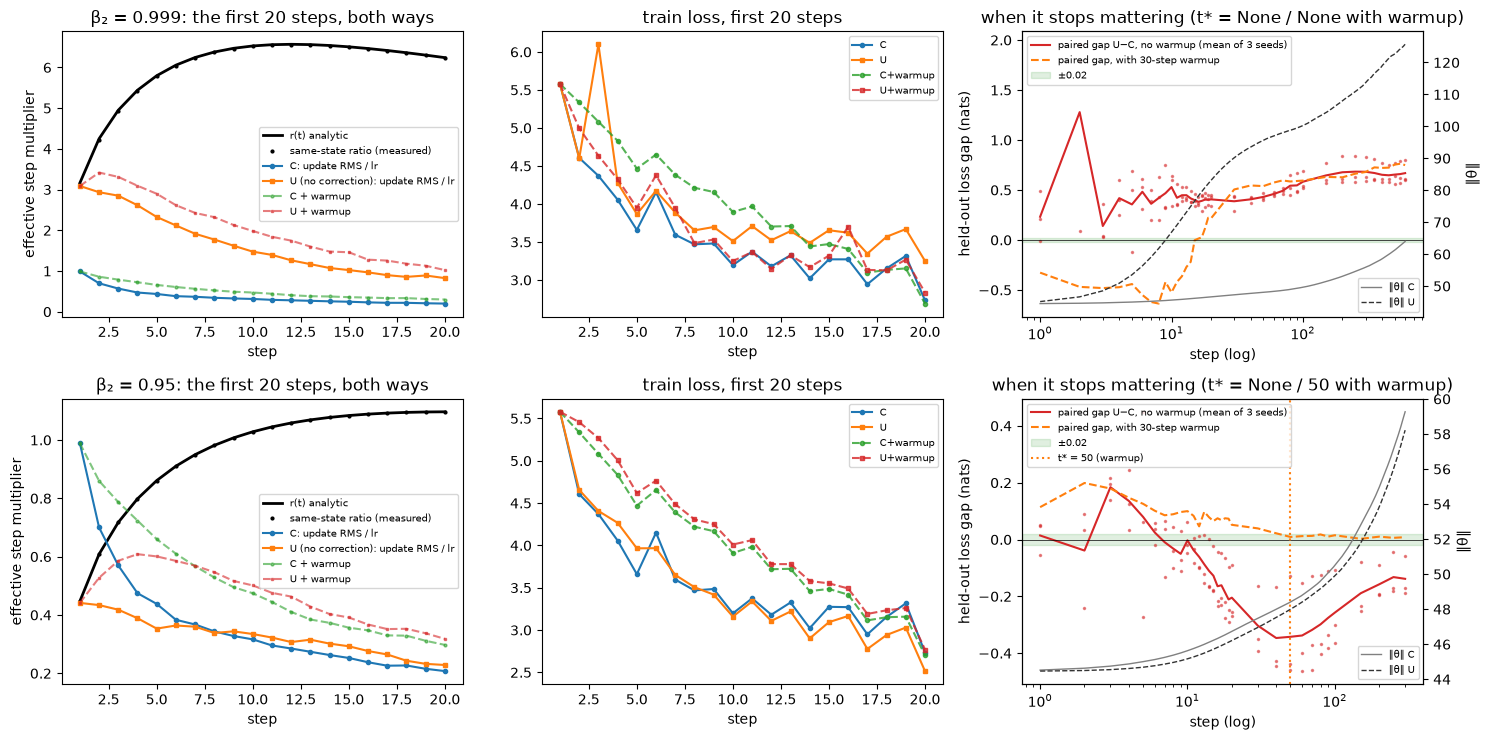

In [13]:
GAP_TOL = 0.02   # nats: the pre-registered 'stops mattering' tolerance on the paired held-out gap


def bc_summary(key):
    A = BC[key]["arms"]
    C, U = A["C"], A["U"]
    b2 = float(key)
    steps = len(C["train"])
    analytic = [r_uncorrected(t, B1, b2) for t in range(1, steps + 1)]
    # (a) one trajectory: both updates from the same state -> ratio == r(t) to rounding
    shared = [u / c for c, u in C["both"]]
    shared_dev = max(abs(s_ / a_ - 1) for s_, a_ in zip(shared, analytic))
    # (b) two trajectories: effective step multipliers, update RMS / lr
    mult = {a: [x / l for x, l in zip(A[a]["upd_rms"], A[a]["lr"])] for a in A}
    ind_ratio = [u / c for u, c in zip(mult["U"], mult["C"])]
    meas10 = next((t + 1 for t in range(steps - 20) if all(abs(ind_ratio[k] - 1) < 0.10 for k in range(t, t + 20))), None)
    # (c) the paired held-out gap over seeds: rule = first eval step after which, for every
    # later eval, |mean paired gap| < GAP_TOL (1% of the loss) -- for the no-warmup pair
    # (U vs C) and the with-warmup pair (U+warmup vs C+warmup). Whether the residual gap's
    # sign is still unanimous across seeds is reported next to it: with pairing, a
    # consistent +0.01 is real but negligible, which is exactly what 'stops mattering' means.
    seeds = list(BC[key]["paired"])
    evs = sorted(C["eval"])

    def paired_rule(arm_u, arm_c):
        gaps = {e: [BC[key]["paired"][s][arm_u][e] - BC[key]["paired"][s][arm_c][e] for s in seeds] for e in evs}
        mean_gap = {e: sum(g) / len(g) for e, g in gaps.items()}
        unanimous = {e: (all(g > 0 for g in gs) or all(g < 0 for g in gs)) if len(gs) > 1 else abs(mean_gap[e]) >= GAP_TOL
                     for e, gs in gaps.items()}
        ok = {e: abs(mean_gap[e]) < GAP_TOL for e in evs}
        t_star = next((e for i, e in enumerate(evs) if all(ok[x] for x in evs[i:])), None)
        unan_after = (all(unanimous[e] for e in evs if e >= t_star) if t_star is not None else None)
        return gaps, mean_gap, t_star, unan_after

    gaps, mean_gap, t_star, unan = paired_rule("U", "C")
    gaps_w, mean_gap_w, t_star_w, unan_w = paired_rule("U+warmup", "C+warmup")
    # the 'hot for 30 steps' counterfactual vs the uncorrected arm, paired over seeds, at the end
    hot_vs_u = [BC[key]["paired"][s]["C-hot"][steps] - BC[key]["paired"][s]["U"][steps] for s in seeds]
    peak_gap_t = max(mean_gap, key=lambda e: mean_gap[e])
    return {"steps": steps, "analytic": analytic, "shared_ratio": shared, "shared_max_rel_dev": shared_dev,
            "mult": mult, "ind_ratio": ind_ratio, "meas_10pct": meas10,
            "analytic_10pct": R_TABLE[key]["within_10pct"], "analytic_1pct": R_TABLE[key]["within_1pct"],
            "gap_mean": mean_gap, "gap_per_seed": gaps, "t_star": t_star, "n_seeds": len(seeds),
            "gap_mean_warmup": mean_gap_w, "gap_per_seed_warmup": gaps_w, "t_star_warmup": t_star_w,
            "sign_unanimous_after_tstar": unan, "sign_unanimous_after_tstar_warmup": unan_w,
            "hot_vs_u_per_seed": hot_vs_u, "hot_vs_u_mean": sum(hot_vs_u) / len(hot_vs_u), "gap_peak_step": peak_gap_t, "gap_peak": mean_gap[peak_gap_t],
            "gap_max_after_tstar_warmup": max(abs(mean_gap_w[e]) for e in evs if t_star_w is not None and e >= t_star_w) if t_star_w is not None else None,
            "eval": {a: A[a]["eval"] for a in A}, "wnorm_end": {a: A[a]["wnorm"][-1] for a in A},
            "train20": {a: A[a]["train"][:20] for a in A},
            "mult_step1": {a: mult[a][0] for a in ("C", "U")}, "peak_mult_U_t": int(max(range(50), key=lambda t: mult["U"][t])) + 1}


BC_SUM = {k: bc_summary(k) for k in BC}
for key, s in BC_SUM.items():
    A = BC[key]["arms"]
    n = s["steps"]
    print(f"beta2 = {key}: {n} steps, constant lr {LR_WORK:.2e} (no warmup), {s['n_seeds']} paired seeds")
    print(f"  (a) same-state ratio uncorrected/corrected vs r(t): max rel dev {s['shared_max_rel_dev']:.1e} over {n} steps "
          f"(step 1: {s['shared_ratio'][0]:.4f} vs {s['analytic'][0]:.4f}; step 12: {s['shared_ratio'][11]:.4f} vs {s['analytic'][11]:.4f})")
    print(f"  (b) effective step multiplier (update RMS / lr) at step 1: C {s['mult_step1']['C']:.3f}, U {s['mult_step1']['U']:.3f} "
          f"(ratio {s['mult_step1']['U'] / s['mult_step1']['C']:.3f} vs r(1) = {s['analytic'][0]:.3f}, the gap is eps at near-zero-gradient coordinates); "
          f"independent-arm ratio U/C at t=10/20/50: {s['ind_ratio'][9]:.2f}/{s['ind_ratio'][19]:.2f}/{s['ind_ratio'][49]:.2f} "
          f"vs r(t) {s['analytic'][9]:.2f}/{s['analytic'][19]:.2f}/{s['analytic'][49]:.2f}")
    print(f"      train loss at step 20: C {s['train20']['C'][-1]:.4f}  U {s['train20']['U'][-1]:.4f}  U+warmup {s['train20']['U+warmup'][-1]:.4f}")
    print(f"  criterion 1 (analytic, stays within 10% / 1%): t = {s['analytic_10pct']} / {s['analytic_1pct']}")
    print(f"  criterion 2 (measured multipliers within 10% for 20 consecutive steps): t = {s['meas_10pct']}")
    print(f"  criterion 3 (|mean paired held-out gap U-C| < {GAP_TOL} for every later eval): no warmup t* = {s['t_star']}"
          f"{' (sign still unanimous after: ' + str(s['sign_unanimous_after_tstar']) + ')' if s['t_star'] else ''}; "
          f"with the {CFG['warmup']}-step warmup t* = {s['t_star_warmup']}"
          f"{' (sign still unanimous after: ' + str(s['sign_unanimous_after_tstar_warmup']) + ')' if s['t_star_warmup'] else ''}")
    evs = sorted(s["gap_mean"])
    show = [e for e in evs if e in (1, 5, 10, 20, 30, 50, 100, 200, 300, 400, 600) or e == n]
    print("      paired gap U-C, no warmup:   " + "  ".join(f"{e}: {s['gap_mean'][e]:+.3f}" for e in show))
    print("      paired gap U-C, with warmup: " + "  ".join(f"{e}: {s['gap_mean_warmup'][e]:+.3f}" for e in show))
    print(f"      held-out at {n}: " + "  ".join(f"{a} {A[a]['eval'][n]:.4f}" for a in A) + f"   |theta| at {n}: "
          + "  ".join(f"{a} {A[a]['wnorm'][-1]:.1f}" for a in A))
    print(f"      C-hot minus U at {n}, paired over {s['n_seeds']} seeds: " + ", ".join(f"{x:+.3f}" for x in s["hot_vs_u_per_seed"])
          + f" (mean {s['hot_vs_u_mean']:+.3f}); the no-warmup gap peaks at step {s['gap_peak_step']} ({s['gap_peak']:+.3f})")
    assert s["shared_max_rel_dev"] < 2e-2, f"same-state ratio must be r(t) (eps aside): {key}"
    # step 1 from identical state: the ratio is r(1) up to eps at near-zero-gradient coordinates (~1%)
    assert abs(s["mult_step1"]["U"] / s["mult_step1"]["C"] / s["analytic"][0] - 1) < 2e-2
strict_assert(BC_SUM["0.95"]["t_star_warmup"] is not None and BC_SUM["0.95"]["t_star_warmup"] <= 100,
              "at beta2 = 0.95 with warmup the loss must stop caring within ~100 steps")
strict_assert(BC_SUM["0.999"]["t_star"] is None or BC_SUM["0.999"]["t_star"] > 200,
              "at beta2 = 0.999 the gap must persist well past the 20-step window")
# without warmup at beta2 = 0.95 the uncorrected arm's r(t) < 1 for the first steps IS a warmup:
# report which way the no-warmup pair leans over the run (a finding, not an assertion)
for key_ in BC_SUM:
    late_ = [BC_SUM[key_]["gap_mean"][e] for e in sorted(BC_SUM[key_]["gap_mean"]) if e >= BC_SUM[key_]["steps"] // 2]
    BC_SUM[key_]["late_gap_no_warmup"] = sum(late_) / len(late_)
    late_w = [BC_SUM[key_]["gap_mean_warmup"][e] for e in sorted(BC_SUM[key_]["gap_mean_warmup"]) if e >= BC_SUM[key_]["steps"] // 2]
    BC_SUM[key_]["late_gap_warmup"] = sum(late_w) / len(late_w)
    print(f"beta2 = {key_}: mean paired gap U-C over the second half of the run: no warmup {BC_SUM[key_]['late_gap_no_warmup']:+.4f}, "
          f"with warmup {BC_SUM[key_]['late_gap_warmup']:+.4f}")
strict_assert(BC["0.999"]["arms"]["U"]["wnorm"][-1] > 1.2 * BC["0.999"]["arms"]["C"]["wnorm"][-1],
              "the uncorrected arm at beta2 = 0.999 must show the weight-norm inflation")
RESULTS["bias_correction"]["summary"] = {k: {kk: vv for kk, vv in v.items() if kk not in ("analytic", "shared_ratio", "mult", "ind_ratio")}
                                         for k, v in BC_SUM.items()}
RESULTS["bias_correction"]["gap_tol"] = GAP_TOL
HEADLINE["bc_tstar_95"] = f"{BC_SUM['0.95']['t_star_warmup']} (warmup) / {BC_SUM['0.95']['t_star']} (no warmup)"
HEADLINE["bc_tstar_999"] = f"{BC_SUM['0.999']['t_star_warmup']} (warmup) / {BC_SUM['0.999']['t_star']} (no warmup)"
HEADLINE["bc_gap_999_end"] = f"{BC_SUM['0.999']['gap_mean'][BC_SUM['0.999']['steps']]:+.3f} (peak {BC_SUM['0.999']['gap_peak']:+.3f} @ {BC_SUM['0.999']['gap_peak_step']})"
HEADLINE["bc_hot_vs_u"] = f"{BC_SUM['0.999']['hot_vs_u_mean']:+.3f}"
HEADLINE["bc_wnorm_999"] = f"{BC['0.999']['arms']['U']['wnorm'][-1]:.1f} vs {BC['0.999']['arms']['C']['wnorm'][-1]:.1f}"

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for row, key in enumerate(("0.999", "0.95")):
    s, A = BC_SUM[key], BC[key]["arms"]
    n = s["steps"]
    ax = axes[row, 0]
    ax.plot(range(1, 21), s["analytic"][:20], "k-", lw=2, label="r(t) analytic")
    ax.plot(range(1, 21), s["shared_ratio"][:20], "k.", ms=4, label="same-state ratio (measured)")
    ax.plot(range(1, 21), s["mult"]["C"][:20], "o-", ms=3, label="C: update RMS / lr")
    ax.plot(range(1, 21), s["mult"]["U"][:20], "s-", ms=3, label="U (no correction): update RMS / lr")
    ax.plot(range(1, 21), s["mult"]["C+warmup"][:20], "o--", ms=2, alpha=0.6, label="C + warmup")
    ax.plot(range(1, 21), s["mult"]["U+warmup"][:20], "s--", ms=2, alpha=0.6, label="U + warmup")
    ax.set_title(f"β₂ = {key}: the first 20 steps, both ways"); ax.set_xlabel("step"); ax.set_ylabel("effective step multiplier")
    ax.legend(fontsize=7)
    ax = axes[row, 1]
    for a, st_ in (("C", "o-"), ("U", "s-"), ("C+warmup", "o--"), ("U+warmup", "s--")):
        ax.plot(range(1, 21), A[a]["train"][:20], st_, ms=3, alpha=0.8 if "warmup" in a else 1.0, label=a)
    ax.set_title("train loss, first 20 steps"); ax.set_xlabel("step"); ax.legend(fontsize=7)
    ax = axes[row, 2]
    evs = sorted(s["gap_mean"])
    for sd, gs in zip(BC[key]["paired"], zip(*[s["gap_per_seed"][e] for e in evs])):
        ax.plot(evs, gs, ".", ms=3, alpha=0.5, color="C3")
    ax.plot(evs, [s["gap_mean"][e] for e in evs], "-", color="C3", label=f"paired gap U−C, no warmup (mean of {s['n_seeds']} seeds)")
    ax.plot(evs, [s["gap_mean_warmup"][e] for e in evs], "--", color="C1", label=f"paired gap, with {CFG['warmup']}-step warmup")
    ax.axhspan(-GAP_TOL, GAP_TOL, color="g", alpha=0.12, label=f"±{GAP_TOL}")
    ax.axhline(0, color="k", lw=0.5)
    if s["t_star"]:
        ax.axvline(s["t_star"], color="C3", ls="--", label=f"t* = {s['t_star']} (no warmup)")
    if s["t_star_warmup"]:
        ax.axvline(s["t_star_warmup"], color="C1", ls=":", label=f"t* = {s['t_star_warmup']} (warmup)")
    ax.set_xscale("log"); ax.set_xlabel("step (log)"); ax.set_ylabel("held-out loss gap (nats)")
    ax2 = ax.twinx()
    ax2.plot(range(1, n + 1), A["C"]["wnorm"], "-", color="0.5", lw=1, label="‖θ‖ C")
    ax2.plot(range(1, n + 1), A["U"]["wnorm"], "--", color="0.2", lw=1, label="‖θ‖ U")
    ax2.set_ylabel("‖θ‖")
    ax.set_title(f"when it stops mattering (t* = {s['t_star']} / {s['t_star_warmup']} with warmup)"); ax.legend(fontsize=7, loc="upper left"); ax2.legend(fontsize=7, loc="lower right")
fig.tight_layout(); fig.savefig(ART / "plots" / "bias_correction.png", dpi=130); plt.show()

## §3 — Task 3: the update-to-weight ratio of every layer, and the step where warmup lets go of it

For every parameter tensor ℓ and every step, $\rho_\ell(t) = \|w_\ell(t) - w_\ell(t-1)\| / \|w_\ell(t-1)\|$ —
the fraction of itself a layer rewrote in one step. Under AdamW the update is
$\Delta w = -\eta\,(\hat m/(\sqrt{\hat v}+\epsilon) + \lambda w)$, so with the (small,
separated) decay term set aside,

$$\rho_\ell(t) = \eta(t)\cdot\frac{\mathrm{RMS}\big(\hat m/(\sqrt{\hat v}+\epsilon)\big)}{\mathrm{RMS}(w_\ell)}
= \eta(t) \cdot \frac{\text{update coherence}_\ell(t)}{\text{weight scale}_\ell(t)}$$

The coherence is exactly 1 at step 1 (every coordinate moves by ±η) and decays as the
gradient noise decorrelates; the scale grows as the weights move. Linear warmup over $W$
steps reaches the peak at step $W$; from step $W+1$ on, $\eta$ is constant and warmup
**cannot** change $\rho$ any more — that is true by construction. The interesting question
is what the *data* show, and the pre-registered protocol has two parts:

1. **Two blind detectors**, each the first argmax of a centered 5-step running median
   (a detector that returns exactly $W$ on a synthetic ramp-then-flat series — a test):
   one on the global ratio $\rho_{\text{global}} = \|\Delta\theta\|/\|\theta\|$, one on the
   *median over tensors* of each tensor's own peak. Both run at $W \in \{50, 100, 200\}$ and
   on three seeds so that their error bands are *measured*, and the detected step must
   move with $W$. (Measured below: the global one fails at $W = 100$ — the global ratio
   has no sharp peak there; the per-tensor one lands within 2–12% of $W$ at $W = 100$ and
   $200$ and misses by +26% at $W = 50$, one arm outside its pre-registered ±25% band,
   reported as a failure.)
2. **Attribution by decomposition**, per layer: the slope of $\log\eta$, of $\log(\text{coherence}/\text{scale})$
   and of $\log\rho$ over the 10 steps before and after $W$. Warmup's contribution to the
   slope of $\log\rho$ ends at $W$ by exactly $S_\eta = 1/W$; whether that kink is *visible*
   in $\rho_\ell$ depends on the sign of the coherence term $S_r$ at that moment: a
   coherence still falling while the ramp rises cancels it, a coherence that starts falling
   faster once $\eta$ stops rising sharpens it. Which regime a layer is in depends on the
   configuration — so the same attribution is run on a counterfactual arm (width 128,
   $\eta = 10^{-3}$, the configuration at which a pre-implementation review measured the
   cancellation) and both are reported.

The per-layer table classifies every tensor by mechanism (tracks W / cancelled / falls
through W / zero-init), and the "≈1e-3 rule of thumb" is shown to be arithmetic —
$\rho(1) = \eta(1)/\sigma_{\text{init}}$ for every dense matrix, asserted — rather than a law.

[   474s] warmup  50 -> constant, seed 1337: final train 1.321 (7s)


[   482s] warmup 100 -> constant, seed 1337: final train 1.324 (7s)


[   490s] warmup 100 -> constant, seed 1338: final train 1.427 (7s)


[   498s] warmup 100 -> constant, seed 1339: final train 1.767 (7s)


[   505s] warmup 200 -> constant, seed 1337: final train 1.350 (7s)


[   513s] warmup 100 -> cosine twin done

identities (W = 100, seed 1337): rho(1) * sigma_init / lr(1) for the dense matrices = 0.9945..1.0050 (1 exactly means every coordinate moved by +-lr); coherence(1) = 0.9957..0.9999 for dense matrices, 0.6632 for tok_emb vs sqrt(rows touched by batch 1 / 259) = sqrt(114/259) = 0.6634; |dw_adam| == lr * |m_hat/(sqrt v_hat + eps)| to 1.7e-05 relative at peak lr (1.0e-03 in the first 5 steps, where lr(t) ~ 2e-5 and fp32 subtraction bites)
LayerNorm gains: rho(1)/lr(1) = 1.0008 (RMS(gain) = 1 so rho(1) = lr(1) exactly); LN biases start at 0 so rho is undefined at step 1 and then 1.82, 0.95, 0.64 at steps 2-4 (a norm-growth regime, no warmup signature)

two blind detectors (first argmax of a 5-step running median, t >= 10): on the GLOBAL ratio |dtheta|/|theta|, and the MEDIAN over tensors of each tensor's own peak:
  W50-s1337    W =  50  global  51 (+2%)   per-tensor median  63 (+26%)   tensor peaks [22, 36, 37, 40, 43, 48, 58, 62, 63, 63, 70, 76, 1


[   517s] counterfactual: width 128, lr 1e-03, W = 50: visible fraction S_rho/S_lr for hidden matrices -0.38..0.41 (mean 0.09) vs 1.48 at the workhorse config; fc1: S_lr +0.0220, S_r -0.0144, coherence at W 0.213; detectors: per-tensor median 55, global 48 (W = 50)
  -> whether the ramp shows in a hidden matrix's rho depends on whether its coherence is still falling when the ramp ends (S_r < 0 cancels it, S_r >= 0 sharpens it): the decomposition transfers, the raw ratio does not

per LAYER (all tensors of the layer pooled), rho = |dw|/|w| at step 1 / W=100 / 300:
  embeddings   @1: 7.73e-04  @100: 1.57e-02  @300: 1.05e-02
  block 0      @1: 6.02e-04  @100: 1.03e-02  @300: 9.72e-03
  block 1      @1: 6.02e-04  @100: 9.79e-03  @300: 1.00e-02
  ln_f         @1: 2.76e-05  @100: 6.46e-04  @300: 4.43e-04
  head         @1: 9.81e-04  @100: 9.60e-03  @300: 6.85e-03

fc1 rho at step 20 / at its own W / at the end, per warmup: W=50: 1.24e-02 / 1.58e-02 / 1.08e-02; W=100: 8.23e-03 / 1.51e-02 / 1

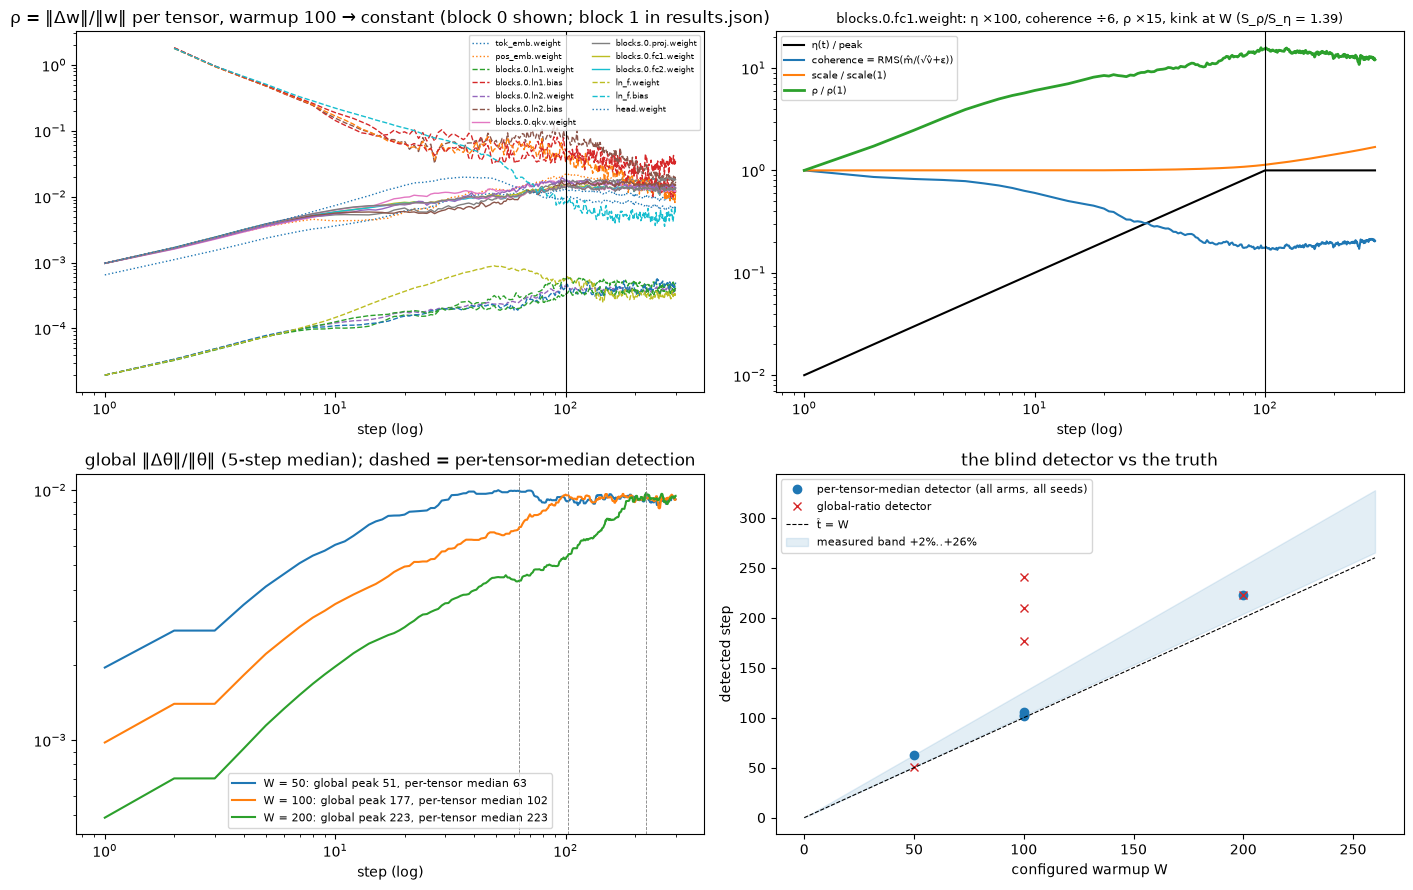

In [14]:
RATIO_WARMUPS = [8, 16, 32] if FAST else [50, 100, 200]
RATIO_STEPS = CFG["steps"]
RATIO_SEEDS = CFG["decision_seeds"]
SIGMA_INIT = 0.02
assert RATIO_STEPS > max(RATIO_WARMUPS) + 20


def run_ratio_arm(W, schedule="constant", seed=SEED, d=CFG["d_work"], lr=LR_WORK):
    m = make_model(d, seed=seed)
    opt = make_opt("adamw", m, lr)
    st = CropStream(seed + 200)
    lr_fn = (lambda t: lr_constant(t, lr, W)) if schedule == "constant" else (lambda t: lr_cosine(t, lr, W, RATIO_STEPS))
    rec = train_run(m, opt, st, lr_fn, RATIO_STEPS, track_layers=True, tag=f"W{W}-{schedule}-s{seed}-d{d}")
    rec["W"], rec["seed"], rec["schedule"], rec["d"], rec["peak"] = W, seed, schedule, d, lr
    for n, L in rec["layers"].items():
        sq = math.sqrt(L["numel"])
        L["rho"] = [d / w if w > 0 else float("nan") for d, w in zip(L["dn"], L["wn"])]
        L["rho_adam"] = [d / w if w > 0 else float("nan") for d, w in zip(L["dn_adam"], L["wn"])]
        L["coherence"] = [u / sq for u in L["u"]]
        L["scale"] = [w / sq for w in L["wn"]]
    rec["global"]["rho"] = [d / w for d, w in zip(rec["global"]["dn"], rec["global"]["wn"])]
    del m, opt
    return rec


def detect_peak_layers(rec, t_min=10):
    """Blind detector 2: the median over tensors of each tensor's own running-median peak
    (tensors whose norm is 0 at init -- the LayerNorm biases -- are excluded: their rho has
    no warmup signature by construction)."""
    peaks = sorted(detect_peak(L["rho"], t_min) for n, L in rec["layers"].items() if L["rho"][0] == L["rho"][0])
    return peaks[len(peaks) // 2], peaks


# validate the detector on a synthetic ramp-then-flat series before touching real data
for W_ in (50, 100, 200):
    syn = [lr_constant(t, 1.0, W_) * 3e-3 for t in range(300)]
    assert detect_peak(syn) == W_, (W_, detect_peak(syn))


RATIO_RUNS = {}
for W in RATIO_WARMUPS:
    for seed in (RATIO_SEEDS if W == RATIO_WARMUPS[1] else [SEED]):
        key = f"W{W}-s{seed}"
        RATIO_RUNS[key] = run_ratio_arm(W, "constant", seed)
        print(f"[{elapsed()}] warmup {W:3d} -> constant, seed {seed}: final train {RATIO_RUNS[key]['train'][-1]:.3f} ({RATIO_RUNS[key]['wall']:.0f}s)")
W_MID = RATIO_WARMUPS[1]
RATIO_RUNS[f"W{W_MID}-cosine"] = run_ratio_arm(W_MID, "cosine", SEED)
print(f"[{elapsed()}] warmup {W_MID:3d} -> cosine twin done")

# ---- identities the audit and tests rely on
ref = RATIO_RUNS[f"W{W_MID}-s{SEED}"]
lr1 = ref["lr"][0]
dense = [n for n in ref["layers"] if n.endswith(".weight") and "ln" not in n and n != "tok_emb.weight"]
id_rho1 = {n: ref["layers"][n]["rho"][0] * SIGMA_INIT / lr1 for n in dense}
id_coh1 = {n: ref["layers"][n]["coherence"][0] for n in ref["layers"]}
id_adam = max(abs(L["dn_adam"][t] / (ref["lr"][t] * L["u"][t]) - 1) for L in ref["layers"].values() for t in range(W_MID, RATIO_STEPS)
              if L["u"][t] > 0)            # at peak lr; during warmup lr(1) = peak/W makes dw 1e-5 of w and fp32 leaves ~3 digits
id_adam_early = max(abs(L["dn_adam"][t] / (ref["lr"][t] * L["u"][t]) - 1) for L in ref["layers"].values() for t in range(0, 5)
                    if L["u"][t] > 0)
n_rows_batch1 = len(set(CropStream(SEED + 200).next("cpu").flatten().tolist()))
coh_tok_expected = math.sqrt(n_rows_batch1 / VOCAB)
print(f"\nidentities (W = {W_MID}, seed {SEED}): rho(1) * sigma_init / lr(1) for the dense matrices = "
      f"{min(id_rho1.values()):.4f}..{max(id_rho1.values()):.4f} (1 exactly means every coordinate moved by +-lr); "
      f"coherence(1) = {min(id_coh1[n] for n in dense):.4f}..{max(id_coh1[n] for n in dense):.4f} for dense matrices, "
      f"{id_coh1['tok_emb.weight']:.4f} for tok_emb vs sqrt(rows touched by batch 1 / 259) = sqrt({n_rows_batch1}/259) = {coh_tok_expected:.4f}; "
      f"|dw_adam| == lr * |m_hat/(sqrt v_hat + eps)| to {id_adam:.1e} relative at peak lr ({id_adam_early:.1e} in the first 5 steps, where lr(t) ~ 2e-5 and fp32 subtraction bites)")
assert all(abs(v - 1) < 2e-2 for v in id_rho1.values()), id_rho1
assert abs(id_coh1["tok_emb.weight"] - coh_tok_expected) < 1e-2
assert all(abs(id_coh1[n] - 1) < 1e-2 for n in dense) and id_adam < 2e-3   # eps at tiny-gradient coordinates
lr_ln = ref["layers"]["blocks.0.ln1.weight"]["rho"][0] / lr1
print(f"LayerNorm gains: rho(1)/lr(1) = {lr_ln:.4f} (RMS(gain) = 1 so rho(1) = lr(1) exactly); LN biases start at 0 so rho is undefined "
      f"at step 1 and then {ref['layers']['blocks.0.ln1.bias']['rho'][1]:.2f}, {ref['layers']['blocks.0.ln1.bias']['rho'][2]:.2f}, "
      f"{ref['layers']['blocks.0.ln1.bias']['rho'][3]:.2f} at steps 2-4 (a norm-growth regime, no warmup signature)")

# ---- the blind detector across W and seeds: measured band
DET = {}
for key, rec in RATIO_RUNS.items():
    if rec["schedule"] != "constant":
        continue
    t_hat = detect_peak(rec["global"]["rho"])
    t_lay, peaks = detect_peak_layers(rec)
    DET[key] = {"W": rec["W"], "seed": rec["seed"], "t_hat_global": t_hat, "rel_err_global": (t_hat - rec["W"]) / rec["W"],
                "t_hat_layers": t_lay, "rel_err_layers": (t_lay - rec["W"]) / rec["W"], "layer_peaks": peaks}
print("\ntwo blind detectors (first argmax of a 5-step running median, t >= 10): on the GLOBAL ratio |dtheta|/|theta|, "
      "and the MEDIAN over tensors of each tensor's own peak:")
for key, d in DET.items():
    print(f"  {key:12s} W = {d['W']:3d}  global {d['t_hat_global']:3d} ({d['rel_err_global'] * 100:+.0f}%)   per-tensor median {d['t_hat_layers']:3d} "
          f"({d['rel_err_layers'] * 100:+.0f}%)   tensor peaks {d['layer_peaks']}")
band_g = (min(d["rel_err_global"] for d in DET.values()), max(d["rel_err_global"] for d in DET.values()))
band_l = (min(d["rel_err_layers"] for d in DET.values()), max(d["rel_err_layers"] for d in DET.values()))
band = band_l
print(f"  error band over {len(DET)} arms: global {band_g[0] * 100:+.0f}%..{band_g[1] * 100:+.0f}%, per-tensor median {band_l[0] * 100:+.0f}%..{band_l[1] * 100:+.0f}%; "
      f"the cosine twin: global {detect_peak(RATIO_RUNS[f'W{W_MID}-cosine']['global']['rho'])}, per-tensor {detect_peak_layers(RATIO_RUNS[f'W{W_MID}-cosine'])[0]} "
      f"(identical to the constant twin through W: cosine's slope at W is 0)")
soft_check(all(abs(d["rel_err_layers"]) <= 0.25 for d in DET.values()), "the per-tensor-median detector should track W within 25% in every arm")
soft_check(DET[f"W{RATIO_WARMUPS[0]}-s{SEED}"]["t_hat_layers"] < DET[f"W{RATIO_WARMUPS[1]}-s{SEED}"]["t_hat_layers"] < DET[f"W{RATIO_WARMUPS[2]}-s{SEED}"]["t_hat_layers"],
           "the per-tensor-median detected step should move with W")

# ---- attribution per layer at W: slope changes of log lr, log(coherence/scale), log rho
H_WIN = 5 if FAST else 10


def attribute(rec, W, h=H_WIN):
    out = {}
    for n, L in rec["layers"].items():
        r_series = [c / s if s > 0 else float("nan") for c, s in zip(L["coherence"], L["scale"])]
        S_lr = slope_change(rec["lr"], W, h)
        S_r = slope_change(r_series, W, h)
        S_rho = slope_change(L["rho"], W, h)
        zero_init = "ln" in n and n.endswith("bias")
        peak = None if zero_init else detect_peak(L["rho"])      # a monotone series has no peak the detector can see
        if zero_init:
            cls = "zero-init (norm growth)"
        elif S_rho / S_lr > 0.5:
            cls = "tracks W"
        elif S_rho / S_lr > -0.5:
            cls = "cancelled by coherence"
        else:
            cls = "falls through W"
        out[n] = {"S_lr": S_lr, "S_r": S_r, "S_rho": S_rho, "visible": S_rho / S_lr, "peak": peak, "class": cls,
                  "rho_W": L["rho"][W - 1], "rho_1": L["rho"][0], "rho_end": L["rho"][-1],
                  "coherence_W": L["coherence"][W - 1], "scale_W": L["scale"][W - 1], "scale_1": L["scale"][0],
                  "scale_end": L["scale"][-1], "wd_share": 1 - L["dn_adam"][W - 1] / L["dn"][W - 1],
                  "decay_over_dw": rec["lr"][W - 1] * CFG["weight_decay"] * L["wn"][W - 1] / L["dn"][W - 1]
                  if n.endswith(".weight") and "ln" not in n else 0.0}
    return out


ATTR = attribute(ref, W_MID)
print(f"\nper layer at W = {W_MID} (slopes of log series over {H_WIN} steps before minus after W; S_lr ~ 1/W: the {H_WIN}-step "
      f"OLS window gives {ATTR['head.weight']['S_lr']:.4f} = 1/{1 / ATTR['head.weight']['S_lr']:.1f} vs 1/W = {1 / W_MID:.4f}):")
print(f"{'tensor':22s} {'rho@1':>8s} {'rho@W':>8s} {'rho@end':>8s} {'coh@W':>6s} {'scale@W':>8s} {'S_lr':>7s} {'S_r':>7s} {'S_rho':>7s} {'visible':>7s} {'peak':>5s}  class")
for n, a in ATTR.items():
    print(f"{n:22s} {a['rho_1']:8.1e} {a['rho_W']:8.1e} {a['rho_end']:8.1e} {a['coherence_W']:6.3f} {a['scale_W']:8.4f} "
          f"{a['S_lr']:7.4f} {a['S_r']:7.4f} {a['S_rho']:7.4f} {a['visible']:7.2f} {(str(a['peak']) if a['peak'] is not None else '-'):>5s}  {a['class']}")
hidden = [n for n in ATTR if n.startswith("blocks") and n.endswith(".weight") and "ln" not in n]
vis_hidden = [ATTR[n]["visible"] for n in hidden]
vis_track = [ATTR[n]["visible"] for n in ("tok_emb.weight", "pos_emb.weight", "ln_f.weight")]
print(f"\nvisible fraction of the warmup kink, S_rho/S_lr: hidden matrices {min(vis_hidden):.2f}..{max(vis_hidden):.2f} "
      f"(mean {sum(vis_hidden) / len(vis_hidden):.2f}); tok_emb/pos_emb/ln_f {', '.join(f'{v:.2f}' for v in vis_track)}; "
      f"head {ATTR['head.weight']['visible']:.2f} (its scale grows {ATTR['head.weight']['scale_end'] / ATTR['head.weight']['scale_1']:.1f}x over the run)")
print(f"rho at W for the hidden matrices: {min(ATTR[n]['rho_W'] for n in hidden):.1e}..{max(ATTR[n]['rho_W'] for n in hidden):.1e} "
      f"= lr x coherence / scale with lr {LR_WORK:.1e}, sigma_init {SIGMA_INIT}: the '1e-3 rule' assumes lr ~ 3e-4 and RMS(w) ~ 0.02-0.05, "
      f"not this lr; the decoupled-decay term lr*lambda*|w| is {max(a['decay_over_dw'] for a in ATTR.values()) * 100:.1f}% of |dw| at most (head), "
      f"and shifts |dw| by at most {max(abs(a['wd_share']) for a in ATTR.values()) * 100:.2f}%")
# the same attribution on the other two W = 100 seeds: is 'visible in every block matrix' a property or one draw?
ATTR_SEEDS = {str(sd): attribute(RATIO_RUNS[f"W{W_MID}-s{sd}"], W_MID) for sd in RATIO_SEEDS}
vis_by_seed = {sd: [ATTR_SEEDS[sd][n]["visible"] for n in hidden] for sd in ATTR_SEEDS}
n_all_seeds_visible = sum(1 for n in hidden if all(ATTR_SEEDS[sd][n]["visible"] > 0.5 for sd in ATTR_SEEDS))
print(f"the block matrices across the {len(RATIO_SEEDS)} W = {W_MID} seeds: visible fraction mean per seed "
      + ", ".join(f"{sum(v) / len(v):.2f}" for v in vis_by_seed.values()) + f"; per-tensor minimum over seeds "
      f"{min(min(ATTR_SEEDS[sd][n]['visible'] for sd in ATTR_SEEDS) for n in hidden):.2f}; {n_all_seeds_visible} of {len(hidden)} block matrices exceed 0.5 in every seed"
      + "".join(f"; {n}: " + "/".join(f"{ATTR_SEEDS[sd][n]['visible']:.2f}" for sd in ATTR_SEEDS) for n in hidden if not all(ATTR_SEEDS[sd][n]["visible"] > 0.5 for sd in ATTR_SEEDS)))
soft_check(sum(vis_track) / len(vis_track) > 0.5, "for the embeddings and ln_f the warmup kink should be visible")

# the counterfactual configuration: does the kink's visibility depend on width and lr? (the design
# review measured coherence CANCELLING the ramp for hidden matrices at width 128, lr 1e-3, W 50)
CF = {"d": 128, "lr": 1e-3, "W": 50}
cf_rec = run_ratio_arm(CF["W"], "constant", SEED, d=CF["d"], lr=CF["lr"])
CF_ATTR = attribute(cf_rec, CF["W"])
cf_hidden = [n for n in CF_ATTR if n.startswith("blocks") and n.endswith(".weight") and "ln" not in n]
CF["visible_hidden"] = [CF_ATTR[n]["visible"] for n in cf_hidden]
CF["visible_hidden_mean"] = sum(CF["visible_hidden"]) / len(CF["visible_hidden"])
CF["visible_emb_ln"] = [CF_ATTR[n]["visible"] for n in ("tok_emb.weight", "pos_emb.weight", "ln_f.weight")]
CF["coherence_W_fc1"] = CF_ATTR["blocks.0.fc1.weight"]["coherence_W"]
CF["S_r_fc1"], CF["S_lr_fc1"] = CF_ATTR["blocks.0.fc1.weight"]["S_r"], CF_ATTR["blocks.0.fc1.weight"]["S_lr"]
CF["detector_layers"], _ = detect_peak_layers(cf_rec)
CF["detector_global"] = detect_peak(cf_rec["global"]["rho"])
print(f"\n[{elapsed()}] counterfactual: width {CF['d']}, lr {CF['lr']:.0e}, W = {CF['W']}: visible fraction S_rho/S_lr for hidden matrices "
      f"{min(CF['visible_hidden']):.2f}..{max(CF['visible_hidden']):.2f} (mean {CF['visible_hidden_mean']:.2f}) vs {sum(vis_hidden) / len(vis_hidden):.2f} at the workhorse config; "
      f"fc1: S_lr {CF['S_lr_fc1']:+.4f}, S_r {CF['S_r_fc1']:+.4f}, coherence at W {CF['coherence_W_fc1']:.3f}; detectors: per-tensor median {CF['detector_layers']}, global {CF['detector_global']} (W = {CF['W']})")
print("  -> whether the ramp shows in a hidden matrix's rho depends on whether its coherence is still falling when the ramp ends "
      "(S_r < 0 cancels it, S_r >= 0 sharpens it): the decomposition transfers, the raw ratio does not")

# ---- the requirement says 'every layer': aggregate the tensors into layers (block 0, block 1, embeddings, ln_f, head)
def layer_of(name):
    return name.split(".")[1] and f"block {name.split('.')[1]}" if name.startswith("blocks") else ("embeddings" if "emb" in name else name.split(".")[0])


LAYER_TABLE = {}
for n, L in ref["layers"].items():
    lay = layer_of(n)
    for t in (0, W_MID - 1, RATIO_STEPS - 1):
        LAYER_TABLE.setdefault(lay, {}).setdefault(str(t + 1), {"dn2": 0.0, "wn2": 0.0})
        LAYER_TABLE[lay][str(t + 1)]["dn2"] += L["dn"][t] ** 2
        LAYER_TABLE[lay][str(t + 1)]["wn2"] += L["wn"][t] ** 2
for lay, d_ in LAYER_TABLE.items():
    for t, v in d_.items():
        v["rho"] = math.sqrt(v["dn2"]) / math.sqrt(v["wn2"])
print(f"\nper LAYER (all tensors of the layer pooled), rho = |dw|/|w| at step 1 / W={W_MID} / {RATIO_STEPS}:")
for lay, d_ in LAYER_TABLE.items():
    print(f"  {lay:12s} " + "  ".join(f"@{t}: {v['rho']:.2e}" for t, v in d_.items()))

# ---- the merge: rho of one hidden matrix for the three warmups
MERGE = {}
for W in RATIO_WARMUPS:
    L = RATIO_RUNS[f"W{W}-s{SEED}"]["layers"]["blocks.0.fc1.weight"]
    MERGE[str(W)] = {"rho_20": L["rho"][19], "rho_W": L["rho"][W - 1], "rho_end": L["rho"][-1]}
print("\nfc1 rho at step 20 / at its own W / at the end, per warmup: "
      + "; ".join(f"W={W}: {v['rho_20']:.2e} / {v['rho_W']:.2e} / {v['rho_end']:.2e}" for W, v in MERGE.items())
      + " -- by the end rho has forgotten W")

RESULTS["update_ratio"] = {"warmups": RATIO_WARMUPS, "steps": RATIO_STEPS, "lr": LR_WORK, "sigma_init": SIGMA_INIT,
                           "W_mid": W_MID, "h_win": H_WIN, "detector": DET, "band_layers": band_l, "band_global": band_g, "attribution": ATTR,
                           "attribution_seeds": ATTR_SEEDS, "visible_hidden_by_seed": {sd: sum(v) / len(v) for sd, v in vis_by_seed.items()},
                           "n_hidden_visible_all_seeds": n_all_seeds_visible, "n_hidden": len(hidden),
                           "tok_rows_batch1": n_rows_batch1, "coh_tok_expected": coh_tok_expected,
                           "counterfactual": {**CF, "attribution": CF_ATTR},
                           "identities": {"rho1_sigma_over_lr1": id_rho1, "coherence1": id_coh1, "dn_adam_vs_lr_u_max_rel": id_adam, "dn_adam_vs_lr_u_early": id_adam_early,
                                          "ln_gain_rho1_over_lr1": lr_ln, "tok_rows_touched_step1_sq": id_coh1["tok_emb.weight"] ** 2 * VOCAB},
                           "merge_fc1": MERGE, "per_layer": {lay: {t: v["rho"] for t, v in d_.items()} for lay, d_ in LAYER_TABLE.items()},
                           "walls": {k: v["wall"] for k, v in RATIO_RUNS.items()}}
RATIO_RUNS["counterfactual"] = cf_rec
CURVES["update_ratio"] = {k: {"W": v["W"], "seed": v["seed"], "schedule": v["schedule"], "d": v["d"], "peak": v["peak"], "lr": v["lr"], "train": v["train"],
                              "global_rho": v["global"]["rho"],
                              "layers": {n: {kk: L[kk] for kk in ("rho", "rho_adam", "coherence", "scale", "dn", "dn_adam", "wn", "u", "numel")}
                                         for n, L in v["layers"].items()}}
                          for k, v in RATIO_RUNS.items()}
HEADLINE["ratio_band"] = f"per-tensor {band_l[0] * 100:+.0f}%..{band_l[1] * 100:+.0f}%; global {band_g[0] * 100:+.0f}%..{band_g[1] * 100:+.0f}%"
HEADLINE["ratio_cf_visible"] = f"{CF['visible_hidden_mean']:.2f} (w128, lr 1e-3)"
HEADLINE["ratio_visible_hidden"] = f"{sum(vis_hidden) / len(vis_hidden):.2f}"
HEADLINE["ratio_visible_emb"] = f"{sum(vis_track) / len(vis_track):.2f}"

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax = axes[0, 0]
tt = range(1, RATIO_STEPS + 1)
for n, L in ref["layers"].items():
    style = "-" if n in hidden else ("--" if "ln" in n else ":")
    lab = n if (n.startswith("blocks.0") or not n.startswith("blocks")) else None
    ax.plot(tt, L["rho"], style, lw=1, label=lab)
ax.axvline(W_MID, color="k", lw=0.8); ax.set_yscale("log"); ax.set_xscale("log")
ax.set_title(f"ρ = ‖Δw‖/‖w‖ per tensor, warmup {W_MID} → constant (block 0 shown; block 1 in results.json)"); ax.set_xlabel("step (log)"); ax.legend(fontsize=6, ncol=2)
ax = axes[0, 1]
nm = "blocks.0.fc1.weight"
L = ref["layers"][nm]
ax.plot(tt, [x / LR_WORK for x in ref["lr"]], "k-", label="η(t) / peak")
ax.plot(tt, L["coherence"], "-", label="coherence = RMS(m̂/(√v̂+ε))")
ax.plot(tt, [s / L["scale"][0] for s in L["scale"]], "-", label="scale / scale(1)")
ax.plot(tt, [x / L["rho"][0] for x in L["rho"]], "-", lw=2, label="ρ / ρ(1)")
ax.axvline(W_MID, color="k", lw=0.8); ax.set_yscale("log"); ax.set_xscale("log")
ax.set_title(f"{nm}: η ×{W_MID}, coherence ÷{1 / ATTR[nm]['coherence_W']:.0f}, ρ ×{ATTR[nm]['rho_W'] / ATTR[nm]['rho_1']:.0f}, kink at W (S_ρ/S_η = {ATTR[nm]['visible']:.2f})", fontsize=9)
ax.set_xlabel("step (log)"); ax.legend(fontsize=7)
ax = axes[1, 0]
for W in RATIO_WARMUPS:
    rec = RATIO_RUNS[f"W{W}-s{SEED}"]
    ax.plot(tt, running_median(rec["global"]["rho"]), label=f"W = {W}: global peak {DET[f'W{W}-s{SEED}']['t_hat_global']}, per-tensor median {DET[f'W{W}-s{SEED}']['t_hat_layers']}")
    ax.axvline(DET[f"W{W}-s{SEED}"]["t_hat_layers"], color="0.5", lw=0.6, ls="--")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title("global ‖Δθ‖/‖θ‖ (5-step median); dashed = per-tensor-median detection")
ax.set_xlabel("step (log)"); ax.legend(fontsize=8)
ax = axes[1, 1]
xs = [d["W"] for d in DET.values()]
ax.plot(xs, [d["t_hat_layers"] for d in DET.values()], "o", label="per-tensor-median detector (all arms, all seeds)")
ax.plot(xs, [d["t_hat_global"] for d in DET.values()], "x", color="C3", label="global-ratio detector")
lim = [0, max(RATIO_WARMUPS) * 1.3]
ax.plot(lim, lim, "k--", lw=0.8, label="t̂ = W")
ax.fill_between(lim, [l * (1 + band[0]) for l in lim], [l * (1 + band[1]) for l in lim], color="C0", alpha=0.12, label=f"measured band {band[0] * 100:+.0f}%..{band[1] * 100:+.0f}%")
ax.set_xlabel("configured warmup W"); ax.set_ylabel("detected step"); ax.set_title("the blind detector vs the truth"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(ART / "plots" / "update_ratio.png", dpi=130); plt.show()

## §4 — Task 4: cosine vs WSD for 300 steps, both stopped at 200

Same init, same checksummed data stream, same peak learning rate and warmup; the only
difference is what η does after warmup. **Cosine** decays from the peak to 10% of it at
step 300. **WSD** (warmup–stable–decay; Hägele et al. 2024's baseline form) holds the peak
until step 240, then decays linearly to zero over the last 20% of the horizon. Both are
stopped at step 200 and every held-out byte is scored — the two numbers the task asks for
— on three seeds, reported as **paired** per-seed differences (same seed = same init and
data, so the pairing cancels what both arms share) with their sign agreement.

At step 200 cosine has already spent two thirds of its decay (η = 0.372 × peak) while WSD
is still at the peak. Whether that makes cosine read *lower* is not a property of the
schedules: it depends on the regime. When the run is limited by gradient noise (peak η at
or above the horizon's optimum), annealing wins and cosine leads; when it is limited by
progress (η below the optimum, or a short horizon), the arm with more learning-rate
*area* wins, and WSD has 28% more of it by step 200. So the comparison is run at the
tuned η *and* at η/4 and 4η, and the sign of the step-200 gap is plotted against η rather
than asserted.

Then what each checkpoint is *worth* is measured, from the same step-200 states and on
identical continuation data: a fresh cooldown of 30 and of 60 steps, linear and (1−√)
shaped (the shape Hägele et al. recommend), against cosine continued on its own schedule
and cosine given the same fresh cooldowns; the full horizon; and — because "keep the WSD
checkpoint, it is a live trunk" is the claim that actually matters — an **extension to
400 steps** from both checkpoints (WSD: peak to 340 then decay; cosine: re-warm 30 steps
to the peak, then the same decay), against a run planned for 400 from scratch. The
decision sentence is written from those numbers.

In [15]:
SCHED_STEPS = CFG["steps"]                 # the horizon both schedules are built for
SCHED_STOP = 40 if FAST else 200           # both runs are stopped here
COOL = [6, 12] if FAST else [30, 60]       # fresh cooldown lengths from the stop checkpoint
EXT_STEPS = 80 if FAST else 400            # the extension horizon
WSD_DECAY_FRAC = 0.2
SCHED_EVAL_EVERY = 10 if FAST else 20
SCHED_LR_LADDER = [LR_WORK / 4, LR_WORK / 2, LR_WORK, LR_WORK * 2, LR_WORK * 4]

SCHEDULES = {
    "cosine": lambda t, peak=LR_WORK, total=SCHED_STEPS: lr_cosine(t, peak, CFG["warmup"], total, floor_frac=0.1),
    "wsd": lambda t, peak=LR_WORK, total=SCHED_STEPS: lr_wsd(t, peak, CFG["warmup"], total, decay_frac=WSD_DECAY_FRAC),
}
LR_TRACES = {k: [f(t) for t in range(SCHED_STEPS)] for k, f in SCHEDULES.items()}
print(f"lr at step {SCHED_STOP}: cosine {LR_TRACES['cosine'][SCHED_STOP]:.2e} = {LR_TRACES['cosine'][SCHED_STOP] / LR_WORK:.3f} x peak, "
      f"wsd {LR_TRACES['wsd'][SCHED_STOP] / LR_WORK:.3f} x peak; wsd decay begins at step {int(round(SCHED_STEPS * (1 - WSD_DECAY_FRAC)))}; "
      f"lr-area to step {SCHED_STOP} (peak units): cosine {sum(LR_TRACES['cosine'][:SCHED_STOP]) / LR_WORK:.1f}, wsd {sum(LR_TRACES['wsd'][:SCHED_STOP]) / LR_WORK:.1f}")
assert abs(LR_TRACES["cosine"][SCHED_STOP] / LR_WORK - (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * (SCHED_STOP - CFG["warmup"]) / (SCHED_STEPS - CFG["warmup"]))))) < 1e-12
assert LR_TRACES["wsd"][SCHED_STOP] == LR_WORK and LR_TRACES["wsd"][SCHED_STEPS - 1] > 0 and lr_wsd(SCHED_STEPS, LR_WORK, CFG["warmup"], SCHED_STEPS) == 0.0


def lr_one_minus_sqrt(t, start_lr, t0, n):
    """Hagele et al. 2024's (1 - sqrt) cooldown: start_lr * (1 - sqrt((t - t0)/n))."""
    return start_lr * max(0.0, 1 - math.sqrt(min(1.0, (t - t0) / n)))


def branch(ck, g_state, seed, lr_fn, steps, start, eval_at, tag):
    """Continue a frozen checkpoint on the SAME continuation data."""
    m, opt = checkpoint(*ck)
    st = CropStream(seed + 300)
    st.g.set_state(g_state)
    rec = train_run(m, opt, st, lr_fn, steps, start=start, eval_at=eval_at, tag=tag)
    out = {"eval": rec["eval"], "train": rec["train"], "wall": rec["wall"]}
    del m, opt
    return out


def run_schedule(kind, seed, peak=LR_WORK, full=True):
    """The main run to the stop step, then every branch from that checkpoint."""
    lr_fn = lambda t: SCHEDULES[kind](t, peak)
    m = make_model(CFG["d_work"], seed=seed)
    opt = make_opt("adamw", m, peak)
    st = CropStream(seed + 300)
    stream_sha = st.checksum(SCHED_STEPS)
    evals = set(range(SCHED_EVAL_EVERY, SCHED_STOP + 1, SCHED_EVAL_EVERY)) | {SCHED_STOP}
    main = train_run(m, opt, st, lr_fn, SCHED_STOP, eval_at=evals, tag=f"{kind}-s{seed}")
    out = {"kind": kind, "seed": seed, "peak": peak, "stream_sha": stream_sha, "eval_stop": main["eval"][SCHED_STOP],
           "train_stop_mean10": sum(main["train"][-10:]) / 10, "eval_main": main["eval"], "train": main["train"],
           "lr_at_stop": lr_fn(SCHED_STOP), "wall": main["wall"], "branches": {}}
    if not full:
        del m, opt
        return out
    ck = (m, opt)
    g_state = st.g.get_state()
    lr0 = lr_fn(SCHED_STOP)
    B = out["branches"]
    # own schedule to the horizon (evaluated at the cooldown lengths and the end)
    B["own"] = branch(ck, g_state, seed, lr_fn, SCHED_STEPS - SCHED_STOP, SCHED_STOP,
                      {SCHED_STOP + c for c in COOL} | {SCHED_STEPS} | set(range(SCHED_STOP, SCHED_STEPS + 1, SCHED_EVAL_EVERY)), f"{kind}-s{seed}-own")
    # fresh cooldowns from the stop checkpoint, linear and (1 - sqrt), two lengths
    for n in COOL:
        B[f"lin{n}"] = branch(ck, g_state, seed, lambda t, n=n: lr_linear_to_zero(t, lr0, SCHED_STOP, n), n, SCHED_STOP, {SCHED_STOP + n}, f"{kind}-s{seed}-lin{n}")
        B[f"sqrt{n}"] = branch(ck, g_state, seed, lambda t, n=n: lr_one_minus_sqrt(t, lr0, SCHED_STOP, n), n, SCHED_STOP, {SCHED_STOP + n}, f"{kind}-s{seed}-sqrt{n}")
    # the extension: to EXT_STEPS from the checkpoint. WSD: peak until EXT*(1-decay_frac), then linear to 0.
    # cosine: re-warm linearly from lr0 to the peak over `warmup` steps, hold, then the same decay.
    t_dec = int(round(EXT_STEPS * (1 - WSD_DECAY_FRAC)))
    if kind == "wsd":
        ext_fn = lambda t: peak if t < t_dec else peak * max(0.0, (EXT_STEPS - t) / (EXT_STEPS - t_dec))
    else:
        ext_fn = lambda t: (lr0 + (peak - lr0) * (t - SCHED_STOP + 1) / CFG["warmup"] if t < SCHED_STOP + CFG["warmup"]
                            else (peak if t < t_dec else peak * max(0.0, (EXT_STEPS - t) / (EXT_STEPS - t_dec))))
    B["ext"] = branch(ck, g_state, seed, ext_fn, EXT_STEPS - SCHED_STOP, SCHED_STOP, {EXT_STEPS}, f"{kind}-s{seed}-ext")
    del m, opt, ck
    free_accelerator()
    return out


SCHED = {"cosine": {}, "wsd": {}}
for seed in CFG["decision_seeds"]:
    for kind in SCHED:
        SCHED[kind][str(seed)] = run_schedule(kind, seed)
        r_ = SCHED[kind][str(seed)]
        Bx = r_["branches"]
        print(f"[{elapsed()}] {kind:6s} seed {seed}: @{SCHED_STOP} {r_['eval_stop']:.4f} | own @{SCHED_STOP + COOL[0]} {Bx['own']['eval'][SCHED_STOP + COOL[0]]:.4f} "
              f"@{SCHED_STEPS} {Bx['own']['eval'][SCHED_STEPS]:.4f} | fresh lin{COOL[0]} {Bx[f'lin{COOL[0]}']['eval'][SCHED_STOP + COOL[0]]:.4f} "
              f"sqrt{COOL[0]} {Bx[f'sqrt{COOL[0]}']['eval'][SCHED_STOP + COOL[0]]:.4f} lin{COOL[1]} {Bx[f'lin{COOL[1]}']['eval'][SCHED_STOP + COOL[1]]:.4f} "
              f"| ext @{EXT_STEPS} {Bx['ext']['eval'][EXT_STEPS]:.4f}   ({r_['wall']:.0f}s+)")
    assert SCHED["cosine"][str(seed)]["stream_sha"] == SCHED["wsd"][str(seed)]["stream_sha"]

# the reference for the extension: runs PLANNED for EXT_STEPS from scratch, one seed each
REF400 = {}
for kind in SCHED:
    m = make_model(CFG["d_work"], seed=SEED)
    opt = make_opt("adamw", m, LR_WORK)
    st = CropStream(SEED + 300)
    fn = (lambda t: lr_cosine(t, LR_WORK, CFG["warmup"], EXT_STEPS)) if kind == "cosine" else (lambda t: lr_wsd(t, LR_WORK, CFG["warmup"], EXT_STEPS, WSD_DECAY_FRAC))
    rec = train_run(m, opt, st, fn, EXT_STEPS, eval_at={EXT_STEPS}, tag=f"{kind}-planned{EXT_STEPS}")
    REF400[kind] = rec["eval"][EXT_STEPS]
    del m, opt
print(f"[{elapsed()}] planned-for-{EXT_STEPS} references (seed {SEED}): cosine {REF400['cosine']:.4f}, wsd {REF400['wsd']:.4f}")

# the lr ladder: the sign of the stop-step gap vs peak lr (2 seeds)
LADDER = {}
for peak in SCHED_LR_LADDER:
    LADDER[f"{peak:.3e}"] = {}
    for seed in CFG["decision_seeds"][:2]:
        LADDER[f"{peak:.3e}"][str(seed)] = {kind: run_schedule(kind, seed, peak=peak, full=False)["eval_stop"] for kind in SCHED}
    g_ = [LADDER[f"{peak:.3e}"][str(s)]["cosine"] - LADDER[f"{peak:.3e}"][str(s)]["wsd"] for s in CFG["decision_seeds"][:2]]
    print(f"[{elapsed()}] peak lr {peak:.2e}: cosine - wsd at step {SCHED_STOP} per seed = " + ", ".join(f"{x:+.4f}" for x in g_))
# the floor control: cosine to 0 instead of to 10%, at the tuned lr, one seed, full horizon
m = make_model(CFG["d_work"], seed=SEED); opt = make_opt("adamw", m, LR_WORK); st = CropStream(SEED + 300)
rec = train_run(m, opt, st, lambda t: lr_cosine(t, LR_WORK, CFG["warmup"], SCHED_STEPS, floor_frac=0.0), SCHED_STEPS, eval_at={SCHED_STEPS})
COSINE_TO_ZERO = rec["eval"][SCHED_STEPS]
del m, opt
print(f"[{elapsed()}] floor control: cosine to 0 at {SCHED_STEPS} = {COSINE_TO_ZERO:.4f} vs cosine to 10% = {SCHED['cosine'][str(SEED)]['branches']['own']['eval'][SCHED_STEPS]:.4f}")

lr at step 200: cosine 7.26e-04 = 0.372 x peak, wsd 1.000 x peak; wsd decay begins at step 240; lr-area to step 200 (peak units): cosine 144.8, wsd 185.5


[   530s] cosine seed 1337: @200 1.5899 | own @230 1.5502 @300 1.4760 | fresh lin30 1.5401 sqrt30 1.5416 lin60 1.5102 | ext @400 1.3815   (4s+)


[   542s] wsd    seed 1337: @200 1.6682 | own @230 1.6231 @300 1.4603 | fresh lin30 1.5705 sqrt30 1.5645 lin60 1.5131 | ext @400 1.3694   (4s+)


[   554s] cosine seed 1338: @200 1.6048 | own @230 1.5432 @300 1.4636 | fresh lin30 1.5356 sqrt30 1.5385 lin60 1.5009 | ext @400 1.3761   (4s+)


[   566s] wsd    seed 1338: @200 1.6707 | own @230 1.6145 @300 1.4584 | fresh lin30 1.5584 sqrt30 1.5570 lin60 1.5038 | ext @400 1.3653   (4s+)


...

[   635s] peak lr 9.77e-04: cosine - wsd at step 200 per seed = -0.0167, -0.0166


[   653s] peak lr 1.95e-03: cosine - wsd at step 200 per seed = -0.0784, -0.0659


[   670s] peak lr 3.91e-03: cosine - wsd at step 200 per seed = -0.0912, -0.0999


[   688s] peak lr 7.81e-03: cosine - wsd at step 200 per seed = -0.1255, -0.1406


[   693s] floor control: cosine to 0 at 300 = 1.4977 vs cosine to 10% = 1.4760


held-out loss (every held-out byte), 3 paired seeds -> mean, and cosine - wsd per seed:

                                                                 cosine      wsd   paired diff per seed (cosine - wsd)      sign
stopped at step 200                                              1.5983   1.6666   -0.0784 -0.0659 -0.0606   unanimous
  own schedule to 230                                            1.5462   1.6253   -0.0729 -0.0713 -0.0929   unanimous
  fresh linear cooldown, 30 steps -> 230                         1.5401   1.5690   -0.0304 -0.0227 -0.0336   unanimous
  fresh (1-sqrt) cooldown, 30 steps -> 230                       1.5424   1.5641   -0.0229 -0.0185 -0.0238   unanimous
  own schedule to 260                                            1.5013   1.5632   -0.0580 -0.0576 -0.0701   unanimous
  fresh linear cooldown, 60 steps -> 260                         1.5047   1.5125   -0.0029 -0.0029 -0.0176   unanimous
  fresh (1-sqrt) cooldown, 60 steps -> 260                       1.5

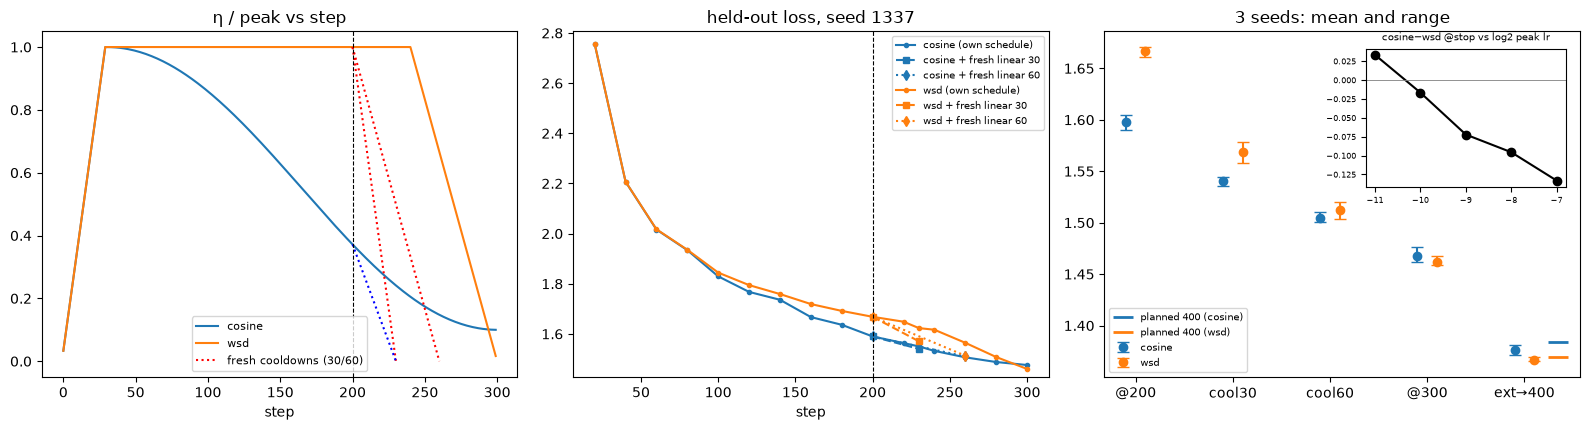

In [16]:
def _mean(xs):
    return sum(xs) / len(xs)


seeds = [str(s) for s in CFG["decision_seeds"]]
c30, c60 = COOL


def val(kind, s, what):
    r = SCHED[kind][s]
    B = r["branches"]
    return {"stop": r["eval_stop"], "train_stop": r["train_stop_mean10"],
            "own_c30": B["own"]["eval"][SCHED_STOP + c30], "own_c60": B["own"]["eval"][SCHED_STOP + c60],
            "lin30": B[f"lin{c30}"]["eval"][SCHED_STOP + c30], "sqrt30": B[f"sqrt{c30}"]["eval"][SCHED_STOP + c30],
            "lin60": B[f"lin{c60}"]["eval"][SCHED_STOP + c60], "sqrt60": B[f"sqrt{c60}"]["eval"][SCHED_STOP + c60],
            "end": B["own"]["eval"][SCHED_STEPS], "ext": B["ext"]["eval"][EXT_STEPS]}[what]


ROWS = [("stop", f"stopped at step {SCHED_STOP}"),
        ("own_c30", f"  own schedule to {SCHED_STOP + c30}"), ("lin30", f"  fresh linear cooldown, {c30} steps -> {SCHED_STOP + c30}"),
        ("sqrt30", f"  fresh (1-sqrt) cooldown, {c30} steps -> {SCHED_STOP + c30}"),
        ("own_c60", f"  own schedule to {SCHED_STOP + c60}"), ("lin60", f"  fresh linear cooldown, {c60} steps -> {SCHED_STOP + c60}"),
        ("sqrt60", f"  fresh (1-sqrt) cooldown, {c60} steps -> {SCHED_STOP + c60}"),
        ("end", f"  own schedule to {SCHED_STEPS} (the planned horizon)"),
        ("ext", f"  extended to {EXT_STEPS} (wsd: peak then decay; cosine: re-warm, peak, same decay)"),
        ("train_stop", f"train loss, mean of steps {SCHED_STOP - 9}-{SCHED_STOP}")]
SCHED_TABLE = {}
print(f"held-out loss (every held-out byte), {len(seeds)} paired seeds -> mean, and cosine - wsd per seed:\n")
print(f"{'':62s} {'cosine':>8s} {'wsd':>8s}   paired diff per seed (cosine - wsd)      sign")
for key, label in ROWS:
    c = [val("cosine", s, key) for s in seeds]
    w = [val("wsd", s, key) for s in seeds]
    d = [a - b for a, b in zip(c, w)]
    agree = all(x < 0 for x in d) or all(x > 0 for x in d)
    SCHED_TABLE[key] = {"cosine": c, "wsd": w, "diff": d, "mean_diff": _mean(d), "range_diff": max(d) - min(d), "unanimous": agree}
    print(f"{label:62s} {_mean(c):8.4f} {_mean(w):8.4f}   " + " ".join(f"{x:+.4f}" for x in d) + f"   {'unanimous' if agree else 'mixed'}")
print(f"\nplanned-for-{EXT_STEPS} references from scratch (seed {seeds[0]}): cosine {REF400['cosine']:.4f}, wsd {REF400['wsd']:.4f}; "
      f"cosine-to-0 control at {SCHED_STEPS}: {COSINE_TO_ZERO:.4f} vs cosine-to-10% {val('cosine', seeds[0], 'end'):.4f}")

gap_stop = SCHED_TABLE["stop"]
print(f"\nAt step {SCHED_STOP}: cosine - wsd = {gap_stop['mean_diff']:+.4f} (per seed " + ", ".join(f"{x:+.4f}" for x in gap_stop["diff"])
      + f"; {'unanimous' if gap_stop['unanimous'] else 'MIXED'} sign) -> "
      + ("cosine leads" if gap_stop["mean_diff"] < 0 and gap_stop["unanimous"] else "wsd leads" if gap_stop["mean_diff"] > 0 and gap_stop["unanimous"] else "no clear leader"))
LAD = {}
for peak, v in LADDER.items():
    d = [v[s]["cosine"] - v[s]["wsd"] for s in v]
    LAD[peak] = {"diff": d, "mean": _mean(d), "unanimous": all(x < 0 for x in d) or all(x > 0 for x in d)}
print("the sign of the stop-step gap vs peak lr: " + "; ".join(f"{float(p):.1e}: {v['mean']:+.4f} ({'unan.' if v['unanimous'] else 'mixed'})" for p, v in LAD.items()))
lad_vals = [LAD[p]["mean"] for p in LAD]
soft_check(lad_vals[0] > lad_vals[-1], "the stop-step gap should move toward cosine as the peak lr rises (the regime rule)")
# each schedule's own best peak lr at the stop step (tune both sides, applied to §4 itself)
OWN_BEST = {}
for kind in SCHED:
    means_ = {p: _mean([LADDER[p][s][kind] for s in LADDER[p]]) for p in LADDER}
    OWN_BEST[kind] = {"peak": float(min(means_, key=means_.get)), "loss": min(means_.values()), "means": {p: v for p, v in means_.items()}}
print(f"each schedule's own best peak lr at step {SCHED_STOP} (mean of 2 seeds): cosine {OWN_BEST['cosine']['peak']:.2e} ({OWN_BEST['cosine']['loss']:.4f}), "
      f"wsd {OWN_BEST['wsd']['peak']:.2e} ({OWN_BEST['wsd']['loss']:.4f}); at each one's own best, cosine - wsd = {OWN_BEST['cosine']['loss'] - OWN_BEST['wsd']['loss']:+.4f}")

# what the checkpoints are worth: the decisions, written from the numbers
best_cool = {kind: min(("lin30", "sqrt30"), key=lambda k: _mean(SCHED_TABLE[k][kind])) for kind in SCHED}
D = {}
D["stop_now"] = "cosine" if gap_stop["mean_diff"] < 0 else "wsd"
D["stop_now_margin"] = abs(gap_stop["mean_diff"])
D["stop_now_unanimous"] = gap_stop["unanimous"]
m30 = _mean(SCHED_TABLE[best_cool["wsd"]]["wsd"]) - _mean(SCHED_TABLE[best_cool["cosine"]]["cosine"])
D["plus_c30"] = "cosine" if m30 > 0 else "wsd"
D["plus_c30_margin"] = abs(m30)
m60 = _mean(SCHED_TABLE["lin60"]["wsd"]) - _mean(SCHED_TABLE["lin60"]["cosine"])
D["plus_c60"] = "cosine" if m60 > 0 else "wsd"
D["plus_c60_margin"] = abs(m60)
mext = SCHED_TABLE["ext"]["mean_diff"]
D["extend"] = "cosine" if mext < 0 else "wsd"
D["extend_margin"] = abs(mext)
# seed-matched: the planned-400 references were run with seed SEED, so compare that seed's extension
D["wsd_ext_vs_planned"] = SCHED["wsd"][str(SEED)]["branches"]["ext"]["eval"][EXT_STEPS] - REF400["wsd"]
D["cosine_ext_vs_planned"] = SCHED["cosine"][str(SEED)]["branches"]["ext"]["eval"][EXT_STEPS] - REF400["cosine"]
D["end"] = "cosine" if SCHED_TABLE["end"]["mean_diff"] < 0 else "wsd"
print(f"\nDECISION. Stopped at {SCHED_STOP} and nothing else: keep {D['stop_now']} (lower by {D['stop_now_margin']:.4f}, "
      f"{'every seed agrees' if D['stop_now_unanimous'] else 'seeds disagree'}).")
print(f"  With {c30} more steps (a fresh cooldown, best shape each): keep {D['plus_c30']} (by {D['plus_c30_margin']:.4f}); "
      f"with {c60} more: keep {D['plus_c60']} (by {D['plus_c60_margin']:.4f}).")
print(f"  If the horizon may extend to {EXT_STEPS}: keep {D['extend']} (by {D['extend_margin']:.4f}). The wsd trunk (seed {SEED}) lands "
      f"{D['wsd_ext_vs_planned']:+.6f} vs a run planned for {EXT_STEPS} from scratch with the same seed -- identical BY CONSTRUCTION (same warmup, same peak "
      f"through step {SCHED_STOP}, same data): a WSD checkpoint is on the path of every longer WSD run, which is what 'horizon-agnostic trunk' means. "
      f"The cosine checkpoint is not on the {EXT_STEPS}-run's path (its lr had decayed to {SCHED['cosine'][seeds[0]]['lr_at_stop'] / LR_WORK:.2f} x peak); "
      f"re-warmed and extended it lands {D['cosine_ext_vs_planned']:+.4f} vs a cosine run planned for {EXT_STEPS} (same seed).")
soft_check(abs(D["wsd_ext_vs_planned"]) < 1e-4, "the wsd extension should reproduce the planned run (same schedule prefix, same stream, same seed)")
print(f"  Full planned horizon ({SCHED_STEPS}): {D['end']} is lower ({SCHED_TABLE['end']['mean_diff']:+.4f}); the cosine-to-0 control "
      f"({COSINE_TO_ZERO:.4f} vs {val('cosine', seeds[0], 'end'):.4f}) shows the 10% floor is not what decides this.")
RESULTS["schedules"] = {"steps": SCHED_STEPS, "stop": SCHED_STOP, "cooldowns": COOL, "ext_steps": EXT_STEPS, "wsd_decay_frac": WSD_DECAY_FRAC,
                        "peak": LR_WORK, "lr_at_stop": {k: LR_TRACES[k][SCHED_STOP] for k in SCHEDULES},
                        "lr_area_to_stop": {k: sum(LR_TRACES[k][:SCHED_STOP]) / LR_WORK for k in SCHEDULES},
                        "table": SCHED_TABLE, "ladder": {p: {"peak": float(p), **v} for p, v in LAD.items()},
                        "planned_ext": REF400, "cosine_to_zero": COSINE_TO_ZERO, "decision": D, "seeds": seeds, "own_best": OWN_BEST,
                        "walls": {k: {s: SCHED[k][s]["wall"] for s in seeds} for k in SCHED}}
CURVES["schedules"] = {"lr": LR_TRACES, "runs": {k: {s: {"train": SCHED[k][s]["train"], "eval_main": SCHED[k][s]["eval_main"],
                                                          "branches": {b: {"eval": v["eval"], "train": v["train"]} for b, v in SCHED[k][s]["branches"].items()}}
                                                      for s in seeds} for k in SCHED}}
HEADLINE["sched_cosine_stop"] = fmt(_mean(SCHED_TABLE["stop"]["cosine"]))
HEADLINE["sched_wsd_stop"] = fmt(_mean(SCHED_TABLE["stop"]["wsd"]))
HEADLINE["sched_stop_diff"] = f"{gap_stop['mean_diff']:+.4f} ({'unanimous' if gap_stop['unanimous'] else 'mixed'})"
HEADLINE["sched_keep"] = f"{D['stop_now']} now; {D['plus_c30']} with +{c30}; {D['extend']} if extended"
HEADLINE["sched_ladder"] = "; ".join(f"{float(p):.1e}: {v['mean']:+.3f}" for p, v in LAD.items())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ax = axes[0]
for k in SCHEDULES:
    ax.plot(range(SCHED_STEPS), [x / LR_WORK for x in LR_TRACES[k]], label=k)
ax.plot([SCHED_STOP, SCHED_STOP + c30], [LR_TRACES["wsd"][SCHED_STOP] / LR_WORK, 0], "r:", label=f"fresh cooldowns ({c30}/{c60})")
ax.plot([SCHED_STOP, SCHED_STOP + c60], [LR_TRACES["wsd"][SCHED_STOP] / LR_WORK, 0], "r:")
ax.plot([SCHED_STOP, SCHED_STOP + c30], [LR_TRACES["cosine"][SCHED_STOP] / LR_WORK, 0], "b:")
ax.axvline(SCHED_STOP, color="k", lw=0.8, ls="--"); ax.set_title("η / peak vs step"); ax.set_xlabel("step"); ax.legend(fontsize=8)
ax = axes[1]
s0 = seeds[0]
for k, col in (("cosine", "C0"), ("wsd", "C1")):
    r_ = SCHED[k][s0]
    ev = {**r_["eval_main"], **r_["branches"]["own"]["eval"]}
    xs_ = sorted(ev)
    ax.plot(xs_, [ev[x] for x in xs_], "o-", color=col, ms=3, label=f"{k} (own schedule)")
    ax.plot([SCHED_STOP, SCHED_STOP + c30], [r_["eval_stop"], val(k, s0, "lin30")], "s--", color=col, ms=5, label=f"{k} + fresh linear {c30}")
    ax.plot([SCHED_STOP, SCHED_STOP + c60], [r_["eval_stop"], val(k, s0, "lin60")], "d:", color=col, ms=5, label=f"{k} + fresh linear {c60}")
ax.axvline(SCHED_STOP, color="k", lw=0.8, ls="--"); ax.set_title(f"held-out loss, seed {s0}"); ax.set_xlabel("step"); ax.legend(fontsize=7)
lo_ = min(min(SCHED_TABLE["end"]["cosine"]), min(SCHED_TABLE["end"]["wsd"]), min(SCHED_TABLE["lin60"]["wsd"]))
ax.set_ylim(lo_ - 0.03, SCHED[k][s0]["eval_main"][min(SCHED[k][s0]["eval_main"])] + 0.05)
ax = axes[2]
keys = ["stop", "lin30", "lin60", "end", "ext"]
labels = [f"@{SCHED_STOP}", f"cool{c30}", f"cool{c60}", f"@{SCHED_STEPS}", f"ext→{EXT_STEPS}"]
for i, k in enumerate(SCHEDULES):
    vals = [SCHED_TABLE[kk][k] for kk in keys]
    ax.errorbar([x + (i - 0.5) * 0.2 for x in range(len(keys))], [_mean(v) for v in vals],
                yerr=[[_mean(v) - min(v) for v in vals], [max(v) - _mean(v) for v in vals]], fmt="o", capsize=4, label=k)
ax.plot([len(keys) - 1 + 0.35], [REF400["cosine"]], "_", color="C0", ms=14, mew=2, label=f"planned {EXT_STEPS} (cosine)")
ax.plot([len(keys) - 1 + 0.35], [REF400["wsd"]], "_", color="C1", ms=14, mew=2, label=f"planned {EXT_STEPS} (wsd)")
ax.set_xticks(range(len(keys))); ax.set_xticklabels(labels); ax.set_title(f"{len(seeds)} seeds: mean and range"); ax.legend(fontsize=7, loc="lower left")
ax2 = ax.inset_axes([0.55, 0.55, 0.42, 0.4])
ax2.plot([math.log2(float(p)) for p in LAD], [LAD[p]["mean"] for p in LAD], "ko-")
ax2.axhline(0, color="0.5", lw=0.6); ax2.set_title("cosine−wsd @stop vs log2 peak lr", fontsize=7); ax2.tick_params(labelsize=6)
fig.tight_layout(); fig.savefig(ART / "plots" / "schedules.png", dpi=130); plt.show()

## §5 — Task 5: the learning-rate sweep at widths 256, 512, 1024 — and what to use at 4,096

Standard parametrization (every matrix ~ N(0, 0.02) whatever the width), 2 layers, heads
of 64, B = 16, T = 128, 300 steps with 30 warmup and cosine to 10%, AdamW (0.9, 0.95),
weight decay 0.1, clip 1.0 — everything fixed except the width and the learning rate, and
that sentence is the recipe the optimum belongs to. The metric is the held-out loss at
step 300 (every held-out byte, all four languages; the evals at 50% and 75% of the run
are logged too, and the argmin at 75% is shown to be within half an octave of the final one).

**Estimating the minimum.** The coarse grid is powers of two, two seeds each; a grid
argmin is quantized to whole octaves, and at width 1024 the two lowest grid points differ
by less than the seed spread, so the argmin alone cannot say where the optimum is. After
the coarse pass the two half-octave points around each argmin are run (both seeds), and
a third seed is run at the argmin and its neighbours. The estimate of η*(width) is the
vertex of the parabola through the three points closest to the minimum in log₂η, one
per seed — the quantity that is stable across seeds where the argmin is not. A run is
called diverged if its loss is not finite or ends above the untrained ln 259; with clip
1.0 nothing does at these widths, and the top of the grid is a loss cliff, not NaN.

**Extrapolating.** log₂η* is regressed on log₂width over every (width, seed) vertex.
Two theories bracket the slope: −1 (Tensor Programs V, Yang et al. — standard
parametrization with Adam, full gradient alignment) and −½ (the no-alignment exponent of
Everett et al. 2024, "Scaling Exponents Across Parameterizations and Optimizers"); over
the two doublings from 1024 to 4,096 they differ by exactly 2×. The value for width
4,096 is the regression's prediction; its confidence is stated as three separate numbers:
the regression's 95% prediction interval (t-quantile on n−2 degrees of freedom, with the
±¼-octave grid resolution added), the systematic bracket between the two theories, and
the *shape* of the basin — measured around each width's argmin (the numbers are below; where
×2 costs more than ÷2 the recommended value sits on the low side of the band).
A horizon counterfactual (100 and 600 steps at width 256) shows how far the optimum
moves per doubling of the horizon, so the reader knows what "for this recipe" costs.

**Then the prediction is tested.** Before any width-2048 run, the fit's prediction for
2048 and its interval are written down, with the pass criterion: five runs at half-octave
spacing around the predicted point (the same resolution the fitted widths had), the
parabola vertex through the argmin and its two neighbours must fall inside the interval,
and the loss at the predicted point must be within 1% of the best of the five. On a pass
the four-width refit becomes the final 4,096 value, reported beside the pre-registered
three-width forecast; on a fail the slope is declared non-constant and the 4,096 band is
widened to the theory bracket.

In [17]:
SWEEP_LOG2 = ({64: [-11, -9, -7, -5], 128: [-11, -9, -7, -5], 256: [-12, -10, -8, -6]} if FAST
              else {256: list(range(-12, -4)), 512: list(range(-13, -5)), 1024: list(range(-13, -5))})
SWEEP_SEEDS = CFG["sweep_seeds"]
THIRD_SEED = 1339
LN_V = math.log(VOCAB)


def sweep_run(d, lr, seed, steps=CFG["steps"], opt_kind="adamw", clip=CFG["clip"], **opt_kw):
    """One scheduled run: warmup + cosine to 10%, held-out loss at 50/75/100% of the run.
    Cached on disk (A11_RESUME) and in memory (other sections reuse these runs)."""
    cfg = {"section": "sweep", "d": d, "lr": lr, "seed": seed, "steps": steps, "opt": opt_kind, "fast": FAST,
           "warmup": CFG["warmup"], "B": CFG["B"], "T": CFG["T"], "n_layer": CFG["n_layer"], "clip": clip, **opt_kw}

    def go():
        m = make_model(d, seed=seed)
        opt = make_opt(opt_kind, m, lr, **opt_kw)
        st = CropStream(seed + 500)
        stream_sha = st.checksum(steps)
        evals = {steps // 2, (3 * steps) // 4, steps}
        rec = train_run(m, opt, st, lambda t: lr_cosine(t, lr, CFG["warmup"], steps), steps, clip=clip, eval_at=evals,
                        tag=f"{opt_kind}-d{d}-lr{lr:.2e}-s{seed}")
        final = rec["eval"].get(steps, float("nan"))
        diverged = rec["diverged"] is not None or not math.isfinite(final) or final > LN_V
        out = {"final": final, "evals": {str(k): v for k, v in rec["eval"].items()}, "diverged": diverged,
               "diverged_at": rec["diverged"], "wall": rec["wall"], "stream_sha": stream_sha,
               "train": rec["train"][:: max(1, steps // 60)], "train_last10": sum(rec["train"][-10:]) / 10,
               "gnorm_max": max(rec["gnorm"]) if rec["gnorm"] else float("nan"),
               "clip_bind_frac": (sum(1 for g in rec["gnorm"] if g > clip) / len(rec["gnorm"])) if clip and rec["gnorm"] else 0.0}
        del m, opt
        free_accelerator()
        return out

    return cached_run(cfg, go)


def lr_key(k):
    return f"{k:+.2f}"


SWEEP = {}          # SWEEP[d][k (log2, str)][seed (str)] -> run
for d in CFG["widths"]:
    SWEEP[str(d)] = {}
    t0_ = time.time()
    # the coarse pass
    for k in SWEEP_LOG2[d]:
        SWEEP[str(d)][lr_key(k)] = {str(s): sweep_run(d, 2.0 ** k, s) for s in SWEEP_SEEDS}
    # per-seed argmin on the coarse grid, then the two half-octave points around it (both seeds)
    argmins = {}
    for s in SWEEP_SEEDS:
        ok = {k: SWEEP[str(d)][lr_key(k)][str(s)]["final"] for k in SWEEP_LOG2[d] if not SWEEP[str(d)][lr_key(k)][str(s)]["diverged"]}
        argmins[s] = min(ok, key=ok.get)
    for s in SWEEP_SEEDS:
        for k in (argmins[s] - 0.5, argmins[s] + 0.5):
            SWEEP[str(d)].setdefault(lr_key(k), {})
            for s2 in SWEEP_SEEDS:
                if str(s2) not in SWEEP[str(d)][lr_key(k)]:
                    SWEEP[str(d)][lr_key(k)][str(s2)] = sweep_run(d, 2.0 ** k, s2)
    # a third seed at the coarse argmin (of the seed-mean) and its integer neighbours
    means = {k: sum(SWEEP[str(d)][lr_key(k)][str(s)]["final"] for s in SWEEP_SEEDS) / len(SWEEP_SEEDS) for k in SWEEP_LOG2[d]
             if all(not SWEEP[str(d)][lr_key(k)][str(s)]["diverged"] for s in SWEEP_SEEDS)}
    k_mean = min(means, key=means.get)
    for k in (k_mean - 1, k_mean, k_mean + 1):
        if lr_key(k) in SWEEP[str(d)]:
            SWEEP[str(d)][lr_key(k)][str(THIRD_SEED)] = sweep_run(d, 2.0 ** k, THIRD_SEED)
    ks = sorted(SWEEP[str(d)], key=float)
    print(f"[{elapsed()}] width {d:5d} ({RESULTS['model'][str(d)]:,} params, {len(ks)} lr points, "
          f"{sum(len(v) for v in SWEEP[str(d)].values())} runs): " + "  ".join(
        f"2^{float(k):g}: " + "/".join("div" if r["diverged"] else f"{r['final']:.3f}" for r in SWEEP[str(d)][k].values())
        for k in ks) + f"   ({time.time() - t0_:.0f}s)")
    free_accelerator()

[   808s] width   256 (1,740,800 params, 10 lr points, 23 runs): 2^-12: 1.839/1.838  2^-11: 1.660/1.665  2^-10: 1.538/1.548/1.540  2^-9.5: 1.509/1.505  2^-9: 1.479/1.495/1.464  2^-8.5: 1.481/1.484  2^-8: 1.520/1.529/1.549  2^-7: 1.912/1.932  2^-6: 2.324/2.263  2^-5: 2.610/2.601   (114s)


[  1104s] width   512 (6,627,328 params, 10 lr points, 23 runs): 2^-13: 1.785/1.791  2^-12: 1.634/1.639  2^-11: 1.476/1.501/1.505  2^-10.5: 1.424/1.434  2^-10: 1.383/1.410/1.439  2^-9.5: 1.425/1.407  2^-9: 1.474/1.469/1.479  2^-8: 1.765/1.788  2^-7: 2.075/2.082  2^-6: 2.358/2.409   (296s)


[  2189s] width  1024 (25,837,568 params, 11 lr points, 25 runs): 2^-13: 1.626/1.631  2^-12: 1.491/1.494  2^-11.5: 1.413/1.422  2^-11: 1.370/1.378/1.370  2^-10.5: 1.350/1.365  2^-10: 1.371/1.365/1.358  2^-9.5: 1.505/1.480  2^-9: 1.658/1.649/1.639  2^-8: 1.929/1.937  2^-7: 2.205/2.227  2^-6: 2.514/2.440   (1085s)


In [18]:
def analyze_width(d):
    row = SWEEP[str(d)]
    per_seed = {}
    for s in [str(x) for x in SWEEP_SEEDS] + [str(THIRD_SEED)]:
        pts = {float(k): row[k][s]["final"] for k in row if s in row[k] and not row[k][s]["diverged"]}
        if len(pts) >= 3:
            xv, ymin, kmin, edge = seed_vertex(pts)
            per_seed[s] = {"vertex_log2": xv, "fit_min": ymin, "argmin_log2": kmin, "on_edge": edge, "n_points": len(pts)}
    ks = sorted(row, key=float)
    mean_pts = {float(k): sum(r["final"] for r in row[k].values()) / len(row[k]) for k in ks
                if all(not r["diverged"] for r in row[k].values())}
    xv_m, ymin_m, kmin_m, edge_m = seed_vertex(mean_pts)
    # basin asymmetry: the loss one octave below / above the ARGMIN of the mean curve, in % of the
    # argmin's loss (centred on the argmin itself, never on a rounded neighbour)
    pen = {"centre_log2": kmin_m}
    for lab, k in (("div2", kmin_m - 1), ("x2", kmin_m + 1)):
        if lr_key(k) in row and lr_key(kmin_m) in row:
            m_k = sum(r["final"] for r in row[lr_key(k)].values()) / len(row[lr_key(k)])
            m_0 = sum(r["final"] for r in row[lr_key(kmin_m)].values()) / len(row[lr_key(kmin_m)])
            pen[lab] = (m_k / m_0 - 1) * 100
    # eval-step stability: argmin (seed 1337, coarse grid) at 50/75/100% of the run
    stab = {}
    for frac_key in ("half", "three_quarter", "final"):
        pass
    ev_keys = sorted({e for k in ks for r in row[k].values() for e in r["evals"]}, key=int)
    for e in ev_keys:
        pts = {float(k): row[k][str(SEED)]["evals"].get(e) for k in ks if str(SEED) in row[k] and row[k][str(SEED)]["evals"].get(e) is not None}
        stab[e] = min(pts, key=pts.get)
    # basin width: log2 range of the mean-curve points within 1% of the minimum
    within = [k for k, v in mean_pts.items() if v <= ymin_m * 1.01]
    return {"d": d, "per_seed": per_seed, "mean_curve": {lr_key(k): v for k, v in mean_pts.items()},
            "vertex_log2": xv_m, "fit_min": ymin_m, "argmin_log2": kmin_m, "on_grid_edge": edge_m,
            "vertex_spread_log2": max(v["vertex_log2"] for v in per_seed.values()) - min(v["vertex_log2"] for v in per_seed.values()),
            "argmin_per_seed": {s: v["argmin_log2"] for s, v in per_seed.items()},
            "penalty_pct": pen, "argmin_by_eval_step": stab, "basin_1pct_log2": [min(within), max(within)] if within else None,
            "n_diverged": sum(1 for k in ks for r in row[k].values() if r["diverged"]),
            "seed_spread_at_argmin": max(r["final"] for r in row[lr_key(kmin_m)].values()) - min(r["final"] for r in row[lr_key(kmin_m)].values())}


AN = {str(d): analyze_width(d) for d in CFG["widths"]}
print(f"{'width':>6} {'params':>12} {'grid argmin':>11} {'per-seed argmin':>18} {'vertex (log2)':>22} {'min loss':>9} "
      f"{'seed spread':>11} {'÷2 / ×2 penalty':>16} {'1%-basin (log2)':>16}")
for d, a in AN.items():
    vs = ", ".join(f"{v['vertex_log2']:.2f}" for v in a["per_seed"].values())
    print(f"{d:>6} {RESULTS['model'][d]:12,d} {'2^' + f'{a['argmin_log2']:g}':>11} {str([f'{v:g}' for v in a['argmin_per_seed'].values()]):>18} "
          f"{a['vertex_log2']:6.2f} [{vs}] {a['fit_min']:9.4f} {a['seed_spread_at_argmin']:11.4f} "
          f"{a['penalty_pct'].get('div2', float('nan')):+6.1f}% / {a['penalty_pct'].get('x2', float('nan')):+5.1f}% "
          f"{str(a['basin_1pct_log2']):>16}{'  (EDGE)' if a['on_grid_edge'] else ''}")
    print(f"       argmin by eval step (seed {SEED}): " + ", ".join(f"@{e}: 2^{k:g}" for e, k in a["argmin_by_eval_step"].items())
          + f"; diverged runs: {a['n_diverged']}")
soft_check(not any(a["on_grid_edge"] for a in AN.values()), "no optimum should sit on the grid edge")
if str(CFG["d_work"]) in AN:
    print(f"\nthe pre-registered workhorse lr 2^{math.log2(LR_WORK):.0f} vs the width-{CFG['d_work']} optimum: vertex 2^{AN[str(CFG['d_work'])]['vertex_log2']:.2f}")
    soft_check(abs(math.log2(LR_WORK) - AN[str(CFG["d_work"])]["vertex_log2"]) <= 1.0, "LR_WORK should be within one grid step of the optimum")

# ---- the regression over every (width, seed) vertex
FIT_X = [math.log2(int(d)) for d, a in AN.items() for s in a["per_seed"]]
FIT_Y = [a["per_seed"][s]["vertex_log2"] for d, a in AN.items() for s in a["per_seed"]]
TARGET_W = 4096
REG = regression(FIT_X, FIT_Y, math.log2(TARGET_W))
GRID_TERM = 0.25
half_total = math.sqrt(REG["pi_half"] ** 2 + GRID_TERM ** 2)
v1024 = AN[str(CFG["widths"][-1])]["vertex_log2"]
dist = math.log2(TARGET_W) - math.log2(CFG["widths"][-1])
theory = {"slope_-1": v1024 - 1.0 * dist, "slope_-0.5": v1024 - 0.5 * dist}
ci_lo, ci_hi = REG["slope"] - REG["t"] * REG["se_slope"], REG["slope"] + REG["t"] * REG["se_slope"]
print(f"\nregression of log2(lr*) on log2(width), {REG['n']} (width, seed) vertices: slope {REG['slope']:+.3f} ± {REG['se_slope']:.3f} (SE), "
      f"95% CI [{ci_lo:+.2f}, {ci_hi:+.2f}] vs the theory bracket -1 (full alignment) .. -0.5 (no alignment): the slope lies between the two exponents"
      + (" and the CI excludes BOTH (partial alignment)" if ci_lo > -1 and ci_hi < -0.5 else " and the CI reaches " + ("-1" if ci_lo <= -1 else "-0.5")))
print(f"prediction at width {TARGET_W}: log2 lr = {REG['pred']:.2f} -> {2 ** REG['pred']:.2e}; 95% prediction interval ±{REG['pi_half']:.2f} log2 "
      f"(t = {REG['t']:.3f} on {REG['dof']} dof), plus the ±{GRID_TERM} grid term -> ±{half_total:.2f} log2 = a ×{2 ** half_total:.2f} band each way: "
      f"[{2 ** (REG['pred'] - half_total):.2e}, {2 ** (REG['pred'] + half_total):.2e}]")
print(f"the theory bracket from the width-{CFG['widths'][-1]} vertex over {dist:.0f} doublings: slope -1 -> {2 ** theory['slope_-1']:.2e}, "
      f"slope -0.5 -> {2 ** theory['slope_-0.5']:.2e} (a 2x systematic spread)")
pen1024 = AN[str(CFG["widths"][-1])]["penalty_pct"]
print(f"basin at width {CFG['widths'][-1]}: ÷2 costs {pen1024.get('div2', float('nan')):+.1f}%, ×2 costs {pen1024.get('x2', float('nan')):+.1f}% -> "
      f"the value to USE is the low side of the band")
EXTRAP = {"target": TARGET_W, "fit_x": FIT_X, "fit_y": FIT_Y, "regression": REG, "grid_term": GRID_TERM, "half_total": half_total,
          "ci": [ci_lo, ci_hi], "ci_excludes_both_theory_ends": bool(ci_lo > -1 and ci_hi < -0.5),
          "pred_lr": 2 ** REG["pred"], "interval_lr": [2 ** (REG["pred"] - half_total), 2 ** (REG["pred"] + half_total)],
          "theory_bracket_log2": theory, "theory_bracket_lr": {k: 2 ** v for k, v in theory.items()},
          "use_lr": 2 ** (REG["pred"] - half_total / 2), "penalty_1024": pen1024}
print(f"stated value for width {TARGET_W}: point estimate {EXTRAP['pred_lr']:.2e}; I would run {EXTRAP['use_lr']:.2e} (half-way down the band, because ×2 is the expensive side)")

# ---- the horizon counterfactual: how far the optimum moves per doubling of the horizon (width d_work, one seed)
HORIZON = {}
if not FAST:
    for steps_ in (100, 600):
        pts = {}
        for k in SWEEP_LOG2[CFG["d_work"]]:
            r = sweep_run(CFG["d_work"], 2.0 ** k, SEED, steps=steps_)
            if not r["diverged"]:
                pts[float(k)] = r["final"]
        xv, ymin, kmin, edge = seed_vertex(pts)
        HORIZON[str(steps_)] = {"vertex_log2": xv, "argmin_log2": kmin, "min": ymin}
    HORIZON[str(CFG["steps"])] = {"vertex_log2": AN[str(CFG["d_work"])]["per_seed"][str(SEED)]["vertex_log2"],
                                  "argmin_log2": AN[str(CFG["d_work"])]["per_seed"][str(SEED)]["argmin_log2"],
                                  "min": AN[str(CFG["d_work"])]["per_seed"][str(SEED)]["fit_min"]}
    hs = sorted(HORIZON, key=int)
    drift = (HORIZON[hs[-1]]["vertex_log2"] - HORIZON[hs[0]]["vertex_log2"]) / math.log2(int(hs[-1]) / int(hs[0]))
    HORIZON["drift_per_doubling_log2"] = drift
    print(f"[{elapsed()}] horizon counterfactual at width {CFG['d_work']}: vertex 2^" + ", 2^".join(f"{HORIZON[h]['vertex_log2']:.2f} ({h} steps)" for h in hs)
          + f" -> {drift:+.2f} log2 per doubling of the horizon: the optimum belongs to THIS recipe (300 steps)")

 width       params grid argmin    per-seed argmin          vertex (log2)  min loss seed spread  ÷2 / ×2 penalty  1%-basin (log2)
   256    1,740,800        2^-9 ['-9', '-8.5', '-9']  -8.80 [-8.78, -8.65, -9.03]    1.4769      0.0318   +4.2% /  +3.6%     [-9.0, -8.5]
       argmin by eval step (seed 1337): @150: 2^-9.5, @225: 2^-8.5, @300: 2^-9; diverged runs: 0
   512    6,627,328       2^-10 ['-10', '-9.5', '-10']  -9.86 [-10.00, -9.72, -9.88]    1.4099      0.0559   +5.9% /  +4.5%    [-10.0, -9.5]
       argmin by eval step (seed 1337): @150: 2^-10, @225: 2^-10, @300: 2^-10; diverged runs: 0
  1024   25,837,568     2^-10.5 ['-10.5', '-10', '-10'] -10.41 [-10.51, -10.25, -10.46]    1.3572      0.0147   +4.4% /  +9.9%   [-10.5, -10.0]
       argmin by eval step (seed 1337): @150: 2^-10.5, @225: 2^-10.5, @300: 2^-10.5; diverged runs: 0

the pre-registered workhorse lr 2^-9 vs the width-256 optimum: vertex 2^-8.80

regression of log2(lr*) on log2(width), 9 (width, seed) vertices: slope 

[  2288s] horizon counterfactual at width 256: vertex 2^-8.44 (100 steps), 2^-8.78 (300 steps), 2^-9.17 (600 steps) -> -0.28 log2 per doubling of the horizon: the optimum belongs to THIS recipe (300 steps)


PRE-REGISTERED for width 2048: predicted log2 lr -11.29 ± 0.68 -> run 2^-12.5, 2^-12, 2^-11.5, 2^-11, 2^-10.5 (1 seed); PASS iff the half-octave vertex lies in [-11.97, -10.60] and loss(2^-11.5) <= 1.01 x best


[  3198s] width 2048 (102,006,784 params): 2^-12.5: 1.4152  2^-12: 1.3548  2^-11.5: 1.3141  2^-11: 1.3205  2^-10.5: 1.3606 -> argmin 2^-11.5, vertex -11.32
  verdict: vertex inside the interval, loss at 2^-11.5 within 1% of the best -> prediction HOLDS (909s); ÷2 / ×2 penalty around the argmin: +7.7% / +3.5%
  refit with 4 widths: slope -0.800 ± 0.061; width 4096: 2.28e-04 (±0.65 log2 = ×1.57) -> the value I would use: 1.82e-04 (the 3-width forecast was 2.31e-04)


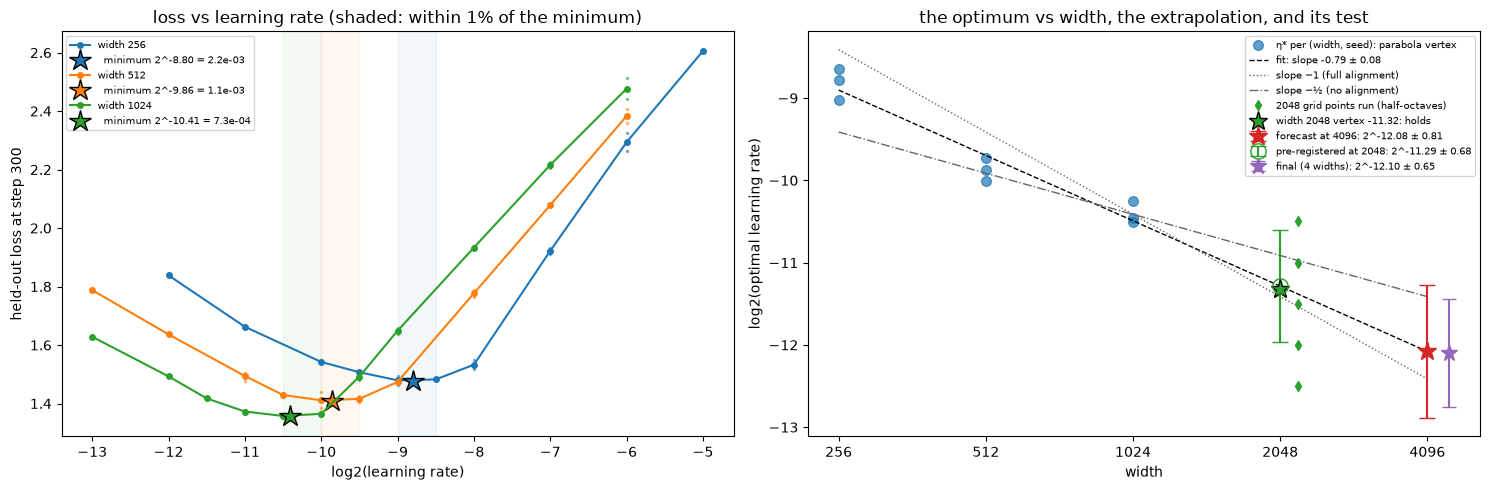

In [19]:
# the test the prediction can be given here: the next width, pre-registered before it runs
SPOT_W = 512 if FAST else 2048
spot_reg = regression(FIT_X, FIT_Y, math.log2(SPOT_W))
spot_pred, spot_half = spot_reg["pred"], math.sqrt(spot_reg["pi_half"] ** 2 + GRID_TERM ** 2)
k_c = round(spot_pred * 2) / 2                      # the nearest half-octave to the prediction
SPOT_GRID = [k_c - 1, k_c - 0.5, k_c, k_c + 0.5, k_c + 1]   # the same half-octave resolution as the fitted widths
SPOT = {"width": SPOT_W, "pre_registered": {"pred_log2": spot_pred, "pi_half_log2": spot_half, "grid_log2": SPOT_GRID,
                                            "criterion": "the parabola vertex through the argmin and its two half-octave neighbours lies inside pred ± pi_half, "
                                                         "AND the loss at the predicted half-octave is within 1% of the best of the five"},
        "runs": {}}
print(f"PRE-REGISTERED for width {SPOT_W}: predicted log2 lr {spot_pred:.2f} ± {spot_half:.2f} -> run 2^{', 2^'.join(f'{k:g}' for k in SPOT_GRID)} (1 seed); "
      f"PASS iff the half-octave vertex lies in [{spot_pred - spot_half:.2f}, {spot_pred + spot_half:.2f}] and loss(2^{k_c:g}) <= 1.01 x best")
t0_ = time.time()
for k in SPOT_GRID:
    SPOT["runs"][lr_key(k)] = sweep_run(SPOT_W, 2.0 ** k, SEED)
finals = {float(k): r["final"] if not r["diverged"] else float("inf") for k, r in SPOT["runs"].items()}
best_k = min(finals, key=finals.get)
xv, ymin, kmin_spot, edge_spot = seed_vertex({k: v for k, v in finals.items() if math.isfinite(v)})
SPOT["vertex_log2"] = None if edge_spot else xv
SPOT["best_log2"] = best_k
SPOT["pass_vertex"] = SPOT["vertex_log2"] is not None and abs(xv - spot_pred) <= spot_half
SPOT["pass_loss"] = finals[float(k_c)] <= 1.01 * finals[best_k]
SPOT["holds"] = SPOT["pass_vertex"] and SPOT["pass_loss"]
SPOT["penalty_x2_pct"] = (finals[best_k + 1] / finals[best_k] - 1) * 100 if best_k + 1 in finals and math.isfinite(finals[best_k + 1]) else float("nan")
SPOT["penalty_div2_pct"] = (finals[best_k - 1] / finals[best_k] - 1) * 100 if best_k - 1 in finals else float("nan")
SPOT["wall"] = time.time() - t0_
print(f"[{elapsed()}] width {SPOT_W} ({count_params(LM(SPOT_W)):,} params): " + "  ".join(f"2^{k:g}: {v:.4f}" for k, v in sorted(finals.items()))
      + (f" -> argmin 2^{best_k:g}, vertex {xv:.2f}" if SPOT["vertex_log2"] is not None else f" -> argmin 2^{best_k:g} on the grid EDGE"))
print(f"  verdict: vertex {'inside' if SPOT['pass_vertex'] else 'OUTSIDE'} the interval, loss at 2^{k_c:g} {'within' if SPOT['pass_loss'] else 'NOT within'} 1% of the best "
      f"-> prediction {'HOLDS' if SPOT['holds'] else 'FAILS'} ({SPOT['wall']:.0f}s); ÷2 / ×2 penalty around the argmin: {SPOT['penalty_div2_pct']:+.1f}% / {SPOT['penalty_x2_pct']:+.1f}%")
xv = SPOT["vertex_log2"]

# on a pass the next width becomes the fourth point of the fit: the final 4096 value, beside the forecast
FINAL = None
if SPOT["holds"]:
    REG4 = regression(FIT_X + [math.log2(SPOT_W)], FIT_Y + [xv], math.log2(TARGET_W))
    half4 = math.sqrt(REG4["pi_half"] ** 2 + GRID_TERM ** 2)
    FINAL = {"regression": REG4, "half_total": half4, "pred_lr": 2 ** REG4["pred"],
             "interval_lr": [2 ** (REG4["pred"] - half4), 2 ** (REG4["pred"] + half4)], "use_lr": 2 ** (REG4["pred"] - half4 / 2)}
    print(f"  refit with {len(CFG['widths']) + 1} widths: slope {REG4['slope']:+.3f} ± {REG4['se_slope']:.3f}; width {TARGET_W}: {FINAL['pred_lr']:.2e} "
          f"(±{half4:.2f} log2 = ×{2 ** half4:.2f}) -> the value I would use: {FINAL['use_lr']:.2e} (the 3-width forecast was {EXTRAP['pred_lr']:.2e})")
else:
    print(f"  the slope is not constant across widths: the {TARGET_W} band widens to the theory bracket "
          f"[{min(EXTRAP['theory_bracket_lr'].values()):.2e}, {max(EXTRAP['theory_bracket_lr'].values()):.2e}]")

RESULTS["lr_sweep"] = {"widths": CFG["widths"], "grid_log2": {str(d): v for d, v in SWEEP_LOG2.items()}, "seeds": SWEEP_SEEDS, "third_seed": THIRD_SEED,
                       "steps": CFG["steps"], "analysis": AN, "extrapolation": EXTRAP, "spot_check": SPOT, "final": FINAL, "horizon": HORIZON,
                       "table": {d: {k: {s: {"final": r["final"], "diverged": r["diverged"], "evals": r["evals"], "wall": r["wall"],
                                             "gnorm_max": r["gnorm_max"], "clip_bind_frac": r["clip_bind_frac"]}
                                         for s, r in v.items()} for k, v in row.items()} for d, row in SWEEP.items()}}
CURVES["lr_sweep"] = {d: {k: {s: r["train"] for s, r in v.items()} for k, v in row.items()} for d, row in SWEEP.items()}
HEADLINE["lr_minima"] = "; ".join(f"{d}: 2^{a['vertex_log2']:.2f} ({2 ** a['vertex_log2']:.1e})" for d, a in AN.items())
HEADLINE["lr_slope"] = f"{REG['slope']:+.2f} ± {REG['se_slope']:.2f}"
HEADLINE["lr_4096_forecast"] = f"{EXTRAP['pred_lr']:.2e} (×{2 ** half_total:.2f} band)"
HEADLINE["lr_spot"] = f"{SPOT_W}: {'holds' if SPOT['holds'] else 'fails'} (vertex {xv:.2f} vs {spot_pred:.2f}±{spot_half:.2f})" if xv is not None else f"{SPOT_W}: no vertex"
HEADLINE["lr_4096_final"] = f"{FINAL['pred_lr']:.1e}, use {FINAL['use_lr']:.1e}" if FINAL else "theory bracket"

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
top = max(v for a in AN.values() for v in a["mean_curve"].values()) + 0.2
for i, (d, a) in enumerate(AN.items()):
    ks = sorted(a["mean_curve"], key=float)
    ax.plot([float(k) for k in ks], [a["mean_curve"][k] for k in ks], "o-", color=f"C{i}", ms=4, label=f"width {d}")
    for k, runs in SWEEP[d].items():
        for r in runs.values():
            ax.plot(float(k), top if r["diverged"] else r["final"], "x" if r["diverged"] else ".", color=f"C{i}", ms=6 if r["diverged"] else 3, alpha=0.5)
    ax.plot(a["vertex_log2"], a["fit_min"], "*", color=f"C{i}", ms=16, mec="k", label=f"  minimum 2^{a['vertex_log2']:.2f} = {2 ** a['vertex_log2']:.1e}")
    if a["basin_1pct_log2"]:
        ax.axvspan(a["basin_1pct_log2"][0], a["basin_1pct_log2"][1], color=f"C{i}", alpha=0.06)
ax.set_xlabel("log2(learning rate)"); ax.set_ylabel(f"held-out loss at step {CFG['steps']}"); ax.set_title("loss vs learning rate (shaded: within 1% of the minimum)")
ax.legend(fontsize=7)
ax = axes[1]
ax.plot(FIT_X, FIT_Y, "o", ms=7, alpha=0.7, label="η* per (width, seed): parabola vertex")
xx = [min(FIT_X), math.log2(TARGET_W)]
ax.plot(xx, [REG["intercept"] + REG["slope"] * x for x in xx], "k--", lw=1, label=f"fit: slope {REG['slope']:+.2f} ± {REG['se_slope']:.2f}")
ax.plot(xx, [v1024 - 1.0 * (x - math.log2(CFG["widths"][-1])) for x in xx], ":", color="0.4", lw=1, label="slope −1 (full alignment)")
ax.plot(xx, [v1024 - 0.5 * (x - math.log2(CFG["widths"][-1])) for x in xx], "-.", color="0.4", lw=1, label="slope −½ (no alignment)")
ax.errorbar([math.log2(TARGET_W)], [REG["pred"]], yerr=[[half_total], [half_total]], fmt="*", ms=14, color="C3", capsize=6,
            label=f"forecast at {TARGET_W}: 2^{REG['pred']:.2f} ± {half_total:.2f}")
ax.errorbar([math.log2(SPOT_W)], [spot_pred], yerr=[[spot_half], [spot_half]], fmt="o", mfc="none", ms=11, color="C2", capsize=6, label=f"pre-registered at {SPOT_W}: 2^{spot_pred:.2f} ± {spot_half:.2f}")
for k, v in finals.items():
    ax.plot(math.log2(SPOT_W) + 0.12, k, "d", color="C2", ms=5)
ax.plot([], [], "d", color="C2", ms=5, label=f"{SPOT_W} grid points run (half-octaves)")
if xv is not None:
    ax.plot(math.log2(SPOT_W), xv, "*", color="C2", ms=14, mec="k", label=f"width {SPOT_W} vertex {xv:.2f}: {'holds' if SPOT['holds'] else 'fails'}")
if FINAL:
    ax.errorbar([math.log2(TARGET_W) + 0.15], [FINAL["regression"]["pred"]], yerr=[[FINAL["half_total"]], [FINAL["half_total"]]], fmt="*", ms=12, color="C4", capsize=5,
                label=f"final ({len(CFG['widths']) + 1} widths): 2^{FINAL['regression']['pred']:.2f} ± {FINAL['half_total']:.2f}")
ticks = CFG["widths"] + [SPOT_W, TARGET_W]
ax.set_xticks([math.log2(d) for d in ticks]); ax.set_xticklabels([str(d) for d in ticks])
ax.set_xlabel("width"); ax.set_ylabel("log2(optimal learning rate)"); ax.set_title("the optimum vs width, the extrapolation, and its test"); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(ART / "plots" / "lr_sweep.png", dpi=130); plt.show()

## §6 — Task 6: tune both sides before accepting a comparison

The rule is easy to state and expensive to honour: **an optimizer is not slower until it
has been given its own learning rate — and its own weight decay, in its own units.** Two
challengers to the tuned AdamW of §5 at the workhorse width: SGD with Nesterov momentum,
and Lion (sign of an interpolated momentum, decoupled decay — implemented here in twelve
lines and checked step by step against a float64 transcription of the paper's algorithm,
with the common mis-ordered port shown to fail that check). Every arm sees identical
data, the same schedule shape, steps, warmup and clip; the decay convention is stated
once for all three (a per-step shrink η·λ matched to AdamW's, because "λ = 0.1" is not a
number that transfers between optimizers, which is measured too).

The comparison is run in *both* naive directions and then fairly:

- **naive A** — the challenger at AdamW's best learning rate: what a port does when it
  keeps the config and swaps the class;
- **naive B** — the *tuned* challenger against AdamW at a default learning rate (torch's
  1e-3 and the common 3e-4): the direction the requirement's sentence describes — a
  well-tuned new method measured against a badly tuned baseline;
- **fair** — each optimizer at the argmin of its own sweep, refined to half-octaves, then
  confirmed on three seeds disjoint from the seed that chose the argmin.

`fair_compare()` is the protocol as code. It refuses to name a winner if either optimum sits
on a grid edge (the sweep was too narrow), if the two sides' run configurations or data
streams differ, or if the three-seed ranges overlap or the gap is inside the pooled range
— and it prints, per arm, the runs spent on tuning, the fixed knobs, the basin width and
the fraction of steps on which gradient clipping bound, because clipping at 1.0 turns out
to be a load-bearing third party in every arm (one unclipped run per optimizer says how
much). The hypotheses are stated before the numbers and left falsifiable: the naive
comparisons exaggerate each challenger's deficit by a large factor; after tuning, each
challenger is compared with AdamW on its own terms; and one pair — the two challengers
against each other — is expected to land inside the noise, where the protocol's refusal
is the correct output.

In [20]:
FAIR_D = CFG["d_work"]
SHRINK = LR_WORK * CFG["weight_decay"]          # AdamW's per-step decay shrink at the workhorse lr: eta * lambda
FAIR_GRIDS = {
    "adamw": {"log2": SWEEP_LOG2[FAIR_D], "kw": {}},
    "sgd": {"log2": [-4, -2, 0, 2] if FAST else list(range(-5, 4)), "kw": {"momentum": 0.9, "nesterov": True}},
    "lion": {"log2": [-15, -13, -11, -9] if FAST else list(range(-16, -7)), "kw": {}},
}
CONFIRM_SEEDS = [1338] if FAST else [1338, 1339, 1340]     # disjoint from the selection seed
ADAMW_DEFAULTS = {"torch default 1e-3": 1e-3, "common LLM default 3e-4": 3e-4}


def challenger_kw(kind, lr):
    """The one decay convention: match AdamW's per-step shrink eta*lambda, so lambda = SHRINK/lr.
    (This ties lambda to lr inside a challenger's sweep -- disclosed, and tested at fixed lr below.)"""
    kw = dict(FAIR_GRIDS[kind]["kw"])
    if kind != "adamw":
        kw["wd"] = SHRINK / lr
    return kw


def fair_run(kind, lr, seed, **extra):
    return sweep_run(FAIR_D, lr, seed, opt_kind=kind, **{**challenger_kw(kind, lr), **extra})


# ---- Lion: HandLion vs a float64 transcription of Chen et al. 2023, Algorithm 2, 20 steps; the mis-ordered port fails
def lion_algorithm2(w, grads, lr, b1=0.9, b2=0.99, wd=0.0, misordered=False):
    m = torch.zeros_like(w)
    for g in grads:
        if misordered:                       # the common bug: momentum updated before the interpolation
            m = b2 * m + (1 - b2) * g
            c = b1 * m + (1 - b1) * g
            w = w - lr * (torch.sign(c) + wd * w)
        else:
            c = b1 * m + (1 - b1) * g
            w = w - lr * (torch.sign(c) + wd * w)
            m = b2 * m + (1 - b2) * g
    return w


g_ = torch.Generator().manual_seed(3)
w0_ = torch.randn(64, 32, generator=g_, dtype=torch.float64)
grads_ = [torch.randn(64, 32, generator=g_, dtype=torch.float64) * (10.0 ** (i - 10)) for i in range(20)]   # 1e-10 .. 1e9 scales
p_ = nn.Parameter(w0_.clone())
lion_ = HandLion([p_], 1e-3, weight_decay=0.5)
for g in grads_:
    p_.grad = g.clone()
    lion_.step()
ref_ = lion_algorithm2(w0_, grads_, 1e-3, wd=0.5)
bad_ = lion_algorithm2(w0_, grads_, 1e-3, wd=0.5, misordered=True)
lion_dev = float((p_.detach() - ref_).abs().max())
lion_bad = float((bad_ - ref_).abs().max())
assert lion_dev < 1e-12 and lion_bad > 1e-4
print(f"HandLion vs Algorithm 2 (float64, 20 steps, gradient scales 1e-10..1e9): max|dw| = {lion_dev:.1e}; the mis-ordered port differs by {lion_bad:.1e}")
step1_ = float((HandLion([nn.Parameter(w0_.clone())], 1e-3).params[0].detach() - w0_).abs().max())
RESULTS["fair_compare"] = {"lion_check": {"vs_algorithm2": lion_dev, "misordered_port": lion_bad}}

# ---- SGD: HandSGD == torch.optim.SGD(nesterov=True) bitwise, 10 steps of the real model on the CPU
mA_ = make_model(FAIR_D, seed=7, device=CHECK_DEVICE); mB_ = copy.deepcopy(mA_)
oA_ = HandSGD(mA_.parameters(), 0.1, momentum=0.9, nesterov=True)
oB_ = torch.optim.SGD(mB_.parameters(), lr=0.1, momentum=0.9, nesterov=True, foreach=False)
sA_, sB_ = CropStream(5, B=4), CropStream(5, B=4)
for _ in range(10):
    for m_, o_, s_ in ((mA_, oA_, sA_), (mB_, oB_, sB_)):
        b_ = s_.next(CHECK_DEVICE)
        loss_ = token_weighted_loss(m_(b_), b_)
        m_.zero_grad(set_to_none=True); loss_.backward(); o_.step()
assert all(torch.equal(a, b) for a, b in zip(mA_.parameters(), mB_.parameters()))
print("HandSGD == torch.optim.SGD(momentum=0.9, nesterov=True): bitwise over 10 steps on the CPU")
del mA_, mB_

# ---- the sweeps: coarse grid (selection seed), then half-octave refinement around the argmin
FAIR = {}
for kind, spec in FAIR_GRIDS.items():
    t0_ = time.time()
    grid = {lr_key(k): fair_run(kind, 2.0 ** k, SEED) for k in spec["log2"]}
    ok = {k: r["final"] for k, r in grid.items() if not r["diverged"]}
    k0 = float(min(ok, key=ok.get))
    for k in (k0 - 0.5, k0 + 0.5):
        grid[lr_key(k)] = fair_run(kind, 2.0 ** k, SEED)
    ok = {k: r["final"] for k, r in grid.items() if not r["diverged"]}
    k_best = float(min(ok, key=ok.get))
    keys = sorted(grid, key=float)
    edge = lr_key(k_best) in (keys[0], keys[-1])
    within = [float(k) for k, v in ok.items() if v <= ok[lr_key(k_best)] * 1.01]
    FAIR[kind] = {"grid": grid, "coarse_argmin_log2": k0, "argmin_log2": k_best, "on_edge": edge, "n_tuning_runs": len(grid),
                  "basin_1pct_log2": [min(within), max(within)], "fixed_knobs": {**spec["kw"], "clip": CFG["clip"], "warmup": CFG["warmup"],
                                                                                  "schedule": "cosine to 10%", "wd_convention": "eta*lambda = AdamW's" if kind != "adamw" else "lambda = 0.1"}}
    print(f"[{elapsed()}] {kind:5s} {len(grid)} tuning runs: " + "  ".join(f"2^{float(k):g}: {'div' if grid[k]['diverged'] else f'{grid[k][chr(102) + chr(105) + chr(110) + chr(97) + chr(108)]:.3f}'}" for k in keys)
          + f"  -> argmin 2^{k_best:g}{' (EDGE)' if edge else ''}, 1%-basin {FAIR[kind]['basin_1pct_log2']}   ({time.time() - t0_:.0f}s)")

HandLion vs Algorithm 2 (float64, 20 steps, gradient scales 1e-10..1e9): max|dw| = 5.3e-15; the mis-ordered port differs by 2.0e-03


HandSGD == torch.optim.SGD(momentum=0.9, nesterov=True): bitwise over 10 steps on the CPU
[  3199s] adamw 10 tuning runs: 2^-12: 1.839  2^-11: 1.660  2^-10: 1.538  2^-9.5: 1.509  2^-9: 1.479  2^-8.5: 1.481  2^-8: 1.520  2^-7: 1.912  2^-6: 2.324  2^-5: 2.610  -> argmin 2^-9, 1%-basin [-9.0, -8.5]   (0s)


[  3253s] sgd   11 tuning runs: 2^-5: 1.842  2^-4: 1.733  2^-3: 1.632  2^-2.5: 1.599  2^-2: 1.599  2^-1.5: 1.620  2^-1: 1.853  2^0: 2.411  2^1: 3.042  2^2: 4.876  2^3: div  -> argmin 2^-2.5, 1%-basin [-2.5, -2.0]   (55s)


[  3310s] lion  11 tuning runs: 2^-16: 3.581  2^-15: 2.918  2^-14: 2.356  2^-13: 1.921  2^-12: 1.672  2^-11: 1.575  2^-10.5: 1.559  2^-10: 1.564  2^-9.5: 1.646  2^-9: 1.918  2^-8: 2.359  -> argmin 2^-10.5, 1%-basin [-10.5, -10.0]   (57s)


[  3316s] adamw at 2^-9 = 1.95e-03: selection seed 1.4791; 3 confirmation seeds -> 1.4774 [1.4636..1.4954]; clip bound on 60% of steps; 1%-basin [-9.0, -8.5] (log2)


[  3331s] sgd   at 2^-2.5 = 1.77e-01: selection seed 1.5988; 3 confirmation seeds -> 1.5906 [1.5848..1.5972]; clip bound on 48% of steps; 1%-basin [-2.5, -2.0] (log2)


[  3346s] lion  at 2^-10.5 = 6.91e-04: selection seed 1.5591; 3 confirmation seeds -> 1.5505 [1.5415..1.5598]; clip bound on 46% of steps; 1%-basin [-10.5, -10.0] (log2)



comparison                                      AdamW challenger      gap  verdict
naive A: sgd at AdamW lr                       1.4774     2.8343  +1.3570  'sgd is +92% worse' (challenger untuned)
naive B: tuned sgd vs AdamW @ torch default 1e-3   1.5338     1.5906  +0.0568  'sgd trails AdamW by 0.057' (baseline untuned)
naive B: tuned sgd vs AdamW @ common LLM default 3e-4   1.7800     1.5906  -0.1893  'sgd beats AdamW by 0.189' (baseline untuned)
fair: sgd at its own lr, 3 fresh seeds         1.4774     1.5906  +0.1133  adamw wins by 0.1133 nats (pooled 3-seed range 0.0318)
naive A: lion at AdamW lr                      1.4774     1.9146  +0.4372  'lion is +30% worse' (challenger untuned)
naive B: tuned lion vs AdamW @ torch default 1e-3   1.5338     1.5505  +0.0167  'lion trails AdamW by 0.017' (baseline untuned)
naive B: tuned lion vs AdamW @ common LLM default 3e-4   1.7800     1.5505  -0.2294  'lion beats AdamW by 0.229' (baseline untuned)
fair: lion at its own lr, 3 fresh see

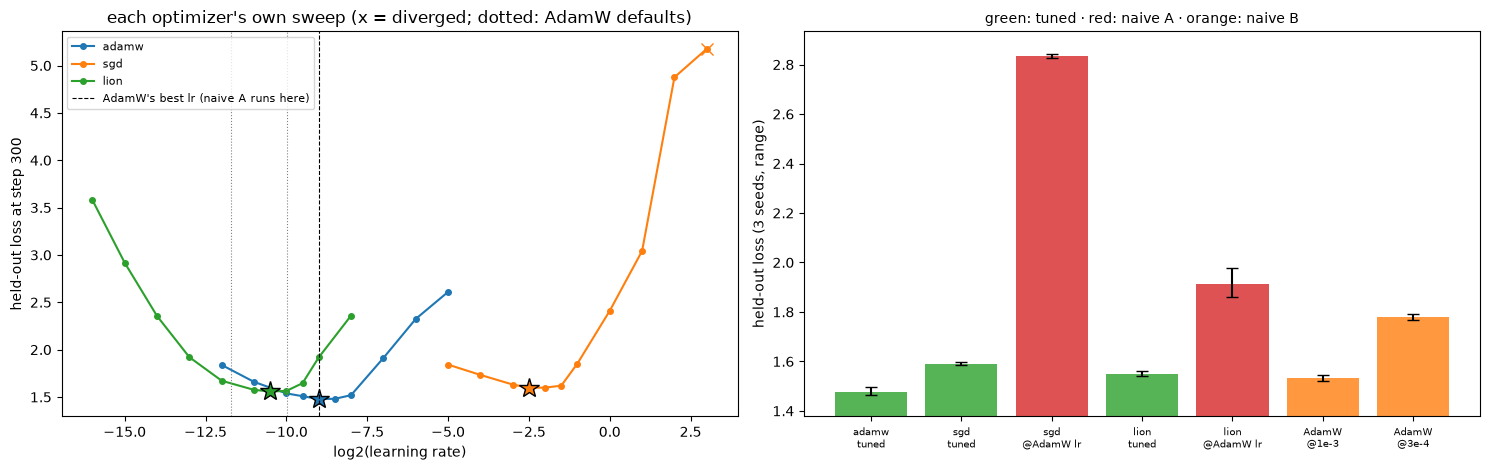

In [21]:
RUN_CONFIG = {"steps": CFG["steps"], "warmup": CFG["warmup"], "schedule": "cosine to 10%", "clip": CFG["clip"], "B": CFG["B"], "T": CFG["T"], "d": FAIR_D}
SIDES = {}
for kind, FK in FAIR.items():
    lr_best = 2.0 ** FK["argmin_log2"]
    runs = [fair_run(kind, lr_best, s) for s in CONFIRM_SEEDS]
    seeds = [r["final"] for r in runs]
    bind = [r["clip_bind_frac"] for r in runs] + [FK["grid"][lr_key(FK["argmin_log2"])]["clip_bind_frac"]]
    SIDES[kind] = {"argmin_log2": FK["argmin_log2"], "argmin_lr": lr_best, "selection_seed_loss": FK["grid"][lr_key(FK["argmin_log2"])]["final"],
                   "on_edge": FK["on_edge"], "seeds": seeds, "mean": mean_of(seeds), "range": [min(seeds), max(seeds)],
                   "config": RUN_CONFIG, "stream_sha": [r["stream_sha"] for r in runs], "n_tuning_runs": FK["n_tuning_runs"],
                   "basin_1pct_log2": FK["basin_1pct_log2"], "fixed_knobs": FK["fixed_knobs"], "clip_bind_frac": mean_of(bind)}
    # each confirmation seed has its own stream; what must match is each seed's stream ACROSS optimizers (checked in fair_compare)
    print(f"[{elapsed()}] {kind:5s} at 2^{FK['argmin_log2']:g} = {lr_best:.2e}: selection seed {SIDES[kind]['selection_seed_loss']:.4f}; "
          f"{len(seeds)} confirmation seeds -> {SIDES[kind]['mean']:.4f} [{min(seeds):.4f}..{max(seeds):.4f}]; clip bound on {SIDES[kind]['clip_bind_frac'] * 100:.0f}% of steps; "
          f"1%-basin {FK['basin_1pct_log2']} (log2)")

# ---- naive A: the challenger at AdamW's best lr (a careless port)
adam_lr = SIDES["adamw"]["argmin_lr"]
NAIVE_A = {}
for kind in ("sgd", "lion"):
    runs = [fair_run(kind, adam_lr, s) for s in CONFIRM_SEEDS]
    finals = [r["final"] for r in runs if not r["diverged"]]
    NAIVE_A[kind] = {"lr": adam_lr, "seeds": finals, "diverged": sum(1 for r in runs if r["diverged"]), "mean": mean_of(finals) if finals else float("nan")}
# ---- naive B: the tuned challenger vs AdamW at a default lr (the direction the requirement describes)
NAIVE_B = {}
for label, lr in ADAMW_DEFAULTS.items():
    runs = [fair_run("adamw", lr, s) for s in CONFIRM_SEEDS]
    NAIVE_B[label] = {"lr": lr, "seeds": [r["final"] for r in runs], "mean": mean_of([r["final"] for r in runs])}
# ---- clipping is a third party: one unclipped run per optimizer at its (clipped) argmin, compared with
# the SAME seed's clipped run -- and, because 'unclipped at the clipped optimum' is itself an untuned
# comparison, an unclipped lr sweep for SGD (the optimizer clipping affects most)
UNCLIPPED = {}
for kind in FAIR:
    r = fair_run(kind, SIDES[kind]["argmin_lr"], SEED, clip=0.0)
    UNCLIPPED[kind] = {"final": r["final"], "diverged": r["diverged"], "diverged_at": r["diverged_at"],
                       "clipped_same_seed": SIDES[kind]["selection_seed_loss"], "delta_same_seed": r["final"] - SIDES[kind]["selection_seed_loss"]}
SGD_UNCLIPPED_GRID = {}
for k in ([-4, -3] if FAST else [-6, -5.5, -5, -4.5, -4, -3.5, -3, -2.5]):
    r = fair_run("sgd", 2.0 ** k, SEED, clip=0.0)
    SGD_UNCLIPPED_GRID[lr_key(k)] = {"final": r["final"], "diverged": r["diverged"]}
_ok = {k: v["final"] for k, v in SGD_UNCLIPPED_GRID.items() if not v["diverged"]}
SGD_UNCLIPPED_BEST = {"log2": float(min(_ok, key=_ok.get)), "final": min(_ok.values()),
                      "on_edge": min(_ok, key=_ok.get) in (min(SGD_UNCLIPPED_GRID, key=float), max(SGD_UNCLIPPED_GRID, key=float))}
# ---- weight decay in the wrong units, and the tied-lambda confound at fixed lr
WD_CHECK = {"sgd_wd_0.1_verbatim": fair_run("sgd", SIDES["sgd"]["argmin_lr"], SEED, wd=0.1)["final"],
            "sgd_wd_0": fair_run("sgd", SIDES["sgd"]["argmin_lr"], SEED, wd=0.0)["final"],
            "lion_wd_0": fair_run("lion", SIDES["lion"]["argmin_lr"], SEED, wd=0.0)["final"],
            "lion_wd_1.0": fair_run("lion", SIDES["lion"]["argmin_lr"], SEED, wd=1.0)["final"],
            "lion_wd_matched": SIDES["lion"]["selection_seed_loss"], "sgd_wd_matched": SIDES["sgd"]["selection_seed_loss"]}
# ---- Lion's paper rule, both ends: lr = AdamW/3 with wd x3, and lr = AdamW/10 with wd x10
LION_PORTS = {"paper rule, /3 end": fair_run("lion", adam_lr / 3, SEED, wd=CFG["weight_decay"] * 3)["final"],
              "paper rule, /10 end": fair_run("lion", adam_lr / 10, SEED, wd=CFG["weight_decay"] * 10)["final"]}

print(f"\n{'comparison':44s} {'AdamW':>8s} {'challenger':>10s} {'gap':>8s}  verdict")
VERDICTS = {}
for kind in ("sgd", "lion"):
    gA = NAIVE_A[kind]["mean"] - SIDES["adamw"]["mean"]
    VERDICTS[f"naiveA_{kind}"] = {"gap": gA, "verdict": f"'{kind} is {gA / SIDES['adamw']['mean'] * 100:+.0f}% worse' (challenger untuned)"}
    print(f"{'naive A: ' + kind + ' at AdamW lr':44s} {SIDES['adamw']['mean']:8.4f} {NAIVE_A[kind]['mean']:10.4f} {gA:+8.4f}  {VERDICTS[f'naiveA_{kind}']['verdict']}")
    for label, nb_ in NAIVE_B.items():
        gB = SIDES[kind]["mean"] - nb_["mean"]
        VERDICTS[f"naiveB_{kind}_{label}"] = {"gap": gB, "verdict": f"'{kind} {'beats' if gB < 0 else 'trails'} AdamW by {abs(gB):.3f}' (baseline untuned)"}
        print(f"{'naive B: tuned ' + kind + ' vs AdamW @ ' + label:44s} {nb_['mean']:8.4f} {SIDES[kind]['mean']:10.4f} {gB:+8.4f}  {VERDICTS[f'naiveB_{kind}_{label}']['verdict']}")
    fc = fair_compare("adamw", SIDES["adamw"], kind, SIDES[kind])
    VERDICTS[f"fair_{kind}"] = fc
    print(f"{'fair: ' + kind + ' at its own lr, 3 fresh seeds':44s} {SIDES['adamw']['mean']:8.4f} {SIDES[kind]['mean']:10.4f} "
          f"{(fc['gap'] if fc['gap'] is not None else float('nan')):+8.4f}  {fc['verdict']}")
fc_sl = fair_compare("sgd", SIDES["sgd"], "lion", SIDES["lion"])
VERDICTS["fair_sgd_vs_lion"] = fc_sl
print(f"{'fair: sgd vs lion':44s} {SIDES['sgd']['mean']:8.4f} {SIDES['lion']['mean']:10.4f} {(fc_sl['gap'] if fc_sl['gap'] is not None else float('nan')):+8.4f}  {fc_sl['verdict']}")
print(f"\nclipping (1.0, chosen for AdamW and inherited): binds on " + ", ".join(f"{k} {v['clip_bind_frac'] * 100:.0f}%" for k, v in SIDES.items())
      + " of steps; unclipped at each (clipped) argmin, same seed: " + ", ".join(f"{k} {'DIVERGED at step ' + str(v['diverged_at']) if v['diverged'] else f'{v[chr(102) + chr(105) + chr(110) + chr(97) + chr(108)]:.4f} ({v[chr(100) + chr(101) + chr(108) + chr(116) + chr(97) + chr(95) + chr(115) + chr(97) + chr(109) + chr(101) + chr(95) + chr(115) + chr(101) + chr(101) + chr(100)]:+.3f})'}" for k, v in UNCLIPPED.items()))
print(f"unclipped SGD given its OWN lr sweep: " + "  ".join(f"2^{float(k):g}: {'div' if v['diverged'] else f'{v[chr(102) + chr(105) + chr(110) + chr(97) + chr(108)]:.3f}'}" for k, v in SGD_UNCLIPPED_GRID.items())
      + f" -> best 2^{SGD_UNCLIPPED_BEST['log2']:g} = {SGD_UNCLIPPED_BEST['final']:.4f}{' (EDGE)' if SGD_UNCLIPPED_BEST['on_edge'] else ''} vs clipped SGD's tuned {SIDES['sgd']['selection_seed_loss']:.4f} (same seed): "
      f"clipping is worth {SGD_UNCLIPPED_BEST['final'] - SIDES['sgd']['selection_seed_loss']:+.3f} nats to SGD once SGD is re-tuned without it")
print(f"weight decay units: sgd with lambda=0.1 copied verbatim {WD_CHECK['sgd_wd_0.1_verbatim']:.4f} vs matched shrink {WD_CHECK['sgd_wd_matched']:.4f} vs none {WD_CHECK['sgd_wd_0']:.4f}; "
      f"lion at fixed lr: wd 0 {WD_CHECK['lion_wd_0']:.4f}, matched {WD_CHECK['lion_wd_matched']:.4f}, 1.0 {WD_CHECK['lion_wd_1.0']:.4f} (the tied-lambda confound)")
print(f"Lion's paper rule (lr 3-10x smaller, wd 3-10x larger): /3 end {LION_PORTS['paper rule, /3 end']:.4f}, /10 end {LION_PORTS['paper rule, /10 end']:.4f}; "
      f"measured argmin lr ratio AdamW/Lion = {adam_lr / SIDES['lion']['argmin_lr']:.1f}x")
# the refusal paths on synthetic tables (deterministic, so the audit can re-run them)
_syn = lambda seeds, **kw: {"argmin_log2": -9.0, "on_edge": False, "seeds": seeds, "config": RUN_CONFIG, "stream_sha": "same", **kw}
demo_edge = fair_compare("a", _syn([1.50, 1.52, 1.54], on_edge=True), "b", _syn([1.60, 1.62, 1.64]))
demo_cfg = fair_compare("a", _syn([1.50, 1.52, 1.54]), "b", _syn([1.60, 1.62, 1.64], config={**RUN_CONFIG, "steps": 999}))
demo_noise = fair_compare("a", _syn([1.50, 1.52, 1.54]), "b", _syn([1.51, 1.53, 1.55]))
demo_win = fair_compare("a", _syn([1.50, 1.52, 1.54]), "b", _syn([1.60, 1.62, 1.64]))
assert demo_win["verdict"].startswith("a wins")
assert demo_edge["verdict"].startswith("REFUSED") and demo_cfg["verdict"].startswith("REFUSED") and demo_noise["verdict"].startswith("REFUSED")
soft_check(VERDICTS["naiveA_sgd"]["gap"] > 3 * max(VERDICTS["fair_sgd"].get("gap") or 0, 0.02), "naive A should exaggerate SGD's deficit several-fold")
soft_check(VERDICTS["naiveA_lion"]["gap"] > (VERDICTS["fair_lion"].get("gap") or 0) + 0.05, "naive A should exaggerate Lion's deficit")
soft_check(UNCLIPPED["sgd"]["diverged"] or UNCLIPPED["sgd"]["final"] > SIDES["sgd"]["mean"] + 0.1, "unclipped SGD at its clipped argmin should diverge or fall far behind")

RESULTS["fair_compare"].update({
    "d": FAIR_D, "shrink": SHRINK, "grids": {k: {"log2": v["log2"], "kw": v["kw"]} for k, v in FAIR_GRIDS.items()},
    "grid_results": {k: {kk: {"final": r["final"], "diverged": r["diverged"], "clip_bind_frac": r["clip_bind_frac"]} for kk, r in v["grid"].items()} for k, v in FAIR.items()},
    "sides": SIDES, "naive_a": NAIVE_A, "naive_b": NAIVE_B, "verdicts": VERDICTS, "run_config": RUN_CONFIG, "confirm_seeds": CONFIRM_SEEDS,
    "unclipped": UNCLIPPED, "sgd_unclipped_grid": SGD_UNCLIPPED_GRID, "sgd_unclipped_best": SGD_UNCLIPPED_BEST, "wd_check": WD_CHECK, "lion_ports": LION_PORTS,
    "refusals": {"edge": demo_edge["verdict"], "config": demo_cfg["verdict"], "noise": demo_noise["verdict"]}})
HEADLINE["fair_sgd"] = VERDICTS["fair_sgd"]["verdict"]
HEADLINE["fair_lion"] = VERDICTS["fair_lion"]["verdict"]
HEADLINE["fair_sgd_lion"] = VERDICTS["fair_sgd_vs_lion"]["verdict"][:40]
HEADLINE["naiveA"] = f"sgd {VERDICTS['naiveA_sgd']['gap']:+.3f}, lion {VERDICTS['naiveA_lion']['gap']:+.3f}"

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
top = max(r["final"] for v in FAIR.values() for r in v["grid"].values() if not r["diverged"]) + 0.3
for i, (kind, v) in enumerate(FAIR.items()):
    ks = sorted(v["grid"], key=float)
    ax.plot([float(k) for k in ks], [v["grid"][k]["final"] if not v["grid"][k]["diverged"] else top for k in ks], "o-", color=f"C{i}", ms=4, label=kind)
    for k in ks:
        if v["grid"][k]["diverged"]:
            ax.plot(float(k), top, "x", color=f"C{i}", ms=8)
    ax.plot(SIDES[kind]["argmin_log2"], SIDES[kind]["selection_seed_loss"], "*", color=f"C{i}", ms=15, mec="k")
ax.axvline(math.log2(adam_lr), color="k", ls="--", lw=0.8, label="AdamW's best lr (naive A runs here)")
for label, lr in ADAMW_DEFAULTS.items():
    ax.axvline(math.log2(lr), color="0.5", ls=":", lw=0.8)
ax.set_xlabel("log2(learning rate)"); ax.set_ylabel(f"held-out loss at step {CFG['steps']}"); ax.set_title("each optimizer's own sweep (x = diverged; dotted: AdamW defaults)"); ax.legend(fontsize=8)
ax = axes[1]
labels, means, lo, hi, cols = [], [], [], [], []
for kind in ("adamw", "sgd", "lion"):
    s_ = SIDES[kind]["seeds"]
    labels.append(f"{kind}\ntuned"); means.append(mean_of(s_)); lo.append(means[-1] - min(s_)); hi.append(max(s_) - means[-1]); cols.append("C2")
    if kind != "adamw":
        s_ = NAIVE_A[kind]["seeds"] or [top]
        labels.append(f"{kind}\n@AdamW lr"); means.append(mean_of(s_)); lo.append(means[-1] - min(s_)); hi.append(max(s_) - means[-1]); cols.append("C3")
for label, nb_ in NAIVE_B.items():
    labels.append("AdamW\n@" + label.split()[-1]); means.append(nb_["mean"]); lo.append(nb_["mean"] - min(nb_["seeds"])); hi.append(max(nb_["seeds"]) - nb_["mean"]); cols.append("C1")
ax.bar(range(len(labels)), means, yerr=[lo, hi], color=cols, capsize=4, alpha=0.8)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7); ax.set_ylabel("held-out loss (3 seeds, range)")
ax.set_ylim(min(means) - 0.1, min(max(means) + 0.1, min(means) + 1.6)); ax.set_title("green: tuned · red: naive A · orange: naive B", fontsize=10)
fig.tight_layout(); fig.savefig(ART / "plots" / "fair_compare.png", dpi=130); plt.show()

## §7 — Artifacts, and what this settles

Every number quoted in the README is written to `submission_artifacts/results.json`, every
per-step trace to `curves.json`, and `audit.py` re-derives the claims from those files
without executing this notebook: the by-hand Adam table from an independent pure-Python
implementation, $r(t)$ and its bands, the blind warmup detector on the committed global
ratio, the slope-change attributions from the committed decomposition, the schedule
values at the stop step from the committed η traces, the parabola fits, the width slope
and the 4,096 interval from the committed sweep tables, and the naive/fair verdicts
through a pure-Python copy of `fair_compare()`. Training-outcome claims are audited as
orderings with margins above the measured replicate and seed spreads, never as GPU
floats verbatim.

In [22]:
RESULTS["headline"] = HEADLINE
RESULTS["wall_seconds"] = time.time() - T0
with open(ART / "results.json", "w") as fh:
    json.dump(RESULTS, fh, indent=1, default=float)
with open(ART / "curves.json", "w") as fh:
    json.dump(CURVES, fh, default=float)
with open(ART / "run_config.json", "w") as fh:
    json.dump(RESULTS["config"], fh, indent=1, default=float)
print(f"artifacts written to {ART}/ in {RESULTS['wall_seconds']:.0f}s:")
for p_ in sorted(ART.rglob("*")):
    if p_.is_file() and "runs" not in p_.parts:
        print(f"  {p_.relative_to(ART)}  ({p_.stat().st_size / 1024:.0f} KiB)")
print(f"  runs/  ({sum(1 for _ in RUNS_DIR.glob('*.json'))} cached sweep runs, not committed)")
print(f"\n{len(HEADLINE)} headline numbers; audit.py re-derives every one from disk.")
for k_, v_ in HEADLINE.items():
    print(f"  {k_:22s} {v_}")

artifacts written to submission_artifacts/ in 3487s:
  curves.json  (8038 KiB)
  plots/adam_by_hand.png  (92 KiB)
  plots/bias_correction.png  (349 KiB)
  plots/fair_compare.png  (97 KiB)
  plots/lr_sweep.png  (159 KiB)
  plots/schedules.png  (132 KiB)
  plots/update_ratio.png  (313 KiB)
  results.json  (174 KiB)
  run.log  (0 KiB)
  run_config.json  (1 KiB)
  runs/  (149 cached sweep runs, not committed)

34 headline numbers; audit.py re-derives every one from disk.
  dev_short_rel          1.7e-07
  dev_replicate          bitwise
  dev_long_diff          0.0041
  adam_fp64              3e-16
  adam_fp32_decimals     6
  l2_over_adamw_delivered 2.50x
  r_peak_999             6.57x @ t=12
  r_10pct_999            1751
  r_10pct_95             6
  r1_95                  0.447
  hand_adamw             bitwise (cpu fp32), 0e+00 (fp64)
  bc_tstar_95            50 (warmup) / None (no warmup)
  bc_tstar_999           None (warmup) / None (no warmup)
  bc_gap_999_end         +0.669 (peak +1.2